# 09 — Detection Evaluation and Paired Representation Comparison

## Purpose

This notebook answers the primary detection-performance research question for the locked `primary_46` experiment:

> When the underlying network-flow values are held constant, does presenting the same record as structured JSON rather than deterministic natural-language text change the DoS-detection performance of `uoa/MiniMax-M3`?

Notebook 08 froze the complete inference dataset before private labels were accessed. Notebook 09 is the first stage permitted to load the private ground truth.

## Analysis populations

Three related populations are kept distinct:

1. **Inference audit population:** all 400 frozen condition-level requests.
2. **Condition-specific performance populations:** the 179 valid structured responses and 180 valid deterministic-text responses.
3. **Primary paired-comparison population:** the 178 samples with valid responses under both representation conditions.

Timeouts and invalid responses are retained as execution outcomes but are not converted into classification errors or predictions. Coverage and failure patterns are reported separately from predictive performance.

## Planned analyses

The notebook will:

- verify the frozen inference dataset and its validation manifest;
- load and validate the private ground truth for the first time;
- join labels to frozen predictions using a strict one-to-one sample-ID mapping;
- report response coverage and exclusions by representation and true class;
- calculate Accuracy, Precision, Recall, F1, Specificity, Balanced Accuracy, and confusion matrices;
- calculate 95% confidence intervals;
- compare structured and deterministic-text performance using McNemar's test and paired bootstrap confidence intervals; and
- evaluate leakage-safe Logistic Regression and Random Forest models as supporting baselines.

The sampled dataset is balanced by design and contains 100 Benign and 100 DoS profiles. Therefore, results describe performance on this controlled paired sample and must not be interpreted as estimates of the original dataset's natural class prevalence.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math
import platform
import sys

import numpy as np
import pandas as pd


def discover_project_root(start_path: Path) -> Path:
    """
    Locate the repository root from either the project directory or
    the notebooks directory.
    """
    resolved_start = start_path.resolve()

    candidate_paths = [
        resolved_start,
        *resolved_start.parents,
    ]

    for candidate_path in candidate_paths:
        if (
            (candidate_path / "notebooks").is_dir()
            and (
                candidate_path
                / "results"
                / "validation"
                / "primary_46"
                / "opencode_frozen_inference.jsonl"
            ).is_file()
        ):
            return candidate_path

    raise FileNotFoundError(
        "Could not locate the COMPSCI 742 Assignment 2 "
        "repository root."
    )


PROJECT_ROOT = discover_project_root(Path.cwd())

# Authoritative frozen inference inputs from Notebook 08.
FROZEN_INFERENCE_PATH = (
    PROJECT_ROOT
    / "results"
    / "validation"
    / "primary_46"
    / "opencode_frozen_inference.jsonl"
)

VALIDATION_MANIFEST_PATH = (
    PROJECT_ROOT
    / "results"
    / "validation"
    / "primary_46"
    / "opencode_validation_manifest.json"
)

# Private labels are permitted for the first time in Notebook 09.
GROUND_TRUTH_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "pilot_benign_dos_n200_ground_truth_private.csv"
)

# The feature table will later support the leakage-safe LR/RF
# comparison. It is not loaded in this cell.
FEATURE_TABLE_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "pilot_benign_dos_n200_features.csv"
)

SAMPLE_MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "pilot_benign_dos_n200_manifest.json"
)

REPRESENTATION_MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "representations"
    / "primary_46"
    / "manifest.json"
)

PROTOCOL_PATH = (
    PROJECT_ROOT
    / "configs"
    / "llm_protocol_primary_46.json"
)

OUTPUT_SCHEMA_PATH = (
    PROJECT_ROOT
    / "configs"
    / "llm_output_schema.json"
)

# Notebook 09 outputs will be written only after all evaluation
# calculations and provenance checks pass.
EVALUATION_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "evaluation"
    / "primary_46"
)

LLM_METRICS_PATH = (
    EVALUATION_RESULTS_DIR
    / "llm_detection_metrics.csv"
)

LLM_PAIRED_RESULTS_PATH = (
    EVALUATION_RESULTS_DIR
    / "llm_paired_comparison.json"
)

BASELINE_METRICS_PATH = (
    EVALUATION_RESULTS_DIR
    / "supporting_baseline_metrics.csv"
)

EVALUATION_MANIFEST_PATH = (
    EVALUATION_RESULTS_DIR
    / "detection_evaluation_manifest.json"
)


required_input_paths = {
    "frozen_inference": FROZEN_INFERENCE_PATH,
    "validation_manifest": VALIDATION_MANIFEST_PATH,
    "private_ground_truth": GROUND_TRUTH_PATH,
    "feature_table": FEATURE_TABLE_PATH,
    "sample_manifest": SAMPLE_MANIFEST_PATH,
    "representation_manifest": (
        REPRESENTATION_MANIFEST_PATH
    ),
    "llm_protocol": PROTOCOL_PATH,
    "llm_output_schema": OUTPUT_SCHEMA_PATH,
}

missing_required_paths = {
    path_name: path
    for path_name, path in required_input_paths.items()
    if not path.is_file()
}

if missing_required_paths:
    formatted_missing_paths = "\n".join(
        f"- {path_name}: {path}"
        for path_name, path in missing_required_paths.items()
    )

    raise FileNotFoundError(
        "Notebook 09 is missing required inputs:\n"
        f"{formatted_missing_paths}"
    )


environment_summary = pd.Series(
    {
        "project_root": str(PROJECT_ROOT),
        "required_input_path_count": len(
            required_input_paths
        ),
        "missing_required_input_count": len(
            missing_required_paths
        ),
        "frozen_inference_path": str(
            FROZEN_INFERENCE_PATH
        ),
        "private_ground_truth_path_defined": True,
        "private_ground_truth_loaded": False,
        "feature_table_loaded": False,
        "evaluation_artifact_written": False,
        "network_request_made": False,
        "python_version": platform.python_version(),
        "notebook_09_phase": (
            "environment_and_path_validation"
        ),
    },
    name="value",
)

environment_summary

project_root                             /Users/ruiwang/Developer/compsci742-rui-pilot
required_input_path_count                                                            8
missing_required_input_count                                                         0
frozen_inference_path                /Users/ruiwang/Developer/compsci742-rui-pilot/...
private_ground_truth_path_defined                                                 True
private_ground_truth_loaded                                                      False
feature_table_loaded                                                             False
evaluation_artifact_written                                                      False
network_request_made                                                             False
python_version                                                                 3.11.14
notebook_09_phase                                      environment_and_path_validation
Name: value, dtype: object

## 1. Pre-label verification of the frozen inference dataset

Before private ground truth is opened, this section independently verifies the frozen inference artifact created by Notebook 08.

The audit recomputes the frozen-dataset hash, checks all source-artifact hashes recorded in the validation manifest, verifies the complete 400-request and 200-sample structure, and reproduces the locked condition-level and paired-analysis populations.

This creates a clear methodological boundary: all model responses, execution failures, validation decisions, and analysis-eligibility rules are confirmed before true labels enter the evaluation environment.

In [2]:
def sha256_file(path: Path) -> str:
    """Calculate the SHA-256 digest of an on-disk artifact."""
    digest = hashlib.sha256()

    with path.open("rb") as input_file:
        for chunk in iter(
            lambda: input_file.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


def read_jsonl(path: Path) -> list[dict]:
    """
    Read a JSON Lines file strictly.

    Every nonblank line must contain one JSON object.
    """
    records = []

    with path.open("r", encoding="utf-8") as input_file:
        for line_number, raw_line in enumerate(
            input_file,
            start=1,
        ):
            stripped_line = raw_line.strip()

            if not stripped_line:
                continue

            try:
                record = json.loads(stripped_line)
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"Invalid JSON on line {line_number} "
                    f"of {path}: {exc}"
                ) from exc

            if not isinstance(record, dict):
                raise ValueError(
                    f"Line {line_number} of {path} "
                    "does not contain a JSON object."
                )

            records.append(record)

    if not records:
        raise ValueError(
            f"No JSON records were found in {path}."
        )

    return records


def resolve_manifest_path(relative_path: str) -> Path:
    """Resolve a repository-relative manifest path safely."""
    candidate_path = (
        PROJECT_ROOT / relative_path
    ).resolve()

    try:
        candidate_path.relative_to(
            PROJECT_ROOT.resolve()
        )
    except ValueError as exc:
        raise ValueError(
            "Manifest path escapes the project root: "
            f"{relative_path}"
        ) from exc

    return candidate_path


# Load only the frozen inference data and its public validation
# manifest. The private ground-truth CSV remains unopened.
validation_manifest = json.loads(
    VALIDATION_MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

frozen_inference_records = read_jsonl(
    FROZEN_INFERENCE_PATH
)

assert isinstance(validation_manifest, dict)

assert validation_manifest["feature_set_id"] == (
    "primary_46"
)

assert validation_manifest["artifact_type"] == (
    "independently_validated_frozen_inference_dataset"
)


# Verify that Notebook 08 explicitly recorded the required blind-stage
# boundaries.
research_boundary = validation_manifest[
    "research_boundary"
]

assert (
    research_boundary["private_ground_truth_loaded"]
    is False
)

assert (
    research_boundary["network_request_made"]
    is False
)

assert (
    research_boundary["model_request_retried"]
    is False
)

assert (
    research_boundary["model_response_repaired"]
    is False
)

assert (
    research_boundary["failed_evidence_deleted"]
    is False
)


# Verify the frozen file against the exact hash, size and record count
# written into the Notebook 08 validation manifest.
frozen_descriptor = validation_manifest[
    "frozen_inference_dataset"
]

observed_frozen_sha256 = sha256_file(
    FROZEN_INFERENCE_PATH
)

observed_frozen_size_bytes = (
    FROZEN_INFERENCE_PATH.stat().st_size
)

assert (
    observed_frozen_sha256
    == frozen_descriptor["sha256"]
)

assert (
    observed_frozen_size_bytes
    == frozen_descriptor["size_bytes"]
)

assert (
    len(frozen_inference_records)
    == frozen_descriptor["record_count"]
    == 400
)


# Recompute all source-artifact hashes recorded by Notebook 08.
source_artifact_verification_rows = []

for artifact_name, artifact_descriptor in (
    validation_manifest["source_artifacts"].items()
):
    artifact_path = resolve_manifest_path(
        artifact_descriptor["path"]
    )

    if not artifact_path.is_file():
        raise FileNotFoundError(
            "A source artifact recorded by Notebook 08 "
            f"is missing: {artifact_path}"
        )

    observed_size_bytes = artifact_path.stat().st_size
    observed_sha256 = sha256_file(artifact_path)

    size_matched = (
        observed_size_bytes
        == artifact_descriptor["size_bytes"]
    )

    sha256_matched = (
        observed_sha256
        == artifact_descriptor["sha256"]
    )

    if not size_matched or not sha256_matched:
        raise ValueError(
            "Source-artifact integrity failure for "
            f"{artifact_name}: {artifact_path}"
        )

    source_artifact_verification_rows.append(
        {
            "artifact_name": artifact_name,
            "path": artifact_descriptor["path"],
            "size_matched": size_matched,
            "sha256_matched": sha256_matched,
        }
    )

source_artifact_verification_table = pd.DataFrame(
    source_artifact_verification_rows
)

assert len(source_artifact_verification_table) == 8

assert source_artifact_verification_table[
    "size_matched"
].all()

assert source_artifact_verification_table[
    "sha256_matched"
].all()


# Build a tabular audit view without introducing labels.
frozen_inference_table = pd.DataFrame(
    frozen_inference_records
)

required_frozen_columns = {
    "request_plan_position",
    "record_index",
    "sample_id",
    "condition",
    "request_completed",
    "error_type",
    "overall_response_valid",
    "analysis_eligible",
    "paired_analysis_eligible",
    "exclusion_reason",
    "predicted_label",
    "cited_features",
    "canonical_payload_sha256",
    "prompt_sha256",
    "execution_contract_sha256",
}

missing_frozen_columns = (
    required_frozen_columns
    - set(frozen_inference_table.columns)
)

if missing_frozen_columns:
    raise ValueError(
        "Frozen inference dataset is missing required "
        f"columns: {sorted(missing_frozen_columns)}"
    )


# Verify the complete request structure.
assert len(frozen_inference_table) == 400

assert frozen_inference_table[
    "request_plan_position"
].is_unique

assert sorted(
    frozen_inference_table[
        "request_plan_position"
    ].tolist()
) == list(range(400))

assert (
    frozen_inference_table[
        [
            "record_index",
            "sample_id",
            "condition",
        ]
    ]
    .duplicated()
    .sum()
    == 0
)

assert frozen_inference_table[
    "sample_id"
].nunique() == 200

assert frozen_inference_table[
    "record_index"
].nunique() == 200

assert (
    frozen_inference_table[
        "condition"
    ].value_counts().to_dict()
    == {
        "structured": 200,
        "deterministic_text": 200,
    }
)

assert frozen_inference_table.groupby(
    "sample_id"
)["condition"].nunique().eq(2).all()


# Confirm that the frozen analysis-facing fields follow the locked
# validation policy.
for frozen_record in frozen_inference_records:
    analysis_eligible = frozen_record[
        "analysis_eligible"
    ]

    assert (
        frozen_record["overall_response_valid"]
        == analysis_eligible
    )

    if analysis_eligible:
        assert frozen_record["exclusion_reason"] is None

        assert frozen_record["predicted_label"] in {
            "Benign",
            "DoS",
        }

        assert isinstance(
            frozen_record["cited_features"],
            list,
        )

        assert len(
            frozen_record["cited_features"]
        ) == 5

    else:
        assert frozen_record["exclusion_reason"] is not None
        assert frozen_record["predicted_label"] is None
        assert frozen_record["cited_features"] is None


# Reconstruct complete-pair eligibility without trusting the stored
# paired flag.
prelabel_validity_by_sample = (
    frozen_inference_table
    .pivot(
        index="sample_id",
        columns="condition",
        values="analysis_eligible",
    )
)

assert prelabel_validity_by_sample.shape == (200, 2)

reconstructed_paired_eligibility = (
    prelabel_validity_by_sample.all(axis=1)
)

assert int(
    reconstructed_paired_eligibility.sum()
) == 178

for sample_id, sample_rows in (
    frozen_inference_table.groupby(
        "sample_id",
        sort=False,
    )
):
    stored_pair_flags = set(
        sample_rows[
            "paired_analysis_eligible"
        ].tolist()
    )

    assert len(stored_pair_flags) == 1

    assert stored_pair_flags.pop() == bool(
        reconstructed_paired_eligibility.loc[
            sample_id
        ]
    )


# Reproduce the condition-specific frozen coverage.
prelabel_condition_summary = (
    frozen_inference_table
    .groupby("condition", sort=True)
    .agg(
        frozen_record_count=("sample_id", "size"),
        request_completed_count=(
            "request_completed",
            "sum",
        ),
        analysis_eligible_count=(
            "analysis_eligible",
            "sum",
        ),
        paired_analysis_eligible_count=(
            "paired_analysis_eligible",
            "sum",
        ),
    )
    .reset_index()
)

condition_summary_lookup = (
    prelabel_condition_summary.set_index(
        "condition"
    )
)

assert (
    condition_summary_lookup[
        "request_completed_count"
    ].to_dict()
    == {
        "deterministic_text": 181,
        "structured": 179,
    }
)

assert (
    condition_summary_lookup[
        "analysis_eligible_count"
    ].to_dict()
    == {
        "deterministic_text": 180,
        "structured": 179,
    }
)

assert (
    condition_summary_lookup[
        "paired_analysis_eligible_count"
    ].to_dict()
    == {
        "deterministic_text": 178,
        "structured": 178,
    }
)


# Reproduce the preserved failure inventory.
prelabel_exclusion_summary = (
    frozen_inference_table.loc[
        ~frozen_inference_table[
            "analysis_eligible"
        ],
        ["condition", "exclusion_reason"],
    ]
    .groupby(
        ["condition", "exclusion_reason"],
        sort=True,
    )
    .size()
    .rename("preserved_record_count")
    .reset_index()
)

assert int(
    (
        frozen_inference_table["exclusion_reason"]
        == "timeout"
    ).sum()
) == 40

assert int(
    (
        frozen_inference_table["exclusion_reason"]
        == "schema_invalid"
    ).sum()
) == 1


display(source_artifact_verification_table)
display(prelabel_condition_summary)
display(prelabel_exclusion_summary)

prelabel_integrity_summary = pd.Series(
    {
        "source_artifact_count_verified": len(
            source_artifact_verification_table
        ),
        "source_artifact_hashes_matched": int(
            source_artifact_verification_table[
                "sha256_matched"
            ].sum()
        ),
        "frozen_inference_sha256": (
            observed_frozen_sha256
        ),
        "frozen_record_count": len(
            frozen_inference_table
        ),
        "unique_sample_count": (
            frozen_inference_table[
                "sample_id"
            ].nunique()
        ),
        "analysis_eligible_condition_count": int(
            frozen_inference_table[
                "analysis_eligible"
            ].sum()
        ),
        "excluded_evidence_retained_count": int(
            (
                ~frozen_inference_table[
                    "analysis_eligible"
                ]
            ).sum()
        ),
        "paired_analysis_eligible_sample_count": int(
            reconstructed_paired_eligibility.sum()
        ),
        "prelabel_integrity_gate_passed": True,
        "private_ground_truth_path_defined": True,
        "private_ground_truth_loaded": False,
        "evaluation_artifact_written": False,
        "network_request_made": False,
    },
    name="value",
)

prelabel_integrity_summary

,artifact_name,path,size_matched,sha256_matched
0,deterministic_text_representation,data/interim/representations/primary_46/determ...,True,True
1,equivalence_validation,data/interim/representations/primary_46/equiva...,True,True
2,formal_batch_manifest,results/inference/primary_46/opencode_batch_ma...,True,True
3,formal_batch_results,results/inference/primary_46/opencode_batch_re...,True,True
4,llm_output_schema,configs/llm_output_schema.json,True,True
5,llm_protocol,configs/llm_protocol_primary_46.json,True,True
6,representation_manifest,data/interim/representations/primary_46/manife...,True,True
7,structured_representation,data/interim/representations/primary_46/struct...,True,True


,condition,frozen_record_count,request_completed_count,analysis_eligible_count,paired_analysis_eligible_count
0,deterministic_text,200,181,180,178
1,structured,200,179,179,178


,condition,exclusion_reason,preserved_record_count
0,deterministic_text,schema_invalid,1
1,deterministic_text,timeout,19
2,structured,timeout,21


source_artifact_count_verified                                                           8
source_artifact_hashes_matched                                                           8
frozen_inference_sha256                  773761e420b06b6b19057c930da57c33bbe29d063d2a04...
frozen_record_count                                                                    400
unique_sample_count                                                                    200
analysis_eligible_condition_count                                                      359
excluded_evidence_retained_count                                                        41
paired_analysis_eligible_sample_count                                                  178
prelabel_integrity_gate_passed                                                        True
private_ground_truth_path_defined                                                     True
private_ground_truth_loaded                                                          False

## 2. Ground-truth unblinding and integrity validation

The frozen inference dataset and all pre-label analysis decisions have now passed verification. Private ground truth is loaded for the first time in this section.

This cell validates the ground-truth artifact before it is joined to model predictions. It checks sample-ID uniqueness and coverage, confirms the locked 100 Benign / 100 DoS composition, and verifies consistency between the numeric `Label` field and the categorical `Attack` field.

No model-performance metric is calculated in this section, and no evaluation artifact is written. Only aggregate label-integrity information is displayed.

In [3]:
# This is the first permitted read of private ground truth in the
# experimental pipeline. Notebook 08 and its frozen artifacts were
# committed before this operation.
private_ground_truth_table = pd.read_csv(
    GROUND_TRUTH_PATH
)

GROUND_TRUTH_SHA256 = sha256_file(
    GROUND_TRUTH_PATH
)


required_ground_truth_columns = {
    "sample_id",
    "Label",
    "Attack",
}

missing_ground_truth_columns = (
    required_ground_truth_columns
    - set(private_ground_truth_table.columns)
)

if missing_ground_truth_columns:
    raise ValueError(
        "Private ground truth is missing required columns: "
        f"{sorted(missing_ground_truth_columns)}"
    )


# Work on a validated copy while retaining the original column names
# and values loaded from the private artifact.
validated_ground_truth_table = (
    private_ground_truth_table.copy()
)

assert len(validated_ground_truth_table) == 200

assert not validated_ground_truth_table[
    list(required_ground_truth_columns)
].isna().any(axis=None)


# Validate sample identifiers without exposing labels row by row.
validated_ground_truth_table["sample_id"] = (
    validated_ground_truth_table["sample_id"]
    .astype(str)
    .str.strip()
)

assert validated_ground_truth_table[
    "sample_id"
].is_unique

assert validated_ground_truth_table[
    "sample_id"
].str.fullmatch(r"pilot_\d{3}").all()

expected_sample_ids = {
    f"pilot_{sample_number:03d}"
    for sample_number in range(1, 201)
}

ground_truth_sample_ids = set(
    validated_ground_truth_table["sample_id"]
)

frozen_sample_ids = set(
    frozen_inference_table["sample_id"]
)

assert ground_truth_sample_ids == expected_sample_ids
assert frozen_sample_ids == expected_sample_ids
assert ground_truth_sample_ids == frozen_sample_ids


# Validate and canonicalise the provider's numeric binary label.
numeric_ground_truth_labels = pd.to_numeric(
    validated_ground_truth_table["Label"],
    errors="raise",
)

assert numeric_ground_truth_labels.notna().all()

assert np.isclose(
    numeric_ground_truth_labels,
    np.round(numeric_ground_truth_labels),
).all()

validated_ground_truth_table["Label"] = (
    numeric_ground_truth_labels.astype(int)
)

assert set(
    validated_ground_truth_table["Label"]
) == {0, 1}


# Validate the categorical ground-truth field.
validated_ground_truth_table["Attack"] = (
    validated_ground_truth_table["Attack"]
    .astype(str)
    .str.strip()
)

assert set(
    validated_ground_truth_table["Attack"]
) == {
    "Benign",
    "DoS",
}


# Confirm that the numeric and categorical fields encode the same
# binary outcome: 0 = Benign and 1 = DoS.
expected_attack_from_numeric_label = (
    validated_ground_truth_table["Label"]
    .map(
        {
            0: "Benign",
            1: "DoS",
        }
    )
)

assert expected_attack_from_numeric_label.notna().all()

assert (
    expected_attack_from_numeric_label
    == validated_ground_truth_table["Attack"]
).all()


# Create one canonical evaluation label. The original Label and Attack
# columns remain available for provenance checking.
validated_ground_truth_table["true_label"] = (
    validated_ground_truth_table["Attack"]
)

validated_ground_truth_table["true_binary"] = (
    validated_ground_truth_table["Label"]
)


# Confirm the locked balanced controlled-sample composition.
ground_truth_class_summary = (
    validated_ground_truth_table
    .groupby(
        ["true_label", "true_binary"],
        sort=True,
    )
    .size()
    .rename("sample_count")
    .reset_index()
)

assert (
    validated_ground_truth_table[
        "true_label"
    ].value_counts().to_dict()
    == {
        "Benign": 100,
        "DoS": 100,
    }
)

assert (
    validated_ground_truth_table[
        "true_binary"
    ].value_counts().to_dict()
    == {
        0: 100,
        1: 100,
    }
)


# Create a one-row-per-sample table containing only the fields required
# for the LLM evaluation join.
ground_truth_join_table = (
    validated_ground_truth_table[
        [
            "sample_id",
            "true_label",
            "true_binary",
        ]
    ]
    .sort_values("sample_id")
    .reset_index(drop=True)
)

assert len(ground_truth_join_table) == 200
assert ground_truth_join_table["sample_id"].is_unique


# Measure exact set coverage before any join takes place.
missing_from_ground_truth = sorted(
    frozen_sample_ids - ground_truth_sample_ids
)

unexpected_in_ground_truth = sorted(
    ground_truth_sample_ids - frozen_sample_ids
)

assert missing_from_ground_truth == []
assert unexpected_in_ground_truth == []


display(ground_truth_class_summary)

ground_truth_integrity_summary = pd.Series(
    {
        "ground_truth_path": str(
            GROUND_TRUTH_PATH
        ),
        "ground_truth_sha256": (
            GROUND_TRUTH_SHA256
        ),
        "ground_truth_column_count": len(
            validated_ground_truth_table.columns
        ),
        "ground_truth_sample_count": len(
            validated_ground_truth_table
        ),
        "unique_ground_truth_sample_count": (
            validated_ground_truth_table[
                "sample_id"
            ].nunique()
        ),
        "benign_sample_count": int(
            (
                validated_ground_truth_table[
                    "true_label"
                ]
                == "Benign"
            ).sum()
        ),
        "dos_sample_count": int(
            (
                validated_ground_truth_table[
                    "true_label"
                ]
                == "DoS"
            ).sum()
        ),
        "numeric_and_categorical_labels_consistent": True,
        "frozen_and_ground_truth_sample_ids_matched": True,
        "missing_ground_truth_sample_count": len(
            missing_from_ground_truth
        ),
        "unexpected_ground_truth_sample_count": len(
            unexpected_in_ground_truth
        ),
        "private_ground_truth_loaded": True,
        "model_response_modified_after_unblinding": False,
        "evaluation_metric_calculated": False,
        "evaluation_artifact_written": False,
        "network_request_made": False,
        "notebook_09_phase": (
            "ground_truth_integrity_validation"
        ),
    },
    name="value",
)

ground_truth_integrity_summary

,true_label,true_binary,sample_count
0,Benign,0,100
1,DoS,1,100


ground_truth_path                             /Users/ruiwang/Developer/compsci742-rui-pilot/...
ground_truth_sha256                           ffb453ba9955fd1892be31a6db458e9558b60338a0d008...
ground_truth_column_count                                                                     9
ground_truth_sample_count                                                                   200
unique_ground_truth_sample_count                                                            200
benign_sample_count                                                                         100
dos_sample_count                                                                            100
numeric_and_categorical_labels_consistent                                                  True
frozen_and_ground_truth_sample_ids_matched                                                 True
missing_ground_truth_sample_count                                                             0
unexpected_ground_truth_sample_count    

## 3. Join frozen inference records to ground truth

The validated one-row-per-sample ground-truth table is joined to the complete 400-record frozen inference dataset using a strict many-to-one sample-ID relationship.

All frozen records are retained. Invalid and timed-out responses receive their true class for coverage and missingness analysis, but they do not receive an artificial prediction and are not counted as classification errors.

This section creates the authoritative condition-level evaluation audit table and identifies the 178-sample complete-pair population. Detection-performance metrics are not yet calculated.

In [4]:
# Preserve the locked request order while joining the one-row-per-sample
# private ground truth to both representation conditions.
evaluation_audit_table = (
    frozen_inference_table
    .merge(
        ground_truth_join_table,
        on="sample_id",
        how="left",
        validate="many_to_one",
        indicator=True,
    )
    .sort_values("request_plan_position")
    .reset_index(drop=True)
)


# Every frozen request must match exactly one private-label record.
assert len(evaluation_audit_table) == 400

assert (
    evaluation_audit_table["_merge"]
    .value_counts()
    .to_dict()
    == {
        "both": 400,
        "left_only": 0,
        "right_only": 0,
    }
)

evaluation_audit_table = (
    evaluation_audit_table
    .drop(columns="_merge")
)

assert not evaluation_audit_table[
    [
        "true_label",
        "true_binary",
    ]
].isna().any(axis=None)


# Confirm that each private label appears exactly once under each
# representation condition.
assert (
    evaluation_audit_table
    .groupby("sample_id")
    .size()
    .eq(2)
    .all()
)

assert (
    evaluation_audit_table
    .groupby("sample_id")["true_label"]
    .nunique()
    .eq(1)
    .all()
)

assert (
    evaluation_audit_table
    .groupby("sample_id")["true_binary"]
    .nunique()
    .eq(1)
    .all()
)

condition_class_counts = (
    evaluation_audit_table
    .groupby(
        [
            "condition",
            "true_label",
        ],
        sort=True,
    )
    .size()
    .rename("planned_request_count")
    .reset_index()
)

assert (
    condition_class_counts.set_index(
        [
            "condition",
            "true_label",
        ]
    )["planned_request_count"].to_dict()
    == {
        ("deterministic_text", "Benign"): 100,
        ("deterministic_text", "DoS"): 100,
        ("structured", "Benign"): 100,
        ("structured", "DoS"): 100,
    }
)


# Assign one mutually exclusive response outcome to every request.
# This is an execution/validation outcome, not a predicted class.
def classify_response_outcome(row: pd.Series) -> str:
    """Return the preserved outcome category for one request."""
    if bool(row["analysis_eligible"]):
        return "Valid response"

    if row["exclusion_reason"] == "timeout":
        return "Timeout"

    if row["exclusion_reason"] == "schema_invalid":
        return "Schema invalid"

    return f"Other invalid: {row['exclusion_reason']}"


evaluation_audit_table["response_outcome"] = (
    evaluation_audit_table.apply(
        classify_response_outcome,
        axis=1,
    )
)

assert (
    evaluation_audit_table[
        "response_outcome"
    ].value_counts().to_dict()
    == {
        "Valid response": 359,
        "Timeout": 40,
        "Schema invalid": 1,
    }
)


# Create nullable prediction fields. Failed responses remain missing
# rather than being converted into incorrect predictions.
evaluation_audit_table["predicted_binary"] = pd.Series(
    pd.array(
        [pd.NA] * len(evaluation_audit_table),
        dtype="Int64",
    ),
    index=evaluation_audit_table.index,
)

valid_response_mask = (
    evaluation_audit_table[
        "analysis_eligible"
    ].astype(bool)
)

prediction_binary_mapping = {
    "Benign": 0,
    "DoS": 1,
}

evaluation_audit_table.loc[
    valid_response_mask,
    "predicted_binary",
] = (
    evaluation_audit_table.loc[
        valid_response_mask,
        "predicted_label",
    ]
    .map(prediction_binary_mapping)
    .astype("Int64")
)

assert evaluation_audit_table.loc[
    valid_response_mask,
    "predicted_binary",
].notna().all()

assert evaluation_audit_table.loc[
    ~valid_response_mask,
    "predicted_binary",
].isna().all()


# Correctness is defined only when a valid model prediction exists.
evaluation_audit_table["prediction_correct"] = pd.Series(
    pd.array(
        [pd.NA] * len(evaluation_audit_table),
        dtype="boolean",
    ),
    index=evaluation_audit_table.index,
)

evaluation_audit_table.loc[
    valid_response_mask,
    "prediction_correct",
] = (
    evaluation_audit_table.loc[
        valid_response_mask,
        "predicted_binary",
    ].astype(int).to_numpy()
    == evaluation_audit_table.loc[
        valid_response_mask,
        "true_binary",
    ].astype(int).to_numpy()
)

assert evaluation_audit_table.loc[
    valid_response_mask,
    "prediction_correct",
].notna().all()

assert evaluation_audit_table.loc[
    ~valid_response_mask,
    "prediction_correct",
].isna().all()


# Summarise response availability separately by representation and
# true class. The denominator remains the planned 100 records per cell.
coverage_by_condition_and_class = (
    evaluation_audit_table
    .groupby(
        [
            "condition",
            "true_label",
        ],
        sort=True,
    )
    .agg(
        planned_request_count=("sample_id", "size"),
        completed_request_count=(
            "request_completed",
            "sum",
        ),
        valid_response_count=(
            "analysis_eligible",
            "sum",
        ),
        timeout_count=(
            "response_outcome",
            lambda values: int(
                (values == "Timeout").sum()
            ),
        ),
        schema_invalid_count=(
            "response_outcome",
            lambda values: int(
                (values == "Schema invalid").sum()
            ),
        ),
    )
    .reset_index()
)

coverage_by_condition_and_class[
    "valid_response_rate"
] = (
    coverage_by_condition_and_class[
        "valid_response_count"
    ]
    / coverage_by_condition_and_class[
        "planned_request_count"
    ]
)

coverage_by_condition_and_class[
    "timeout_rate"
] = (
    coverage_by_condition_and_class[
        "timeout_count"
    ]
    / coverage_by_condition_and_class[
        "planned_request_count"
    ]
)

assert coverage_by_condition_and_class[
    "planned_request_count"
].eq(100).all()

assert (
    coverage_by_condition_and_class[
        [
            "valid_response_count",
            "timeout_count",
            "schema_invalid_count",
        ]
    ].sum(axis=1)
    == coverage_by_condition_and_class[
        "planned_request_count"
    ]
).all()


# Identify the one-row-per-sample complete-pair population. This is the
# population used for the primary structured-versus-text comparison.
paired_eligibility_by_sample = (
    evaluation_audit_table
    .groupby("sample_id", sort=True)
    .agg(
        true_label=("true_label", "first"),
        true_binary=("true_binary", "first"),
        paired_analysis_eligible=(
            "paired_analysis_eligible",
            "first",
        ),
        condition_count=("condition", "nunique"),
        valid_condition_count=(
            "analysis_eligible",
            "sum",
        ),
    )
    .reset_index()
)

assert len(paired_eligibility_by_sample) == 200
assert paired_eligibility_by_sample[
    "sample_id"
].is_unique
assert paired_eligibility_by_sample[
    "condition_count"
].eq(2).all()

assert (
    paired_eligibility_by_sample[
        "paired_analysis_eligible"
    ]
    == paired_eligibility_by_sample[
        "valid_condition_count"
    ].eq(2)
).all()

complete_pair_sample_table = (
    paired_eligibility_by_sample.loc[
        paired_eligibility_by_sample[
            "paired_analysis_eligible"
        ],
        [
            "sample_id",
            "true_label",
            "true_binary",
        ],
    ]
    .sort_values("sample_id")
    .reset_index(drop=True)
)

assert len(complete_pair_sample_table) == 178

complete_pair_class_summary = (
    complete_pair_sample_table[
        "true_label"
    ]
    .value_counts()
    .rename_axis("true_label")
    .rename("complete_pair_sample_count")
    .reset_index()
)


display(condition_class_counts)
display(coverage_by_condition_and_class)
display(complete_pair_class_summary)

ground_truth_join_summary = pd.Series(
    {
        "joined_condition_record_count": len(
            evaluation_audit_table
        ),
        "joined_unique_sample_count": (
            evaluation_audit_table[
                "sample_id"
            ].nunique()
        ),
        "ground_truth_join_match_count": 400,
        "valid_prediction_count": int(
            valid_response_mask.sum()
        ),
        "missing_prediction_count": int(
            (~valid_response_mask).sum()
        ),
        "timeout_count": int(
            (
                evaluation_audit_table[
                    "response_outcome"
                ]
                == "Timeout"
            ).sum()
        ),
        "schema_invalid_count": int(
            (
                evaluation_audit_table[
                    "response_outcome"
                ]
                == "Schema invalid"
            ).sum()
        ),
        "complete_pair_sample_count": len(
            complete_pair_sample_table
        ),
        "timeouts_converted_to_classification_errors": False,
        "invalid_responses_converted_to_predictions": False,
        "model_response_modified_after_unblinding": False,
        "private_ground_truth_loaded": True,
        "detection_metric_calculated": False,
        "evaluation_artifact_written": False,
        "network_request_made": False,
        "notebook_09_phase": (
            "ground_truth_join_and_coverage_population"
        ),
    },
    name="value",
)

ground_truth_join_summary

,condition,true_label,planned_request_count
0,deterministic_text,Benign,100
1,deterministic_text,DoS,100
2,structured,Benign,100
3,structured,DoS,100


,condition,true_label,planned_request_count,completed_request_count,valid_response_count,timeout_count,schema_invalid_count,valid_response_rate,timeout_rate
0,deterministic_text,Benign,100,93,93,7,0,0.93,0.07
1,deterministic_text,DoS,100,88,87,12,1,0.87,0.12
2,structured,Benign,100,92,92,8,0,0.92,0.08
3,structured,DoS,100,87,87,13,0,0.87,0.13


,true_label,complete_pair_sample_count
0,Benign,92
1,DoS,86


joined_condition_record_count                                                        400
joined_unique_sample_count                                                           200
ground_truth_join_match_count                                                        400
valid_prediction_count                                                               359
missing_prediction_count                                                              41
timeout_count                                                                         40
schema_invalid_count                                                                   1
complete_pair_sample_count                                                           178
timeouts_converted_to_classification_errors                                        False
invalid_responses_converted_to_predictions                                         False
model_response_modified_after_unblinding                                           False
private_ground_truth_

## 4. Visualise response coverage and preserved execution outcomes

Before evaluating classification performance, response availability is visualised by representation and true class.

Each bar represents the complete set of 100 planned requests for one representation–class combination. Valid responses, timeouts, and schema-invalid responses are shown as mutually exclusive outcomes. Because each denominator is fixed at 100, the plotted counts are also percentage-point values.

This figure documents differential response availability and prevents missing model outputs from being hidden inside later performance summaries. It does not treat timeouts or invalid responses as classification errors.

Matplotlib is building the font cache; this may take a moment.


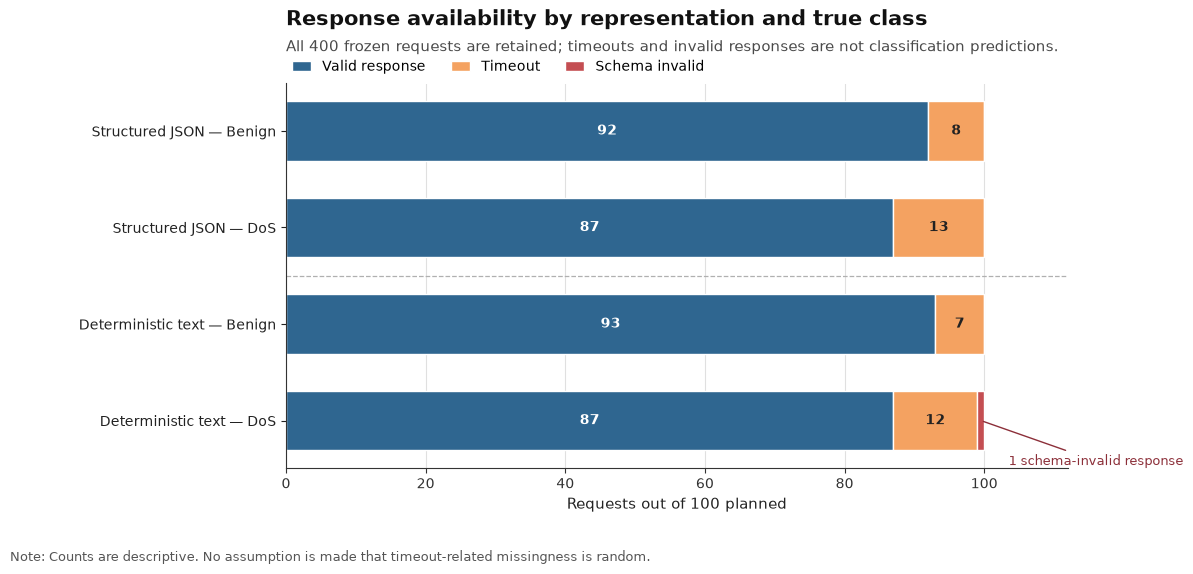

figure_number                                                                       1
figure_purpose                      response availability by representation and tr...
planned_request_count_visualised                                                  400
valid_response_count_visualised                                                   359
timeout_count_visualised                                                           40
schema_invalid_count_visualised                                                     1
png_path                            /Users/ruiwang/Developer/compsci742-rui-pilot/...
png_sha256                          2deabaeeeb081bb90d849c190e5bbcfcd4f341026af55f...
pdf_path                            /Users/ruiwang/Developer/compsci742-rui-pilot/...
pdf_sha256                          ae64cb7a79f854412d37d167e9901c7d4abced279fea7e...
png_dpi                                                                           300
common_axis_used                                      

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt


# Establish a reusable, colour-blind-friendly visual identity for all
# Notebook 09 figures.
CONDITION_DISPLAY_NAMES = {
    "structured": "Structured JSON",
    "deterministic_text": "Deterministic text",
}

CONDITION_COLORS = {
    "structured": "#2F6690",
    "deterministic_text": "#E07A5F",
}

CLASS_COLORS = {
    "Benign": "#4C956C",
    "DoS": "#8B5E83",
}

RESPONSE_OUTCOME_COLORS = {
    "Valid response": "#2F6690",
    "Timeout": "#F4A261",
    "Schema invalid": "#C44E52",
}

PUBLICATION_STYLE = {
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#111111",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": "#333333",
    "ytick.color": "#222222",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
}


# Create the figure directory now that ground truth is permitted and
# the response-coverage population has been validated.
FIGURES_DIR = (
    EVALUATION_RESULTS_DIR / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

COVERAGE_FIGURE_PNG_PATH = (
    FIGURES_DIR
    / "figure_01_response_coverage.png"
)

COVERAGE_FIGURE_PDF_PATH = (
    FIGURES_DIR
    / "figure_01_response_coverage.pdf"
)


# Prepare the mutually exclusive outcome counts in an explicit,
# reproducible plotting order.
coverage_plot_order = [
    ("structured", "Benign"),
    ("structured", "DoS"),
    ("deterministic_text", "Benign"),
    ("deterministic_text", "DoS"),
]

coverage_plot_index = pd.MultiIndex.from_tuples(
    coverage_plot_order,
    names=[
        "condition",
        "true_label",
    ],
)

coverage_plot_table = (
    evaluation_audit_table
    .groupby(
        [
            "condition",
            "true_label",
            "response_outcome",
        ],
        sort=False,
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        index=coverage_plot_index,
        fill_value=0,
    )
    .reindex(
        columns=[
            "Valid response",
            "Timeout",
            "Schema invalid",
        ],
        fill_value=0,
    )
    .astype(int)
)

coverage_plot_table["total"] = (
    coverage_plot_table.sum(axis=1)
)

assert coverage_plot_table[
    "total"
].eq(100).all()

assert (
    coverage_plot_table[
        [
            "Valid response",
            "Timeout",
            "Schema invalid",
        ]
    ].to_dict(orient="index")
    == {
        (
            "structured",
            "Benign",
        ): {
            "Valid response": 92,
            "Timeout": 8,
            "Schema invalid": 0,
        },
        (
            "structured",
            "DoS",
        ): {
            "Valid response": 87,
            "Timeout": 13,
            "Schema invalid": 0,
        },
        (
            "deterministic_text",
            "Benign",
        ): {
            "Valid response": 93,
            "Timeout": 7,
            "Schema invalid": 0,
        },
        (
            "deterministic_text",
            "DoS",
        ): {
            "Valid response": 87,
            "Timeout": 12,
            "Schema invalid": 1,
        },
    }
)


bar_labels = [
    "Structured JSON — Benign",
    "Structured JSON — DoS",
    "Deterministic text — Benign",
    "Deterministic text — DoS",
]

outcome_order = [
    "Valid response",
    "Timeout",
    "Schema invalid",
]

y_positions = np.arange(
    len(coverage_plot_table)
)


with mpl.rc_context(PUBLICATION_STYLE):
    figure, axis = plt.subplots(
        figsize=(11.5, 6.2)
    )

    cumulative_left = np.zeros(
        len(coverage_plot_table),
        dtype=float,
    )

    for response_outcome in outcome_order:
        outcome_values = (
            coverage_plot_table[
                response_outcome
            ]
            .to_numpy(dtype=float)
        )

        bars = axis.barh(
            y=y_positions,
            width=outcome_values,
            left=cumulative_left,
            height=0.62,
            color=RESPONSE_OUTCOME_COLORS[
                response_outcome
            ],
            edgecolor="white",
            linewidth=1.0,
            label=response_outcome,
        )

        # Place labels inside segments that are wide enough to remain
        # legible. The single one-record schema failure is annotated
        # externally below.
        for bar, value in zip(
            bars,
            outcome_values,
        ):
            if value >= 4:
                axis.text(
                    x=(
                        bar.get_x()
                        + bar.get_width() / 2
                    ),
                    y=(
                        bar.get_y()
                        + bar.get_height() / 2
                    ),
                    s=f"{int(value)}",
                    ha="center",
                    va="center",
                    color=(
                        "white"
                        if response_outcome
                        == "Valid response"
                        else "#222222"
                    ),
                    fontsize=10,
                    fontweight="bold",
                )

        cumulative_left += outcome_values


    # The only schema-invalid response is too narrow for an internal
    # label, so identify it without exaggerating its visual width.
    schema_invalid_row_position = 3

    axis.annotate(
        "1 schema-invalid response",
        xy=(
            99.5,
            schema_invalid_row_position,
        ),
        xytext=(
            103.5,
            schema_invalid_row_position + 0.42,
        ),
        ha="left",
        va="center",
        fontsize=9,
        color="#8C2F39",
        arrowprops={
            "arrowstyle": "-",
            "color": "#8C2F39",
            "linewidth": 1.0,
        },
        annotation_clip=False,
    )


    axis.set_yticks(
        y_positions,
        labels=bar_labels,
    )

    axis.invert_yaxis()

    axis.set_xlim(0, 112)

    axis.set_xticks(
        np.arange(0, 101, 20)
    )

    axis.set_xlabel(
        "Requests out of 100 planned"
    )

    axis.set_ylabel("")

    axis.set_title(
        "Response availability by representation and true class",
        loc="left",
        pad=42,
    )

    axis.text(
        0,
        1.075,
        (
            "All 400 frozen requests are retained; "
            "timeouts and invalid responses are not "
            "classification predictions."
        ),
        transform=axis.transAxes,
        ha="left",
        va="bottom",
        fontsize=10.5,
        color="#4A4A4A",
    )

    axis.legend(
        loc="lower left",
        bbox_to_anchor=(
            0,
            1.01,
        ),
        ncol=3,
        borderaxespad=0,
        handlelength=1.4,
        columnspacing=1.8,
    )

    axis.xaxis.grid(
        True,
        color="#D9D9D9",
        linewidth=0.8,
        alpha=0.8,
    )

    axis.set_axisbelow(True)

    # Separate the two representation groups without using additional
    # colour encodings.
    axis.axhline(
        y=1.5,
        color="#B0B0B0",
        linewidth=0.9,
        linestyle="--",
    )

    figure.text(
        0.01,
        0.005,
        (
            "Note: Counts are descriptive. No assumption is made "
            "that timeout-related missingness is random."
        ),
        ha="left",
        va="bottom",
        fontsize=9,
        color="#555555",
    )

    figure.subplots_adjust(
        left=0.25,
        right=0.93,
        top=0.78,
        bottom=0.16,
    )

    figure.savefig(
        COVERAGE_FIGURE_PNG_PATH,
        dpi=300,
        bbox_inches="tight",
    )

    figure.savefig(
        COVERAGE_FIGURE_PDF_PATH,
        bbox_inches="tight",
    )

    plt.show()


assert COVERAGE_FIGURE_PNG_PATH.is_file()
assert COVERAGE_FIGURE_PDF_PATH.is_file()

assert COVERAGE_FIGURE_PNG_PATH.stat().st_size > 0
assert COVERAGE_FIGURE_PDF_PATH.stat().st_size > 0


coverage_figure_summary = pd.Series(
    {
        "figure_number": 1,
        "figure_purpose": (
            "response availability by representation "
            "and true class"
        ),
        "planned_request_count_visualised": int(
            coverage_plot_table["total"].sum()
        ),
        "valid_response_count_visualised": int(
            coverage_plot_table[
                "Valid response"
            ].sum()
        ),
        "timeout_count_visualised": int(
            coverage_plot_table[
                "Timeout"
            ].sum()
        ),
        "schema_invalid_count_visualised": int(
            coverage_plot_table[
                "Schema invalid"
            ].sum()
        ),
        "png_path": str(
            COVERAGE_FIGURE_PNG_PATH
        ),
        "png_sha256": sha256_file(
            COVERAGE_FIGURE_PNG_PATH
        ),
        "pdf_path": str(
            COVERAGE_FIGURE_PDF_PATH
        ),
        "pdf_sha256": sha256_file(
            COVERAGE_FIGURE_PDF_PATH
        ),
        "png_dpi": 300,
        "common_axis_used": True,
        "zero_baseline_used": True,
        "private_ground_truth_loaded": True,
        "classification_metric_calculated": False,
        "evaluation_figure_written": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "response_coverage_visualisation"
        ),
    },
    name="value",
)

coverage_figure_summary

## 5. Condition-specific detection performance

Detection performance is first evaluated separately within each representation's complete set of valid responses: 179 structured-JSON responses and 180 deterministic-text responses.

`DoS` is treated as the positive class. The reported measures are Accuracy, Precision, Recall (Sensitivity), F1, Specificity, and Balanced Accuracy. Timeouts and schema-invalid responses remain outside the classification confusion matrices because they do not constitute predictions.

The side-by-side confusion matrices use the same colour scale and show both cell counts and row percentages. These condition-specific estimates describe performance among available valid responses; the primary representation comparison will subsequently use the common 178-sample paired population.

,condition_display,sample_count,benign_count,dos_count,true_negative,false_positive,false_negative,true_positive,accuracy,precision,recall,f1,specificity,balanced_accuracy
0,Structured JSON,179,92,87,70,22,68,19,0.4972,0.4634,0.2184,0.2969,0.7609,0.4896
1,Deterministic text,180,93,87,57,36,68,19,0.4222,0.3455,0.2184,0.2676,0.6129,0.4156


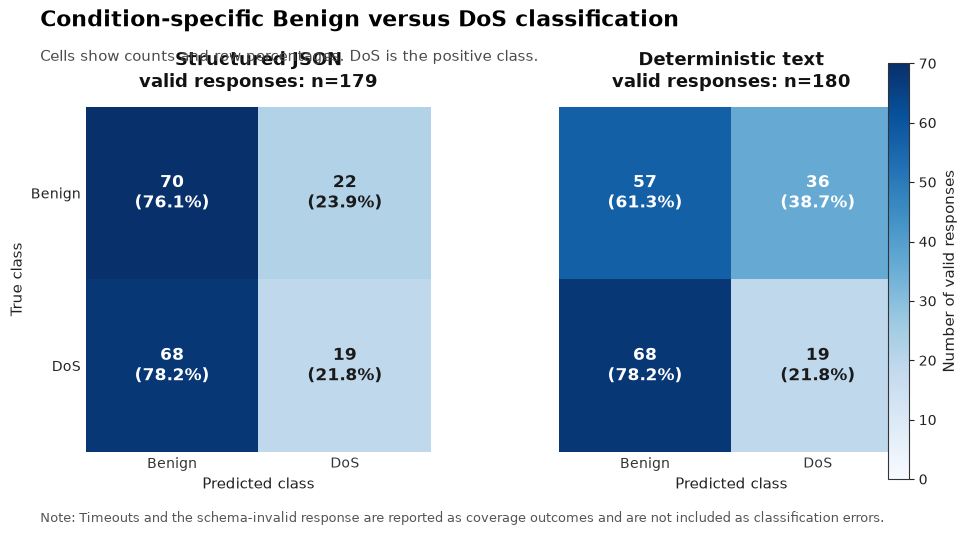

analysis_population                                  condition_specific_valid_responses
positive_class                                                                      DoS
structured_evaluated_count                                                          179
deterministic_text_evaluated_count                                                  180
metric_count                                                                          6
confusion_matrix_count                                                                2
confusion_figure_png_path             /Users/ruiwang/Developer/compsci742-rui-pilot/...
confusion_figure_png_sha256           132006a61acd837fd2522d0a899bb4046272a4aacba736...
confusion_figure_pdf_path             /Users/ruiwang/Developer/compsci742-rui-pilot/...
confusion_figure_pdf_sha256           0064f6c77eee2b71e6b539fda1bc69cbe073d2088a4980...
timeouts_counted_as_errors                                                        False
schema_invalid_counted_as_error 

In [6]:
def safe_divide(
    numerator: int | float,
    denominator: int | float,
) -> float:
    """Return a finite ratio or NaN when the denominator is zero."""
    if denominator == 0:
        return float("nan")

    return float(numerator / denominator)


def calculate_binary_detection_metrics(
    true_binary,
    predicted_binary,
) -> tuple[dict, np.ndarray]:
    """
    Calculate binary detection metrics with DoS encoded as positive.

    The confusion matrix is ordered as:
        [[true negative, false positive],
         [false negative, true positive]]
    """
    true_values = np.asarray(
        true_binary,
        dtype=int,
    )

    predicted_values = np.asarray(
        predicted_binary,
        dtype=int,
    )

    if true_values.shape != predicted_values.shape:
        raise ValueError(
            "True and predicted arrays must have the same shape."
        )

    if true_values.ndim != 1:
        raise ValueError(
            "True and predicted arrays must be one-dimensional."
        )

    if len(true_values) == 0:
        raise ValueError(
            "At least one valid prediction is required."
        )

    if not set(np.unique(true_values)).issubset({0, 1}):
        raise ValueError(
            "True labels must be binary values 0 or 1."
        )

    if not set(np.unique(predicted_values)).issubset(
        {0, 1}
    ):
        raise ValueError(
            "Predicted labels must be binary values 0 or 1."
        )

    true_negative = int(
        (
            (true_values == 0)
            & (predicted_values == 0)
        ).sum()
    )

    false_positive = int(
        (
            (true_values == 0)
            & (predicted_values == 1)
        ).sum()
    )

    false_negative = int(
        (
            (true_values == 1)
            & (predicted_values == 0)
        ).sum()
    )

    true_positive = int(
        (
            (true_values == 1)
            & (predicted_values == 1)
        ).sum()
    )

    sample_count = len(true_values)

    accuracy = safe_divide(
        true_positive + true_negative,
        sample_count,
    )

    precision = safe_divide(
        true_positive,
        true_positive + false_positive,
    )

    recall = safe_divide(
        true_positive,
        true_positive + false_negative,
    )

    specificity = safe_divide(
        true_negative,
        true_negative + false_positive,
    )

    f1 = safe_divide(
        2 * true_positive,
        (
            2 * true_positive
            + false_positive
            + false_negative
        ),
    )

    balanced_accuracy = np.nanmean(
        [
            recall,
            specificity,
        ]
    )

    metrics = {
        "sample_count": sample_count,
        "benign_count": int(
            (true_values == 0).sum()
        ),
        "dos_count": int(
            (true_values == 1).sum()
        ),
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_positive": true_positive,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "balanced_accuracy": float(
            balanced_accuracy
        ),
    }

    confusion_matrix_values = np.array(
        [
            [
                true_negative,
                false_positive,
            ],
            [
                false_negative,
                true_positive,
            ],
        ],
        dtype=int,
    )

    assert confusion_matrix_values.sum() == sample_count

    return metrics, confusion_matrix_values


condition_order = [
    "structured",
    "deterministic_text",
]

condition_specific_metric_rows = []
condition_specific_confusion_matrices = {}


for condition in condition_order:
    condition_evaluation_table = (
        evaluation_audit_table.loc[
            (
                evaluation_audit_table["condition"]
                == condition
            )
            & evaluation_audit_table[
                "analysis_eligible"
            ],
            [
                "sample_id",
                "true_binary",
                "predicted_binary",
            ],
        ]
        .copy()
        .sort_values("sample_id")
        .reset_index(drop=True)
    )

    assert condition_evaluation_table[
        "predicted_binary"
    ].notna().all()

    condition_metrics, condition_confusion_matrix = (
        calculate_binary_detection_metrics(
            true_binary=condition_evaluation_table[
                "true_binary"
            ].to_numpy(dtype=int),
            predicted_binary=condition_evaluation_table[
                "predicted_binary"
            ].to_numpy(dtype=int),
        )
    )

    condition_specific_metric_rows.append(
        {
            "analysis_population": (
                "condition_specific_valid_responses"
            ),
            "condition": condition,
            "condition_display": (
                CONDITION_DISPLAY_NAMES[condition]
            ),
            **condition_metrics,
        }
    )

    condition_specific_confusion_matrices[
        condition
    ] = condition_confusion_matrix


condition_specific_metrics_table = pd.DataFrame(
    condition_specific_metric_rows
)

assert (
    condition_specific_metrics_table
    .set_index("condition")[
        "sample_count"
    ]
    .to_dict()
    == {
        "structured": 179,
        "deterministic_text": 180,
    }
)

assert (
    condition_specific_metrics_table[
        [
            "true_negative",
            "false_positive",
            "false_negative",
            "true_positive",
        ]
    ].sum(axis=1)
    == condition_specific_metrics_table[
        "sample_count"
    ]
).all()


# Create a reader-friendly display table while retaining the full-
# precision metric table for later confidence intervals and export.
condition_specific_metrics_display = (
    condition_specific_metrics_table[
        [
            "condition_display",
            "sample_count",
            "benign_count",
            "dos_count",
            "true_negative",
            "false_positive",
            "false_negative",
            "true_positive",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
        ]
    ]
    .copy()
)

metric_display_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "balanced_accuracy",
]

condition_specific_metrics_display[
    metric_display_columns
] = (
    condition_specific_metrics_display[
        metric_display_columns
    ].round(4)
)

display(condition_specific_metrics_display)


# Produce publication-quality side-by-side confusion matrices.
CONFUSION_FIGURE_PNG_PATH = (
    FIGURES_DIR
    / "figure_02_condition_specific_confusion_matrices.png"
)

CONFUSION_FIGURE_PDF_PATH = (
    FIGURES_DIR
    / "figure_02_condition_specific_confusion_matrices.pdf"
)

maximum_confusion_cell_count = max(
    int(matrix.max())
    for matrix in (
        condition_specific_confusion_matrices.values()
    )
)

with mpl.rc_context(PUBLICATION_STYLE):
    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(10.8, 5.4),
        sharex=True,
        sharey=True,
    )

    image = None

    for axis, condition in zip(
        axes,
        condition_order,
    ):
        confusion_values = (
            condition_specific_confusion_matrices[
                condition
            ]
        )

        image = axis.imshow(
            confusion_values,
            cmap="Blues",
            vmin=0,
            vmax=maximum_confusion_cell_count,
            aspect="equal",
        )

        condition_sample_count = int(
            confusion_values.sum()
        )

        axis.set_title(
            (
                f"{CONDITION_DISPLAY_NAMES[condition]}\n"
                f"valid responses: n={condition_sample_count}"
            ),
            fontsize=13,
            pad=14,
        )

        axis.set_xticks(
            [0, 1],
            labels=[
                "Benign",
                "DoS",
            ],
        )

        axis.set_yticks(
            [0, 1],
            labels=[
                "Benign",
                "DoS",
            ],
        )

        axis.set_xlabel("Predicted class")

        if axis is axes[0]:
            axis.set_ylabel("True class")

        for true_position in range(2):
            row_total = int(
                confusion_values[
                    true_position,
                    :
                ].sum()
            )

            for predicted_position in range(2):
                cell_count = int(
                    confusion_values[
                        true_position,
                        predicted_position,
                    ]
                )

                row_percentage = safe_divide(
                    cell_count,
                    row_total,
                )

                text_colour = (
                    "white"
                    if cell_count
                    > maximum_confusion_cell_count * 0.5
                    else "#1A1A1A"
                )

                axis.text(
                    predicted_position,
                    true_position,
                    (
                        f"{cell_count}\n"
                        f"({row_percentage:.1%})"
                    ),
                    ha="center",
                    va="center",
                    fontsize=12,
                    fontweight="bold",
                    color=text_colour,
                )

        for spine in axis.spines.values():
            spine.set_visible(False)

        axis.tick_params(
            length=0,
        )


    colour_bar = figure.colorbar(
        image,
        ax=axes.ravel().tolist(),
        fraction=0.045,
        pad=0.04,
    )

    colour_bar.set_label(
        "Number of valid responses"
    )

    figure.suptitle(
        "Condition-specific Benign versus DoS classification",
        x=0.08,
        y=0.98,
        ha="left",
        fontsize=16,
        fontweight="bold",
    )

    figure.text(
        0.08,
        0.905,
        (
            "Cells show counts and row percentages. "
            "DoS is the positive class."
        ),
        ha="left",
        va="top",
        fontsize=10.5,
        color="#4A4A4A",
    )

    figure.text(
        0.08,
        0.025,
        (
            "Note: Timeouts and the schema-invalid response are "
            "reported as coverage outcomes and are not included "
            "as classification errors."
        ),
        ha="left",
        va="bottom",
        fontsize=9,
        color="#555555",
    )

    figure.subplots_adjust(
        left=0.10,
        right=0.88,
        top=0.80,
        bottom=0.16,
        wspace=0.28,
    )

    figure.savefig(
        CONFUSION_FIGURE_PNG_PATH,
        dpi=300,
        bbox_inches="tight",
    )

    figure.savefig(
        CONFUSION_FIGURE_PDF_PATH,
        bbox_inches="tight",
    )

    plt.show()


assert CONFUSION_FIGURE_PNG_PATH.is_file()
assert CONFUSION_FIGURE_PDF_PATH.is_file()

assert CONFUSION_FIGURE_PNG_PATH.stat().st_size > 0
assert CONFUSION_FIGURE_PDF_PATH.stat().st_size > 0


condition_specific_evaluation_summary = pd.Series(
    {
        "analysis_population": (
            "condition_specific_valid_responses"
        ),
        "positive_class": "DoS",
        "structured_evaluated_count": int(
            condition_specific_metrics_table.loc[
                condition_specific_metrics_table[
                    "condition"
                ]
                == "structured",
                "sample_count",
            ].iloc[0]
        ),
        "deterministic_text_evaluated_count": int(
            condition_specific_metrics_table.loc[
                condition_specific_metrics_table[
                    "condition"
                ]
                == "deterministic_text",
                "sample_count",
            ].iloc[0]
        ),
        "metric_count": len(
            metric_display_columns
        ),
        "confusion_matrix_count": len(
            condition_specific_confusion_matrices
        ),
        "confusion_figure_png_path": str(
            CONFUSION_FIGURE_PNG_PATH
        ),
        "confusion_figure_png_sha256": sha256_file(
            CONFUSION_FIGURE_PNG_PATH
        ),
        "confusion_figure_pdf_path": str(
            CONFUSION_FIGURE_PDF_PATH
        ),
        "confusion_figure_pdf_sha256": sha256_file(
            CONFUSION_FIGURE_PDF_PATH
        ),
        "timeouts_counted_as_errors": False,
        "schema_invalid_counted_as_error": False,
        "private_ground_truth_loaded": True,
        "classification_metrics_calculated": True,
        "confidence_intervals_calculated": False,
        "paired_comparison_performed": False,
        "evaluation_artifact_written": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "condition_specific_point_estimates"
        ),
    },
    name="value",
)

condition_specific_evaluation_summary

### Figure 2 layout refinement

The initial confusion-matrix rendering contained overlapping header text because the automatic subplot layout did not reserve sufficient space for the figure title, explanatory subtitle, and panel titles.

The numerical results were valid and are not recalculated here. This cell regenerates only Figure 2 using an explicit grid layout with separate title, plotting, colour-bar, and footnote regions. The earlier derived PNG and PDF files are intentionally replaced; no inference record, label, eligibility decision, or metric value is modified.

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


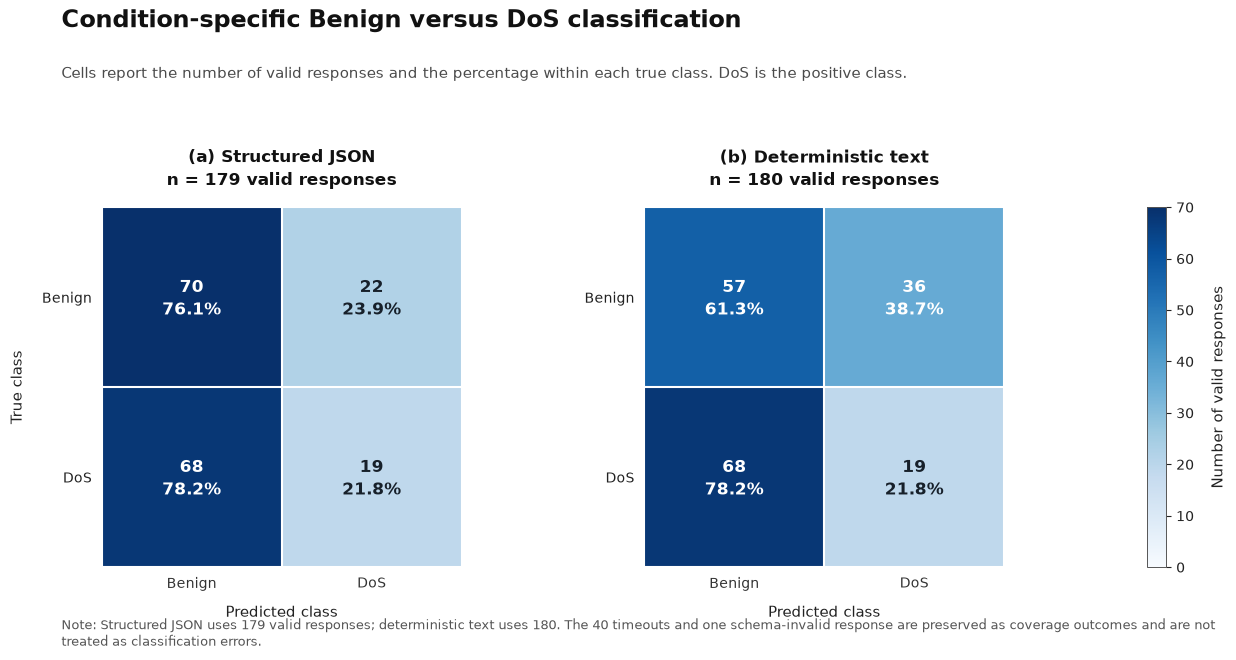

figure_number                                                                              2
figure_layout_status                                              refined_with_explicit_grid
structured_sample_count                                                                  179
deterministic_text_sample_count                                                          180
common_colour_scale_used                                                                True
cell_counts_displayed                                                                   True
within_true_class_percentages_displayed                                                 True
title_region_separated                                                                  True
panel_titles_separated                                                                  True
footnote_region_separated                                                               True
png_path                                   /Users/ruiwang/Developer/co

In [7]:
# Regenerate only the derived confusion-matrix figure with an explicit
# publication layout. No metric or experimental record is changed.
maximum_confusion_cell_count = max(
    int(matrix.max())
    for matrix in (
        condition_specific_confusion_matrices.values()
    )
)

with mpl.rc_context(PUBLICATION_STYLE):
    figure = plt.figure(
        figsize=(13.0, 7.2),
        facecolor="white",
    )

    # Reserve distinct areas for the two matrices and colour bar.
    grid = figure.add_gridspec(
        nrows=1,
        ncols=3,
        width_ratios=[
            1.0,
            1.0,
            0.045,
        ],
        left=0.08,
        right=0.93,
        bottom=0.18,
        top=0.68,
        wspace=0.34,
    )

    structured_axis = figure.add_subplot(
        grid[0, 0]
    )

    text_axis = figure.add_subplot(
        grid[0, 1],
        sharex=structured_axis,
        sharey=structured_axis,
    )

    colour_bar_axis = figure.add_subplot(
        grid[0, 2]
    )

    matrix_axes = [
        structured_axis,
        text_axis,
    ]

    image = None

    for panel_index, (
        axis,
        condition,
    ) in enumerate(
        zip(
            matrix_axes,
            condition_order,
        ),
        start=1,
    ):
        confusion_values = (
            condition_specific_confusion_matrices[
                condition
            ]
        )

        image = axis.imshow(
            confusion_values,
            cmap="Blues",
            vmin=0,
            vmax=maximum_confusion_cell_count,
            aspect="equal",
            interpolation="nearest",
        )

        condition_sample_count = int(
            confusion_values.sum()
        )

        panel_letter = chr(
            ord("a") + panel_index - 1
        )

        axis.set_title(
            (
                f"({panel_letter}) "
                f"{CONDITION_DISPLAY_NAMES[condition]}\n"
                f"n = {condition_sample_count} valid responses"
            ),
            fontsize=12.5,
            fontweight="semibold",
            pad=16,
            linespacing=1.35,
        )

        axis.set_xticks(
            [0, 1],
            labels=[
                "Benign",
                "DoS",
            ],
        )

        axis.set_yticks(
            [0, 1],
            labels=[
                "Benign",
                "DoS",
            ],
        )

        axis.set_xlabel(
            "Predicted class",
            labelpad=10,
        )

        if axis is structured_axis:
            axis.set_ylabel(
                "True class",
                labelpad=12,
            )
        else:
            axis.set_ylabel("")

        for true_position in range(2):
            row_total = int(
                confusion_values[
                    true_position,
                    :
                ].sum()
            )

            for predicted_position in range(2):
                cell_count = int(
                    confusion_values[
                        true_position,
                        predicted_position,
                    ]
                )

                row_percentage = safe_divide(
                    cell_count,
                    row_total,
                )

                # Select annotation colour according to the underlying
                # cell intensity to preserve readable contrast.
                normalised_intensity = safe_divide(
                    cell_count,
                    maximum_confusion_cell_count,
                )

                annotation_colour = (
                    "white"
                    if normalised_intensity >= 0.48
                    else "#17202A"
                )

                axis.text(
                    predicted_position,
                    true_position,
                    (
                        f"{cell_count}\n"
                        f"{row_percentage:.1%}"
                    ),
                    ha="center",
                    va="center",
                    fontsize=12,
                    fontweight="semibold",
                    color=annotation_colour,
                    linespacing=1.35,
                )

        # Draw subtle cell boundaries without adding visual clutter.
        axis.set_xticks(
            np.arange(-0.5, 2, 1),
            minor=True,
        )

        axis.set_yticks(
            np.arange(-0.5, 2, 1),
            minor=True,
        )

        axis.grid(
            which="minor",
            color="white",
            linewidth=1.5,
        )

        axis.tick_params(
            which="minor",
            bottom=False,
            left=False,
        )

        axis.tick_params(
            which="major",
            length=0,
            pad=7,
        )

        for spine in axis.spines.values():
            spine.set_visible(False)


    colour_bar = figure.colorbar(
        image,
        cax=colour_bar_axis,
    )

    colour_bar.set_label(
        "Number of valid responses",
        labelpad=12,
    )

    colour_bar.outline.set_linewidth(0.7)
    colour_bar.outline.set_edgecolor("#555555")


    # The title region is separate from the plotting grid, preventing
    # collision with either panel title.
    figure.text(
        0.08,
        0.955,
        (
            "Condition-specific Benign versus DoS "
            "classification"
        ),
        ha="left",
        va="top",
        fontsize=17,
        fontweight="bold",
        color="#111111",
    )

    figure.text(
        0.08,
        0.875,
        (
            "Cells report the number of valid responses "
            "and the percentage within each true class. "
            "DoS is the positive class."
        ),
        ha="left",
        va="top",
        fontsize=10.5,
        color="#4A4A4A",
    )

    figure.text(
        0.08,
        0.065,
        (
            "Note: Structured JSON uses 179 valid responses; "
            "deterministic text uses 180. The 40 timeouts and "
            "one schema-invalid response are preserved as coverage "
            "outcomes and are not treated as classification errors."
        ),
        ha="left",
        va="bottom",
        fontsize=9,
        color="#555555",
        wrap=True,
    )


    # These paths intentionally replace only the earlier derived
    # Figure 2 renderings.
    figure.savefig(
        CONFUSION_FIGURE_PNG_PATH,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    figure.savefig(
        CONFUSION_FIGURE_PDF_PATH,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()


assert CONFUSION_FIGURE_PNG_PATH.is_file()
assert CONFUSION_FIGURE_PDF_PATH.is_file()

assert CONFUSION_FIGURE_PNG_PATH.stat().st_size > 0
assert CONFUSION_FIGURE_PDF_PATH.stat().st_size > 0


refined_confusion_figure_summary = pd.Series(
    {
        "figure_number": 2,
        "figure_layout_status": (
            "refined_with_explicit_grid"
        ),
        "structured_sample_count": int(
            condition_specific_confusion_matrices[
                "structured"
            ].sum()
        ),
        "deterministic_text_sample_count": int(
            condition_specific_confusion_matrices[
                "deterministic_text"
            ].sum()
        ),
        "common_colour_scale_used": True,
        "cell_counts_displayed": True,
        "within_true_class_percentages_displayed": True,
        "title_region_separated": True,
        "panel_titles_separated": True,
        "footnote_region_separated": True,
        "png_path": str(
            CONFUSION_FIGURE_PNG_PATH
        ),
        "png_sha256": sha256_file(
            CONFUSION_FIGURE_PNG_PATH
        ),
        "pdf_path": str(
            CONFUSION_FIGURE_PDF_PATH
        ),
        "pdf_sha256": sha256_file(
            CONFUSION_FIGURE_PDF_PATH
        ),
        "png_dpi": 300,
        "metric_values_recalculated": False,
        "experimental_record_modified": False,
        "derived_figure_intentionally_replaced": True,
        "private_ground_truth_loaded": True,
        "network_request_made": False,
    },
    name="value",
)

refined_confusion_figure_summary

## 6. Stratified-bootstrap confidence intervals

Point estimates alone do not show the uncertainty associated with the finite evaluation samples. This section calculates 95% percentile confidence intervals for all six condition-specific detection metrics using 10,000 nonparametric bootstrap replicates with fixed seed 742.

Bootstrap resampling is stratified by the true class within each representation. Every replicate therefore preserves the observed number of valid Benign and DoS responses for that condition. This avoids adding arbitrary class-composition variation to an experiment whose original sample was balanced by design but whose valid-response populations differ slightly because of timeouts.

These intervals describe uncertainty within each condition-specific valid-response population. They do not yet test the paired structured-versus-text difference; that comparison is performed separately on the 178 complete pairs.

,condition_display,metric_display,sample_count,estimate_and_95_ci
0,Structured JSON,Accuracy,179,"0.4972 [0.4358, 0.5587]"
1,Structured JSON,Precision,179,"0.4634 [0.3256, 0.6000]"
2,Structured JSON,Recall (sensitivity),179,"0.2184 [0.1379, 0.3103]"
3,Structured JSON,F1,179,"0.2969 [0.1951, 0.3971]"
4,Structured JSON,Specificity,179,"0.7609 [0.6739, 0.8478]"
5,Structured JSON,Balanced accuracy,179,"0.4896 [0.4280, 0.5513]"
6,Deterministic text,Accuracy,180,"0.4222 [0.3556, 0.4889]"
7,Deterministic text,Precision,180,"0.3455 [0.2364, 0.4510]"
8,Deterministic text,Recall (sensitivity),180,"0.2184 [0.1379, 0.3103]"
9,Deterministic text,F1,180,"0.2676 [0.1752, 0.3609]"


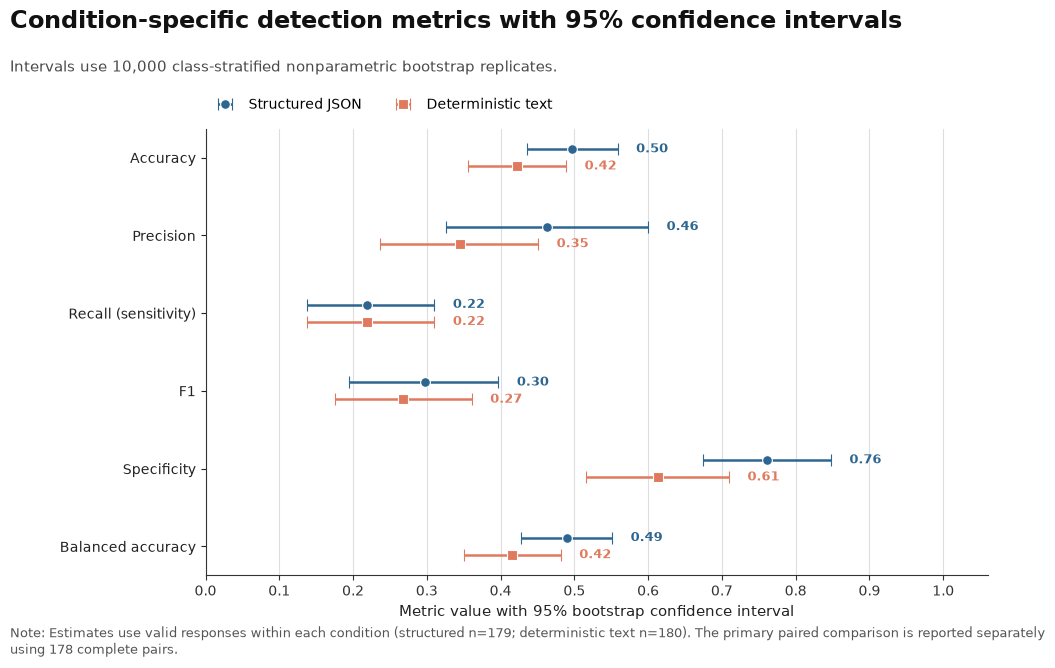

analysis_population                               condition_specific_valid_responses
metric_count_per_condition                                                         6
condition_count                                                                    2
bootstrap_method                               class-stratified percentile bootstrap
bootstrap_seed                                                                   742
bootstrap_replicate_count                                                      10000
confidence_level                                                                0.95
structured_sample_count                                                          179
deterministic_text_sample_count                                                  180
figure_png_path                    /Users/ruiwang/Developer/compsci742-rui-pilot/...
figure_png_sha256                  7f2689c7e056b7faaea030b411c4591d09c74c5c7ac78a...
figure_pdf_path                    /Users/ruiwang/Developer/comps

In [8]:
BOOTSTRAP_SEED = 742
BOOTSTRAP_REPLICATE_COUNT = 10_000
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

METRIC_ORDER = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "balanced_accuracy",
]

METRIC_DISPLAY_NAMES = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall (sensitivity)",
    "f1": "F1",
    "specificity": "Specificity",
    "balanced_accuracy": "Balanced accuracy",
}


# Spawn a deterministic independent random stream for each condition.
bootstrap_seed_sequence = np.random.SeedSequence(
    BOOTSTRAP_SEED
)

condition_seed_sequences = dict(
    zip(
        condition_order,
        bootstrap_seed_sequence.spawn(
            len(condition_order)
        ),
    )
)

condition_metric_lookup = (
    condition_specific_metrics_table
    .set_index("condition")
    .to_dict(orient="index")
)

condition_specific_bootstrap_distributions = {}
condition_specific_metric_ci_rows = []


for condition in condition_order:
    condition_data = (
        evaluation_audit_table.loc[
            (
                evaluation_audit_table["condition"]
                == condition
            )
            & evaluation_audit_table[
                "analysis_eligible"
            ],
            [
                "sample_id",
                "true_binary",
                "predicted_binary",
            ],
        ]
        .sort_values("sample_id")
        .reset_index(drop=True)
    )

    true_values = condition_data[
        "true_binary"
    ].to_numpy(dtype=int)

    predicted_values = condition_data[
        "predicted_binary"
    ].to_numpy(dtype=int)

    benign_positions = np.flatnonzero(
        true_values == 0
    )

    dos_positions = np.flatnonzero(
        true_values == 1
    )

    assert len(benign_positions) == int(
        condition_metric_lookup[condition][
            "benign_count"
        ]
    )

    assert len(dos_positions) == int(
        condition_metric_lookup[condition][
            "dos_count"
        ]
    )

    condition_rng = np.random.default_rng(
        condition_seed_sequences[condition]
    )

    bootstrap_metric_values = {
        metric_name: np.empty(
            BOOTSTRAP_REPLICATE_COUNT,
            dtype=float,
        )
        for metric_name in METRIC_ORDER
    }

    for bootstrap_index in range(
        BOOTSTRAP_REPLICATE_COUNT
    ):
        sampled_benign_positions = (
            condition_rng.choice(
                benign_positions,
                size=len(benign_positions),
                replace=True,
            )
        )

        sampled_dos_positions = (
            condition_rng.choice(
                dos_positions,
                size=len(dos_positions),
                replace=True,
            )
        )

        sampled_positions = np.concatenate(
            [
                sampled_benign_positions,
                sampled_dos_positions,
            ]
        )

        bootstrap_metrics, _ = (
            calculate_binary_detection_metrics(
                true_binary=true_values[
                    sampled_positions
                ],
                predicted_binary=predicted_values[
                    sampled_positions
                ],
            )
        )

        for metric_name in METRIC_ORDER:
            bootstrap_metric_values[
                metric_name
            ][bootstrap_index] = (
                bootstrap_metrics[metric_name]
            )

    condition_specific_bootstrap_distributions[
        condition
    ] = bootstrap_metric_values

    lower_percentile = (
        100
        * (1 - BOOTSTRAP_CONFIDENCE_LEVEL)
        / 2
    )

    upper_percentile = (
        100 - lower_percentile
    )

    for metric_name in METRIC_ORDER:
        metric_distribution = (
            bootstrap_metric_values[
                metric_name
            ]
        )

        finite_distribution = (
            metric_distribution[
                np.isfinite(metric_distribution)
            ]
        )

        if len(finite_distribution) == 0:
            raise ValueError(
                "No finite bootstrap estimates were produced "
                f"for {condition}, {metric_name}."
            )

        point_estimate = float(
            condition_metric_lookup[condition][
                metric_name
            ]
        )

        confidence_interval_lower = float(
            np.percentile(
                finite_distribution,
                lower_percentile,
            )
        )

        confidence_interval_upper = float(
            np.percentile(
                finite_distribution,
                upper_percentile,
            )
        )

        condition_specific_metric_ci_rows.append(
            {
                "analysis_population": (
                    "condition_specific_valid_responses"
                ),
                "condition": condition,
                "condition_display": (
                    CONDITION_DISPLAY_NAMES[
                        condition
                    ]
                ),
                "metric": metric_name,
                "metric_display": (
                    METRIC_DISPLAY_NAMES[
                        metric_name
                    ]
                ),
                "estimate": point_estimate,
                "ci_level": (
                    BOOTSTRAP_CONFIDENCE_LEVEL
                ),
                "ci_lower": (
                    confidence_interval_lower
                ),
                "ci_upper": (
                    confidence_interval_upper
                ),
                "bootstrap_method": (
                    "class-stratified percentile bootstrap"
                ),
                "bootstrap_replicates_requested": (
                    BOOTSTRAP_REPLICATE_COUNT
                ),
                "bootstrap_replicates_finite": len(
                    finite_distribution
                ),
                "bootstrap_seed": BOOTSTRAP_SEED,
                "sample_count": len(
                    condition_data
                ),
                "benign_count": len(
                    benign_positions
                ),
                "dos_count": len(
                    dos_positions
                ),
            }
        )


condition_specific_metric_ci_table = pd.DataFrame(
    condition_specific_metric_ci_rows
)

assert len(
    condition_specific_metric_ci_table
) == (
    len(condition_order)
    * len(METRIC_ORDER)
)

assert condition_specific_metric_ci_table[
    "bootstrap_replicates_finite"
].gt(0).all()

assert condition_specific_metric_ci_table[
    "ci_lower"
].between(0, 1).all()

assert condition_specific_metric_ci_table[
    "ci_upper"
].between(0, 1).all()

assert (
    condition_specific_metric_ci_table[
        "ci_lower"
    ]
    <= condition_specific_metric_ci_table[
        "ci_upper"
    ]
).all()


# Create a compact reader-facing table with one row per condition and
# metric while preserving the full-precision source table.
condition_specific_metric_ci_display = (
    condition_specific_metric_ci_table[
        [
            "condition_display",
            "metric_display",
            "sample_count",
            "estimate",
            "ci_lower",
            "ci_upper",
        ]
    ]
    .copy()
)

condition_specific_metric_ci_display[
    [
        "estimate",
        "ci_lower",
        "ci_upper",
    ]
] = (
    condition_specific_metric_ci_display[
        [
            "estimate",
            "ci_lower",
            "ci_upper",
        ]
    ].round(4)
)

condition_specific_metric_ci_display[
    "estimate_and_95_ci"
] = (
    condition_specific_metric_ci_display[
        "estimate"
    ].map(lambda value: f"{value:.4f}")
    + " ["
    + condition_specific_metric_ci_display[
        "ci_lower"
    ].map(lambda value: f"{value:.4f}")
    + ", "
    + condition_specific_metric_ci_display[
        "ci_upper"
    ].map(lambda value: f"{value:.4f}")
    + "]"
)

display(
    condition_specific_metric_ci_display[
        [
            "condition_display",
            "metric_display",
            "sample_count",
            "estimate_and_95_ci",
        ]
    ]
)


# Create Figure 3: condition-specific metric estimates and 95% CIs.
METRIC_CI_FIGURE_PNG_PATH = (
    FIGURES_DIR
    / "figure_03_condition_specific_metrics_with_ci.png"
)

METRIC_CI_FIGURE_PDF_PATH = (
    FIGURES_DIR
    / "figure_03_condition_specific_metrics_with_ci.pdf"
)

metric_y_positions = np.arange(
    len(METRIC_ORDER)
)

condition_y_offsets = {
    "structured": -0.11,
    "deterministic_text": 0.11,
}

condition_markers = {
    "structured": "o",
    "deterministic_text": "s",
}


with mpl.rc_context(PUBLICATION_STYLE):
    figure = plt.figure(
        figsize=(11.5, 7.2),
        facecolor="white",
    )

    axis = figure.add_axes(
        [
            0.25,
            0.17,
            0.68,
            0.62,
        ]
    )

    for condition in condition_order:
        condition_rows = (
            condition_specific_metric_ci_table.loc[
                condition_specific_metric_ci_table[
                    "condition"
                ]
                == condition
            ]
            .set_index("metric")
            .loc[METRIC_ORDER]
        )

        estimates = condition_rows[
            "estimate"
        ].to_numpy(dtype=float)

        lower_bounds = condition_rows[
            "ci_lower"
        ].to_numpy(dtype=float)

        upper_bounds = condition_rows[
            "ci_upper"
        ].to_numpy(dtype=float)

        y_values = (
            metric_y_positions
            + condition_y_offsets[condition]
        )

        asymmetric_errors = np.vstack(
            [
                estimates - lower_bounds,
                upper_bounds - estimates,
            ]
        )

        axis.errorbar(
            x=estimates,
            y=y_values,
            xerr=asymmetric_errors,
            fmt=condition_markers[condition],
            markersize=7,
            markerfacecolor=(
                CONDITION_COLORS[condition]
            ),
            markeredgecolor="white",
            markeredgewidth=0.8,
            color=CONDITION_COLORS[condition],
            ecolor=CONDITION_COLORS[condition],
            elinewidth=1.8,
            capsize=4,
            capthick=1.4,
            label=(
                CONDITION_DISPLAY_NAMES[
                    condition
                ]
            ),
            zorder=3,
        )

        for estimate, upper_bound, y_value in zip(
            estimates,
            upper_bounds,
            y_values,
        ):
            label_x_position = min(
                upper_bound + 0.025,
                1.01,
            )

            axis.text(
                label_x_position,
                y_value,
                f"{estimate:.2f}",
                ha="left",
                va="center",
                fontsize=9,
                color=(
                    CONDITION_COLORS[condition]
                ),
                fontweight="bold",
            )


    axis.set_yticks(
        metric_y_positions,
        labels=[
            METRIC_DISPLAY_NAMES[
                metric_name
            ]
            for metric_name in METRIC_ORDER
        ],
    )

    axis.invert_yaxis()

    axis.set_xlim(0, 1.06)

    axis.set_xticks(
        np.arange(0, 1.01, 0.1)
    )

    axis.set_xlabel(
        "Metric value with 95% bootstrap confidence interval"
    )

    axis.set_ylabel("")

    axis.xaxis.grid(
        True,
        color="#D9D9D9",
        linewidth=0.8,
        alpha=0.85,
    )

    axis.set_axisbelow(True)

    axis.legend(
        loc="lower left",
        bbox_to_anchor=(
            0,
            1.025,
        ),
        ncol=2,
        borderaxespad=0,
        handletextpad=0.7,
        columnspacing=2.0,
    )

    figure.text(
        0.08,
        0.955,
        (
            "Condition-specific detection metrics "
            "with 95% confidence intervals"
        ),
        ha="left",
        va="top",
        fontsize=17,
        fontweight="bold",
        color="#111111",
    )

    figure.text(
        0.08,
        0.885,
        (
            "Intervals use 10,000 class-stratified "
            "nonparametric bootstrap replicates."
        ),
        ha="left",
        va="top",
        fontsize=10.5,
        color="#4A4A4A",
    )

    figure.text(
        0.08,
        0.055,
        (
            "Note: Estimates use valid responses within each "
            "condition (structured n=179; deterministic text "
            "n=180). The primary paired comparison is reported "
            "separately using 178 complete pairs."
        ),
        ha="left",
        va="bottom",
        fontsize=9,
        color="#555555",
        wrap=True,
    )

    figure.savefig(
        METRIC_CI_FIGURE_PNG_PATH,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    figure.savefig(
        METRIC_CI_FIGURE_PDF_PATH,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()


assert METRIC_CI_FIGURE_PNG_PATH.is_file()
assert METRIC_CI_FIGURE_PDF_PATH.is_file()

assert METRIC_CI_FIGURE_PNG_PATH.stat().st_size > 0
assert METRIC_CI_FIGURE_PDF_PATH.stat().st_size > 0


condition_specific_ci_summary = pd.Series(
    {
        "analysis_population": (
            "condition_specific_valid_responses"
        ),
        "metric_count_per_condition": len(
            METRIC_ORDER
        ),
        "condition_count": len(
            condition_order
        ),
        "bootstrap_method": (
            "class-stratified percentile bootstrap"
        ),
        "bootstrap_seed": BOOTSTRAP_SEED,
        "bootstrap_replicate_count": (
            BOOTSTRAP_REPLICATE_COUNT
        ),
        "confidence_level": (
            BOOTSTRAP_CONFIDENCE_LEVEL
        ),
        "structured_sample_count": 179,
        "deterministic_text_sample_count": 180,
        "figure_png_path": str(
            METRIC_CI_FIGURE_PNG_PATH
        ),
        "figure_png_sha256": sha256_file(
            METRIC_CI_FIGURE_PNG_PATH
        ),
        "figure_pdf_path": str(
            METRIC_CI_FIGURE_PDF_PATH
        ),
        "figure_pdf_sha256": sha256_file(
            METRIC_CI_FIGURE_PDF_PATH
        ),
        "confidence_intervals_calculated": True,
        "paired_comparison_performed": False,
        "private_ground_truth_loaded": True,
        "evaluation_artifact_written": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "condition_specific_confidence_intervals"
        ),
    },
    name="value",
)

condition_specific_ci_summary

## 7. Complete-pair construction and McNemar comparison

The primary representation comparison uses only the 178 samples for which both structured JSON and deterministic text produced independently validated responses.

For each sample, the two predictions are aligned with one shared true label. This preserves the controlled paired design and removes differences caused solely by evaluating the two representations on slightly different valid-response populations.

McNemar's exact test compares the two discordant outcomes:

- samples classified correctly only under structured JSON; and
- samples classified correctly only under deterministic text.

The null hypothesis is that these two discordant outcomes are equally likely. The test therefore assesses paired accuracy differences without treating the two sets of predictions as independent.

,condition_display,sample_count,true_negative,false_positive,false_negative,true_positive,accuracy,precision,recall,f1,specificity,balanced_accuracy
0,Structured JSON,178,70,22,67,19,0.5000,0.4634,0.2209,0.2992,0.7609,0.4909
1,Deterministic text,178,56,36,67,19,0.4213,0.3455,0.2209,0.2695,0.6087,0.4148


,complete_pair_count,both_correct,structured_only_correct,text_only_correct,both_incorrect,discordant_pair_count,structured_minus_text_accuracy,exact_two_sided_p_value,reject_equal_accuracy_at_0_05
0,178,61,28,14,75,42,0.0787,0.043559,True


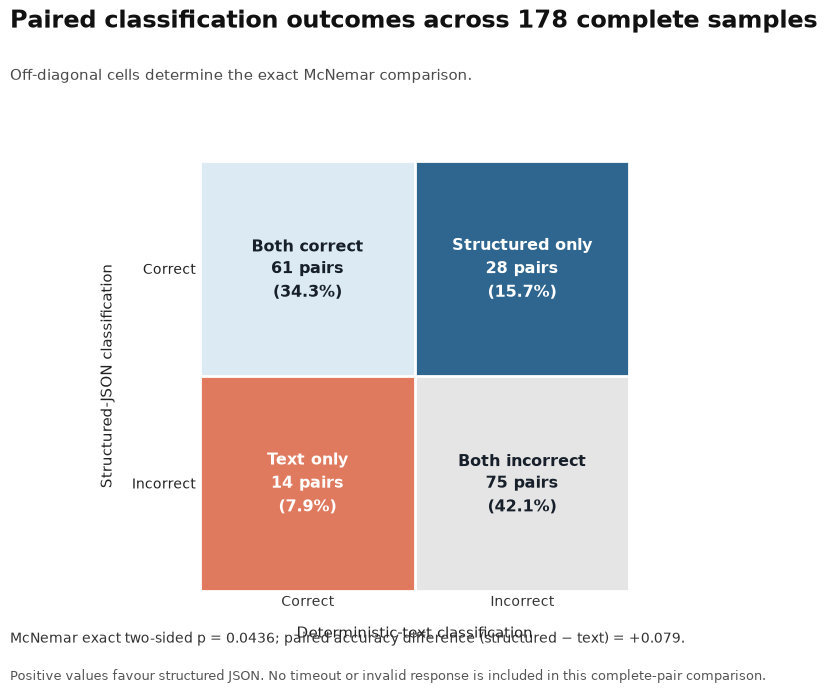

complete_pair_sample_count                                                       178
complete_pair_benign_count                                                        92
complete_pair_dos_count                                                           86
both_correct_count                                                                61
structured_only_correct_count                                                     28
text_only_correct_count                                                           14
both_incorrect_count                                                              75
discordant_pair_count                                                             42
paired_accuracy_difference                                                  0.078652
mcnemar_exact_two_sided_p_value                                             0.043559
reject_equal_accuracy_at_0_05                                                   True
figure_png_path                    /Users/ruiwang/Developer/comps

In [9]:
# Extract the 356 condition-level rows belonging to the 178 complete
# pairs. Every retained row must itself be analysis eligible.
paired_condition_records = (
    evaluation_audit_table.loc[
        evaluation_audit_table[
            "paired_analysis_eligible"
        ],
        [
            "sample_id",
            "condition",
            "true_label",
            "true_binary",
            "predicted_label",
            "predicted_binary",
            "prediction_correct",
        ],
    ]
    .copy()
    .sort_values(
        [
            "sample_id",
            "condition",
        ]
    )
    .reset_index(drop=True)
)

assert len(paired_condition_records) == 356

assert paired_condition_records[
    "sample_id"
].nunique() == 178

assert paired_condition_records[
    "predicted_binary"
].notna().all()

assert paired_condition_records[
    "prediction_correct"
].notna().all()

assert paired_condition_records.groupby(
    "sample_id"
)["condition"].nunique().eq(2).all()

assert paired_condition_records.groupby(
    "sample_id"
)["true_label"].nunique().eq(1).all()


# Align both predictions on one row per sample.
paired_prediction_wide = (
    paired_condition_records
    .pivot(
        index="sample_id",
        columns="condition",
        values="predicted_binary",
    )
    .rename(
        columns={
            "structured": (
                "structured_predicted_binary"
            ),
            "deterministic_text": (
                "deterministic_text_predicted_binary"
            ),
        }
    )
    .reset_index()
)

paired_correctness_wide = (
    paired_condition_records
    .pivot(
        index="sample_id",
        columns="condition",
        values="prediction_correct",
    )
    .rename(
        columns={
            "structured": "structured_correct",
            "deterministic_text": (
                "deterministic_text_correct"
            ),
        }
    )
    .reset_index()
)

paired_evaluation_table = (
    complete_pair_sample_table
    .merge(
        paired_prediction_wide,
        on="sample_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        paired_correctness_wide,
        on="sample_id",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("sample_id")
    .reset_index(drop=True)
)

assert len(paired_evaluation_table) == 178
assert paired_evaluation_table["sample_id"].is_unique

assert (
    paired_evaluation_table[
        "true_label"
    ].value_counts().to_dict()
    == {
        "Benign": 92,
        "DoS": 86,
    }
)

for column_name in [
    "structured_predicted_binary",
    "deterministic_text_predicted_binary",
]:
    paired_evaluation_table[column_name] = (
        paired_evaluation_table[
            column_name
        ].astype(int)
    )

for column_name in [
    "structured_correct",
    "deterministic_text_correct",
]:
    paired_evaluation_table[column_name] = (
        paired_evaluation_table[
            column_name
        ].astype(bool)
    )


# Calculate point estimates for both conditions on exactly the same
# 178 samples.
paired_metric_rows = []
paired_confusion_matrices = {}

for condition in condition_order:
    prediction_column = (
        f"{condition}_predicted_binary"
    )

    paired_metrics, paired_confusion_matrix = (
        calculate_binary_detection_metrics(
            true_binary=paired_evaluation_table[
                "true_binary"
            ].to_numpy(dtype=int),
            predicted_binary=paired_evaluation_table[
                prediction_column
            ].to_numpy(dtype=int),
        )
    )

    paired_metric_rows.append(
        {
            "analysis_population": (
                "complete_paired_responses"
            ),
            "condition": condition,
            "condition_display": (
                CONDITION_DISPLAY_NAMES[condition]
            ),
            **paired_metrics,
        }
    )

    paired_confusion_matrices[
        condition
    ] = paired_confusion_matrix


paired_metrics_table = pd.DataFrame(
    paired_metric_rows
)

assert paired_metrics_table[
    "sample_count"
].eq(178).all()

assert paired_metrics_table[
    "benign_count"
].eq(92).all()

assert paired_metrics_table[
    "dos_count"
].eq(86).all()


paired_metrics_display = (
    paired_metrics_table[
        [
            "condition_display",
            "sample_count",
            "true_negative",
            "false_positive",
            "false_negative",
            "true_positive",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
        ]
    ]
    .copy()
)

paired_metrics_display[
    METRIC_ORDER
] = (
    paired_metrics_display[
        METRIC_ORDER
    ].round(4)
)

display(paired_metrics_display)


# Construct the paired correctness table used by McNemar's test.
both_correct_count = int(
    (
        paired_evaluation_table[
            "structured_correct"
        ]
        & paired_evaluation_table[
            "deterministic_text_correct"
        ]
    ).sum()
)

structured_only_correct_count = int(
    (
        paired_evaluation_table[
            "structured_correct"
        ]
        & ~paired_evaluation_table[
            "deterministic_text_correct"
        ]
    ).sum()
)

text_only_correct_count = int(
    (
        ~paired_evaluation_table[
            "structured_correct"
        ]
        & paired_evaluation_table[
            "deterministic_text_correct"
        ]
    ).sum()
)

both_incorrect_count = int(
    (
        ~paired_evaluation_table[
            "structured_correct"
        ]
        & ~paired_evaluation_table[
            "deterministic_text_correct"
        ]
    ).sum()
)

paired_correctness_matrix = np.array(
    [
        [
            both_correct_count,
            structured_only_correct_count,
        ],
        [
            text_only_correct_count,
            both_incorrect_count,
        ],
    ],
    dtype=int,
)

assert paired_correctness_matrix.sum() == 178


def exact_mcnemar_two_sided_pvalue(
    structured_only_correct: int,
    text_only_correct: int,
) -> float:
    """
    Calculate the exact two-sided McNemar p-value.

    Under the null hypothesis, either condition is equally likely to
    be the only correct condition within a discordant pair.
    """
    discordant_count = (
        structured_only_correct
        + text_only_correct
    )

    if discordant_count == 0:
        return 1.0

    smaller_discordant_count = min(
        structured_only_correct,
        text_only_correct,
    )

    lower_tail_probability = sum(
        math.comb(
            discordant_count,
            outcome_count,
        )
        for outcome_count in range(
            smaller_discordant_count + 1
        )
    ) / (2 ** discordant_count)

    return float(
        min(
            1.0,
            2 * lower_tail_probability,
        )
    )


mcnemar_discordant_count = (
    structured_only_correct_count
    + text_only_correct_count
)

mcnemar_exact_p_value = (
    exact_mcnemar_two_sided_pvalue(
        structured_only_correct=(
            structured_only_correct_count
        ),
        text_only_correct=(
            text_only_correct_count
        ),
    )
)

paired_accuracy_difference = (
    (
        structured_only_correct_count
        - text_only_correct_count
    )
    / len(paired_evaluation_table)
)

mcnemar_reject_at_0_05 = bool(
    mcnemar_exact_p_value < 0.05
)

mcnemar_summary_table = pd.DataFrame(
    [
        {
            "complete_pair_count": len(
                paired_evaluation_table
            ),
            "both_correct": both_correct_count,
            "structured_only_correct": (
                structured_only_correct_count
            ),
            "text_only_correct": (
                text_only_correct_count
            ),
            "both_incorrect": both_incorrect_count,
            "discordant_pair_count": (
                mcnemar_discordant_count
            ),
            "structured_minus_text_accuracy": (
                paired_accuracy_difference
            ),
            "exact_two_sided_p_value": (
                mcnemar_exact_p_value
            ),
            "reject_equal_accuracy_at_0_05": (
                mcnemar_reject_at_0_05
            ),
        }
    ]
)

display(
    mcnemar_summary_table.round(
        {
            "structured_minus_text_accuracy": 4,
            "exact_two_sided_p_value": 6,
        }
    )
)


# Create Figure 4 as a categorical paired-outcome matrix. The
# off-diagonal cells use the fixed condition colours so the direction
# of discordance is immediately visible.
from matplotlib.colors import ListedColormap


MCNEMAR_FIGURE_PNG_PATH = (
    FIGURES_DIR
    / "figure_04_paired_correctness_mcnemar.png"
)

MCNEMAR_FIGURE_PDF_PATH = (
    FIGURES_DIR
    / "figure_04_paired_correctness_mcnemar.pdf"
)

paired_outcome_colour_codes = np.array(
    [
        [0, 1],
        [2, 3],
    ]
)

paired_outcome_colours = [
    "#DCEAF3",
    CONDITION_COLORS["structured"],
    CONDITION_COLORS["deterministic_text"],
    "#E5E5E5",
]

paired_outcome_labels = np.array(
    [
        [
            "Both correct",
            "Structured only",
        ],
        [
            "Text only",
            "Both incorrect",
        ],
    ],
    dtype=object,
)

with mpl.rc_context(PUBLICATION_STYLE):
    figure = plt.figure(
        figsize=(9.2, 7.4),
        facecolor="white",
    )

    axis = figure.add_axes(
        [
            0.22,
            0.17,
            0.60,
            0.58,
        ]
    )

    axis.imshow(
        paired_outcome_colour_codes,
        cmap=ListedColormap(
            paired_outcome_colours
        ),
        vmin=-0.5,
        vmax=3.5,
        aspect="equal",
        interpolation="nearest",
    )

    for row_position in range(2):
        for column_position in range(2):
            cell_count = int(
                paired_correctness_matrix[
                    row_position,
                    column_position,
                ]
            )

            cell_percentage = safe_divide(
                cell_count,
                len(paired_evaluation_table),
            )

            cell_code = int(
                paired_outcome_colour_codes[
                    row_position,
                    column_position,
                ]
            )

            annotation_colour = (
                "white"
                if cell_code in {1, 2}
                else "#17202A"
            )

            axis.text(
                column_position,
                row_position,
                (
                    f"{paired_outcome_labels[row_position, column_position]}"
                    f"\n{cell_count} pairs"
                    f"\n({cell_percentage:.1%})"
                ),
                ha="center",
                va="center",
                fontsize=11.5,
                fontweight="bold",
                color=annotation_colour,
                linespacing=1.45,
            )

    axis.set_xticks(
        [0, 1],
        labels=[
            "Correct",
            "Incorrect",
        ],
    )

    axis.set_yticks(
        [0, 1],
        labels=[
            "Correct",
            "Incorrect",
        ],
    )

    axis.set_xlabel(
        "Deterministic-text classification",
        labelpad=12,
    )

    axis.set_ylabel(
        "Structured-JSON classification",
        labelpad=12,
    )

    axis.set_xticks(
        np.arange(-0.5, 2, 1),
        minor=True,
    )

    axis.set_yticks(
        np.arange(-0.5, 2, 1),
        minor=True,
    )

    axis.grid(
        which="minor",
        color="white",
        linewidth=2,
    )

    axis.tick_params(
        which="both",
        length=0,
    )

    for spine in axis.spines.values():
        spine.set_visible(False)

    figure.text(
        0.08,
        0.955,
        (
            "Paired classification outcomes across "
            "178 complete samples"
        ),
        ha="left",
        va="top",
        fontsize=17,
        fontweight="bold",
        color="#111111",
    )

    figure.text(
        0.08,
        0.875,
        (
            "Off-diagonal cells determine the exact "
            "McNemar comparison."
        ),
        ha="left",
        va="top",
        fontsize=10.5,
        color="#4A4A4A",
    )

    figure.text(
        0.08,
        0.095,
        (
            f"McNemar exact two-sided p = "
            f"{mcnemar_exact_p_value:.4f}; "
            f"paired accuracy difference "
            f"(structured − text) = "
            f"{paired_accuracy_difference:+.3f}."
        ),
        ha="left",
        va="bottom",
        fontsize=10,
        color="#333333",
    )

    figure.text(
        0.08,
        0.045,
        (
            "Positive values favour structured JSON. "
            "No timeout or invalid response is included "
            "in this complete-pair comparison."
        ),
        ha="left",
        va="bottom",
        fontsize=9,
        color="#555555",
    )

    figure.savefig(
        MCNEMAR_FIGURE_PNG_PATH,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    figure.savefig(
        MCNEMAR_FIGURE_PDF_PATH,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()


assert MCNEMAR_FIGURE_PNG_PATH.is_file()
assert MCNEMAR_FIGURE_PDF_PATH.is_file()

assert MCNEMAR_FIGURE_PNG_PATH.stat().st_size > 0
assert MCNEMAR_FIGURE_PDF_PATH.stat().st_size > 0


paired_mcnemar_summary = pd.Series(
    {
        "complete_pair_sample_count": len(
            paired_evaluation_table
        ),
        "complete_pair_benign_count": int(
            (
                paired_evaluation_table[
                    "true_binary"
                ]
                == 0
            ).sum()
        ),
        "complete_pair_dos_count": int(
            (
                paired_evaluation_table[
                    "true_binary"
                ]
                == 1
            ).sum()
        ),
        "both_correct_count": both_correct_count,
        "structured_only_correct_count": (
            structured_only_correct_count
        ),
        "text_only_correct_count": (
            text_only_correct_count
        ),
        "both_incorrect_count": (
            both_incorrect_count
        ),
        "discordant_pair_count": (
            mcnemar_discordant_count
        ),
        "paired_accuracy_difference": (
            paired_accuracy_difference
        ),
        "mcnemar_exact_two_sided_p_value": (
            mcnemar_exact_p_value
        ),
        "reject_equal_accuracy_at_0_05": (
            mcnemar_reject_at_0_05
        ),
        "figure_png_path": str(
            MCNEMAR_FIGURE_PNG_PATH
        ),
        "figure_png_sha256": sha256_file(
            MCNEMAR_FIGURE_PNG_PATH
        ),
        "figure_pdf_path": str(
            MCNEMAR_FIGURE_PDF_PATH
        ),
        "figure_pdf_sha256": sha256_file(
            MCNEMAR_FIGURE_PDF_PATH
        ),
        "paired_bootstrap_completed": False,
        "private_ground_truth_loaded": True,
        "evaluation_artifact_written": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "paired_point_estimates_and_mcnemar"
        ),
    },
    name="value",
)

paired_mcnemar_summary

### Figure 4 layout refinement

The initial paired-outcome figure placed the x-axis title too close to the McNemar result annotation. The paired counts, metric estimates, and exact test result were valid and are not recalculated.

This cell regenerates only Figure 4 with separate title, matrix, axis-label, statistical-result, and methodological-note regions. The existing derived PNG and PDF are intentionally replaced; no experimental observation or statistical result is modified.

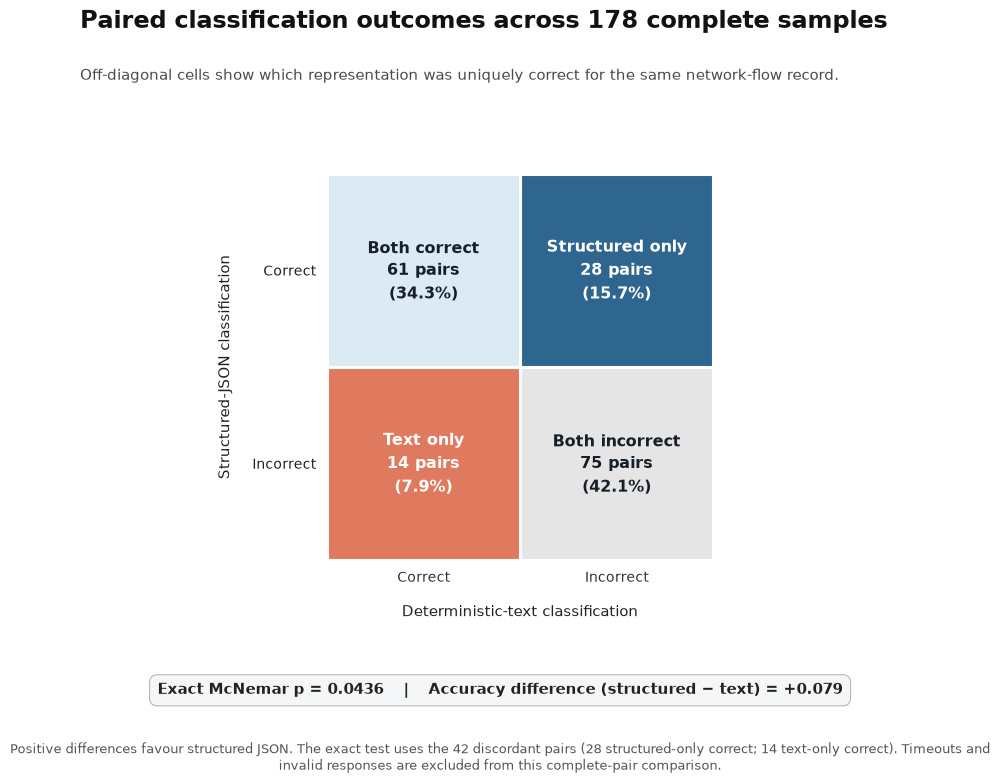

figure_number                                                                            4
figure_layout_status                              refined_with_separate_annotation_regions
complete_pair_count                                                                    178
both_correct_count                                                                      61
structured_only_correct_count                                                           28
text_only_correct_count                                                                 14
both_incorrect_count                                                                    75
discordant_pair_count                                                                   42
paired_accuracy_difference                                                        0.078652
mcnemar_exact_p_value                                                             0.043559
title_region_separated                                                                True

In [10]:
# Regenerate only Figure 4 with explicitly separated vertical regions.
# All paired counts and inferential results remain unchanged.
with mpl.rc_context(PUBLICATION_STYLE):
    figure = plt.figure(
        figsize=(10.0, 8.4),
        facecolor="white",
    )

    # The matrix occupies the central region. A larger bottom margin is
    # reserved for the x-axis label and two separate annotation lines.
    axis = figure.add_axes(
        [
            0.23,
            0.30,
            0.58,
            0.46,
        ]
    )

    axis.imshow(
        paired_outcome_colour_codes,
        cmap=ListedColormap(
            paired_outcome_colours
        ),
        vmin=-0.5,
        vmax=3.5,
        aspect="equal",
        interpolation="nearest",
    )

    for row_position in range(2):
        for column_position in range(2):
            cell_count = int(
                paired_correctness_matrix[
                    row_position,
                    column_position,
                ]
            )

            cell_percentage = safe_divide(
                cell_count,
                len(paired_evaluation_table),
            )

            cell_code = int(
                paired_outcome_colour_codes[
                    row_position,
                    column_position,
                ]
            )

            annotation_colour = (
                "white"
                if cell_code in {1, 2}
                else "#17202A"
            )

            axis.text(
                column_position,
                row_position,
                (
                    f"{paired_outcome_labels[row_position, column_position]}"
                    f"\n{cell_count} pairs"
                    f"\n({cell_percentage:.1%})"
                ),
                ha="center",
                va="center",
                fontsize=11.5,
                fontweight="bold",
                color=annotation_colour,
                linespacing=1.45,
            )

    axis.set_xticks(
        [0, 1],
        labels=[
            "Correct",
            "Incorrect",
        ],
    )

    axis.set_yticks(
        [0, 1],
        labels=[
            "Correct",
            "Incorrect",
        ],
    )

    axis.set_xlabel(
        "Deterministic-text classification",
        labelpad=14,
        fontsize=11,
    )

    axis.set_ylabel(
        "Structured-JSON classification",
        labelpad=14,
        fontsize=11,
    )

    axis.set_xticks(
        np.arange(-0.5, 2, 1),
        minor=True,
    )

    axis.set_yticks(
        np.arange(-0.5, 2, 1),
        minor=True,
    )

    axis.grid(
        which="minor",
        color="white",
        linewidth=2.2,
    )

    axis.tick_params(
        which="both",
        length=0,
        pad=8,
    )

    for spine in axis.spines.values():
        spine.set_visible(False)


    # Dedicated title region.
    figure.text(
        0.08,
        0.955,
        (
            "Paired classification outcomes across "
            "178 complete samples"
        ),
        ha="left",
        va="top",
        fontsize=17,
        fontweight="bold",
        color="#111111",
    )

    figure.text(
        0.08,
        0.885,
        (
            "Off-diagonal cells show which representation "
            "was uniquely correct for the same network-flow record."
        ),
        ha="left",
        va="top",
        fontsize=10.5,
        color="#4A4A4A",
    )


    # Dedicated statistical-result region below the x-axis title.
    figure.text(
        0.50,
        0.145,
        (
            f"Exact McNemar p = "
            f"{mcnemar_exact_p_value:.4f}    |    "
            f"Accuracy difference "
            f"(structured − text) = "
            f"{paired_accuracy_difference:+.3f}"
        ),
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color="#222222",
        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": "#F4F6F7",
            "edgecolor": "#B8B8B8",
            "linewidth": 0.8,
        },
    )


    # Dedicated methodological-note region.
    figure.text(
        0.50,
        0.065,
        (
            "Positive differences favour structured JSON. "
            "The exact test uses the 42 discordant pairs "
            "(28 structured-only correct; 14 text-only correct). "
            "Timeouts and invalid responses are excluded from this "
            "complete-pair comparison."
        ),
        ha="center",
        va="center",
        fontsize=9,
        color="#555555",
        wrap=True,
    )


    # Intentionally replace only the earlier derived Figure 4 files.
    figure.savefig(
        MCNEMAR_FIGURE_PNG_PATH,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    figure.savefig(
        MCNEMAR_FIGURE_PDF_PATH,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()


assert MCNEMAR_FIGURE_PNG_PATH.is_file()
assert MCNEMAR_FIGURE_PDF_PATH.is_file()

assert MCNEMAR_FIGURE_PNG_PATH.stat().st_size > 0
assert MCNEMAR_FIGURE_PDF_PATH.stat().st_size > 0


refined_mcnemar_figure_summary = pd.Series(
    {
        "figure_number": 4,
        "figure_layout_status": (
            "refined_with_separate_annotation_regions"
        ),
        "complete_pair_count": 178,
        "both_correct_count": (
            both_correct_count
        ),
        "structured_only_correct_count": (
            structured_only_correct_count
        ),
        "text_only_correct_count": (
            text_only_correct_count
        ),
        "both_incorrect_count": (
            both_incorrect_count
        ),
        "discordant_pair_count": (
            mcnemar_discordant_count
        ),
        "paired_accuracy_difference": (
            paired_accuracy_difference
        ),
        "mcnemar_exact_p_value": (
            mcnemar_exact_p_value
        ),
        "title_region_separated": True,
        "matrix_region_separated": True,
        "axis_label_region_separated": True,
        "statistical_result_region_separated": True,
        "methodological_note_region_separated": True,
        "png_path": str(
            MCNEMAR_FIGURE_PNG_PATH
        ),
        "png_sha256": sha256_file(
            MCNEMAR_FIGURE_PNG_PATH
        ),
        "pdf_path": str(
            MCNEMAR_FIGURE_PDF_PATH
        ),
        "pdf_sha256": sha256_file(
            MCNEMAR_FIGURE_PDF_PATH
        ),
        "png_dpi": 300,
        "statistical_result_recalculated": False,
        "experimental_record_modified": False,
        "derived_figure_intentionally_replaced": True,
        "private_ground_truth_loaded": True,
        "network_request_made": False,
    },
    name="value",
)

refined_mcnemar_figure_summary

## 8. Paired-bootstrap metric differences

McNemar's test evaluates the paired difference in classification correctness, but it does not quantify uncertainty for Precision, Recall, F1, Specificity, or Balanced Accuracy.

This section therefore performs 10,000 class-stratified paired bootstrap replicates on the 178 complete samples. Within each replicate, the same sampled record positions are used for both representations, preserving the within-record dependence that defines the experiment.

For every metric, the reported contrast is:

\[
\Delta = \text{Structured JSON} - \text{Deterministic text}
\]

Positive values favour structured JSON, negative values favour deterministic text, and a 95% interval containing zero indicates that the bootstrap analysis does not establish a directional difference for that metric.

The exact McNemar test remains the primary paired test of accuracy. Bootstrap intervals for the remaining metrics are supporting paired estimates and are interpreted without multiplicity-adjusted significance claims.

,metric_display,structured_estimate,deterministic_text_estimate,difference_and_95_ci,ci_excludes_zero,supported_direction
0,Accuracy,0.5000,0.4213,"+0.0787 [+0.0112, +0.1461]",True,structured_higher
1,Precision,0.4634,0.3455,"+0.1180 [-0.0104, +0.2508]",False,interval_includes_zero
2,Recall (sensitivity),0.2209,0.2209,"+0.0000 [-0.0930, +0.0930]",False,interval_includes_zero
3,F1,0.2992,0.2695,"+0.0297 [-0.0747, +0.1318]",False,interval_includes_zero
4,Specificity,0.7609,0.6087,"+0.1522 [+0.0435, +0.2609]",True,structured_higher
5,Balanced accuracy,0.4909,0.4148,"+0.0761 [+0.0082, +0.1436]",True,structured_higher


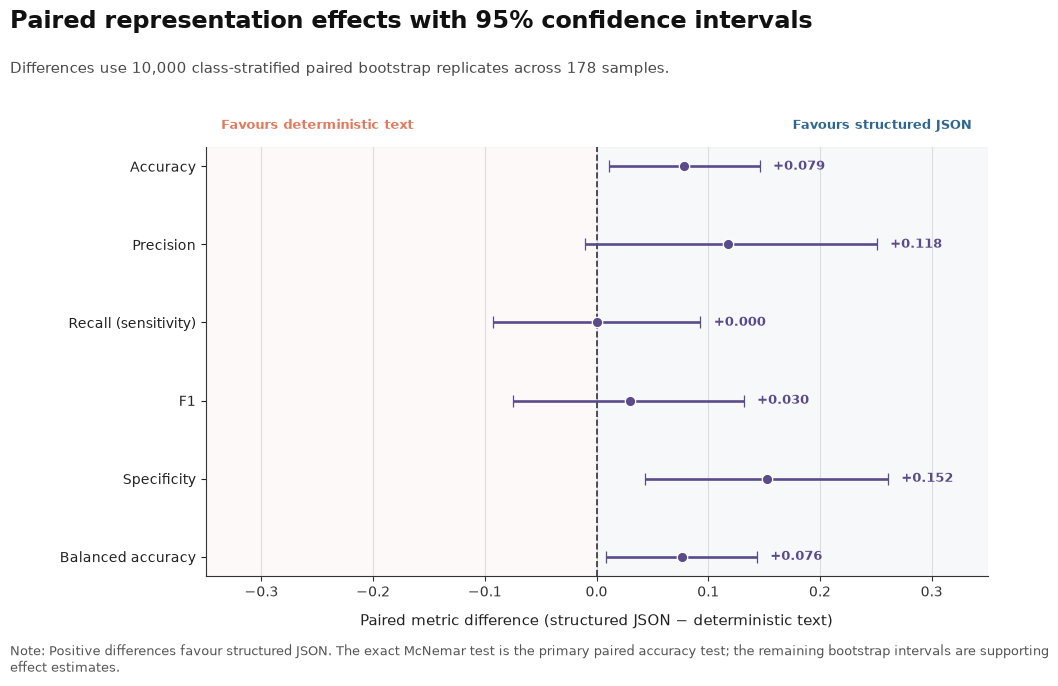

analysis_population                                    complete_paired_responses
complete_pair_count                                                          178
benign_pair_count                                                             92
dos_pair_count                                                                86
metric_difference_count                                                        6
bootstrap_method                    class-stratified paired percentile bootstrap
bootstrap_seed                                                               742
bootstrap_replicate_count                                                  10000
confidence_level                                                            0.95
mcnemar_exact_p_value                                                   0.043559
figure_png_path                /Users/ruiwang/Developer/compsci742-rui-pilot/...
figure_png_sha256              a8fe8957c5d3c499bc41cd786884ff471606c7d3d9d3ff...
figure_pdf_path             

In [11]:
PAIRED_BOOTSTRAP_SEED = 742
PAIRED_BOOTSTRAP_REPLICATE_COUNT = 10_000
PAIRED_BOOTSTRAP_CONFIDENCE_LEVEL = 0.95


paired_true_values = (
    paired_evaluation_table[
        "true_binary"
    ].to_numpy(dtype=int)
)

paired_structured_predictions = (
    paired_evaluation_table[
        "structured_predicted_binary"
    ].to_numpy(dtype=int)
)

paired_text_predictions = (
    paired_evaluation_table[
        "deterministic_text_predicted_binary"
    ].to_numpy(dtype=int)
)

paired_benign_positions = np.flatnonzero(
    paired_true_values == 0
)

paired_dos_positions = np.flatnonzero(
    paired_true_values == 1
)

assert len(paired_true_values) == 178
assert len(paired_benign_positions) == 92
assert len(paired_dos_positions) == 86


# The same sampled positions are applied to both prediction arrays in
# every replicate, which preserves the paired experimental structure.
paired_bootstrap_rng = np.random.default_rng(
    PAIRED_BOOTSTRAP_SEED
)

paired_metric_difference_distributions = {
    metric_name: np.empty(
        PAIRED_BOOTSTRAP_REPLICATE_COUNT,
        dtype=float,
    )
    for metric_name in METRIC_ORDER
}

paired_structured_metric_distributions = {
    metric_name: np.empty(
        PAIRED_BOOTSTRAP_REPLICATE_COUNT,
        dtype=float,
    )
    for metric_name in METRIC_ORDER
}

paired_text_metric_distributions = {
    metric_name: np.empty(
        PAIRED_BOOTSTRAP_REPLICATE_COUNT,
        dtype=float,
    )
    for metric_name in METRIC_ORDER
}


for bootstrap_index in range(
    PAIRED_BOOTSTRAP_REPLICATE_COUNT
):
    sampled_benign_positions = (
        paired_bootstrap_rng.choice(
            paired_benign_positions,
            size=len(paired_benign_positions),
            replace=True,
        )
    )

    sampled_dos_positions = (
        paired_bootstrap_rng.choice(
            paired_dos_positions,
            size=len(paired_dos_positions),
            replace=True,
        )
    )

    sampled_positions = np.concatenate(
        [
            sampled_benign_positions,
            sampled_dos_positions,
        ]
    )

    sampled_true_values = paired_true_values[
        sampled_positions
    ]

    sampled_structured_predictions = (
        paired_structured_predictions[
            sampled_positions
        ]
    )

    sampled_text_predictions = (
        paired_text_predictions[
            sampled_positions
        ]
    )

    structured_bootstrap_metrics, _ = (
        calculate_binary_detection_metrics(
            true_binary=sampled_true_values,
            predicted_binary=(
                sampled_structured_predictions
            ),
        )
    )

    text_bootstrap_metrics, _ = (
        calculate_binary_detection_metrics(
            true_binary=sampled_true_values,
            predicted_binary=(
                sampled_text_predictions
            ),
        )
    )

    for metric_name in METRIC_ORDER:
        structured_metric_value = (
            structured_bootstrap_metrics[
                metric_name
            ]
        )

        text_metric_value = (
            text_bootstrap_metrics[
                metric_name
            ]
        )

        paired_structured_metric_distributions[
            metric_name
        ][bootstrap_index] = (
            structured_metric_value
        )

        paired_text_metric_distributions[
            metric_name
        ][bootstrap_index] = (
            text_metric_value
        )

        paired_metric_difference_distributions[
            metric_name
        ][bootstrap_index] = (
            structured_metric_value
            - text_metric_value
        )


paired_metric_lookup = (
    paired_metrics_table
    .set_index("condition")
    .to_dict(orient="index")
)

paired_lower_percentile = (
    100
    * (
        1
        - PAIRED_BOOTSTRAP_CONFIDENCE_LEVEL
    )
    / 2
)

paired_upper_percentile = (
    100 - paired_lower_percentile
)

paired_metric_difference_rows = []


for metric_name in METRIC_ORDER:
    structured_estimate = float(
        paired_metric_lookup["structured"][
            metric_name
        ]
    )

    text_estimate = float(
        paired_metric_lookup[
            "deterministic_text"
        ][metric_name]
    )

    observed_difference = (
        structured_estimate - text_estimate
    )

    difference_distribution = (
        paired_metric_difference_distributions[
            metric_name
        ]
    )

    finite_difference_distribution = (
        difference_distribution[
            np.isfinite(
                difference_distribution
            )
        ]
    )

    if len(finite_difference_distribution) == 0:
        raise ValueError(
            "No finite paired-bootstrap differences "
            f"were produced for {metric_name}."
        )

    confidence_interval_lower = float(
        np.percentile(
            finite_difference_distribution,
            paired_lower_percentile,
        )
    )

    confidence_interval_upper = float(
        np.percentile(
            finite_difference_distribution,
            paired_upper_percentile,
        )
    )

    confidence_interval_excludes_zero = bool(
        confidence_interval_lower > 0
        or confidence_interval_upper < 0
    )

    if confidence_interval_lower > 0:
        supported_direction = (
            "structured_higher"
        )
    elif confidence_interval_upper < 0:
        supported_direction = (
            "deterministic_text_higher"
        )
    else:
        supported_direction = (
            "interval_includes_zero"
        )

    paired_metric_difference_rows.append(
        {
            "analysis_population": (
                "complete_paired_responses"
            ),
            "metric": metric_name,
            "metric_display": (
                METRIC_DISPLAY_NAMES[
                    metric_name
                ]
            ),
            "structured_estimate": (
                structured_estimate
            ),
            "deterministic_text_estimate": (
                text_estimate
            ),
            "structured_minus_text_difference": (
                observed_difference
            ),
            "ci_level": (
                PAIRED_BOOTSTRAP_CONFIDENCE_LEVEL
            ),
            "ci_lower": (
                confidence_interval_lower
            ),
            "ci_upper": (
                confidence_interval_upper
            ),
            "ci_excludes_zero": (
                confidence_interval_excludes_zero
            ),
            "supported_direction": (
                supported_direction
            ),
            "bootstrap_method": (
                "class-stratified paired percentile bootstrap"
            ),
            "bootstrap_replicates_requested": (
                PAIRED_BOOTSTRAP_REPLICATE_COUNT
            ),
            "bootstrap_replicates_finite": len(
                finite_difference_distribution
            ),
            "bootstrap_seed": (
                PAIRED_BOOTSTRAP_SEED
            ),
            "complete_pair_count": len(
                paired_evaluation_table
            ),
            "benign_pair_count": len(
                paired_benign_positions
            ),
            "dos_pair_count": len(
                paired_dos_positions
            ),
        }
    )


paired_metric_difference_table = pd.DataFrame(
    paired_metric_difference_rows
)

assert len(paired_metric_difference_table) == len(
    METRIC_ORDER
)

assert paired_metric_difference_table[
    "bootstrap_replicates_finite"
].gt(0).all()

assert (
    paired_metric_difference_table[
        "ci_lower"
    ]
    <= paired_metric_difference_table[
        "ci_upper"
    ]
).all()

accuracy_difference_row = (
    paired_metric_difference_table.loc[
        paired_metric_difference_table[
            "metric"
        ]
        == "accuracy"
    ].iloc[0]
)

assert np.isclose(
    accuracy_difference_row[
        "structured_minus_text_difference"
    ],
    paired_accuracy_difference,
)


paired_metric_difference_display = (
    paired_metric_difference_table[
        [
            "metric_display",
            "structured_estimate",
            "deterministic_text_estimate",
            "structured_minus_text_difference",
            "ci_lower",
            "ci_upper",
            "ci_excludes_zero",
            "supported_direction",
        ]
    ]
    .copy()
)

paired_metric_difference_display[
    [
        "structured_estimate",
        "deterministic_text_estimate",
        "structured_minus_text_difference",
        "ci_lower",
        "ci_upper",
    ]
] = (
    paired_metric_difference_display[
        [
            "structured_estimate",
            "deterministic_text_estimate",
            "structured_minus_text_difference",
            "ci_lower",
            "ci_upper",
        ]
    ].round(4)
)

paired_metric_difference_display[
    "difference_and_95_ci"
] = (
    paired_metric_difference_display[
        "structured_minus_text_difference"
    ].map(lambda value: f"{value:+.4f}")
    + " ["
    + paired_metric_difference_display[
        "ci_lower"
    ].map(lambda value: f"{value:+.4f}")
    + ", "
    + paired_metric_difference_display[
        "ci_upper"
    ].map(lambda value: f"{value:+.4f}")
    + "]"
)

display(
    paired_metric_difference_display[
        [
            "metric_display",
            "structured_estimate",
            "deterministic_text_estimate",
            "difference_and_95_ci",
            "ci_excludes_zero",
            "supported_direction",
        ]
    ]
)


# Create Figure 5: paired metric differences with a common zero line.
PAIRED_DIFFERENCE_FIGURE_PNG_PATH = (
    FIGURES_DIR
    / "figure_05_paired_metric_differences.png"
)

PAIRED_DIFFERENCE_FIGURE_PDF_PATH = (
    FIGURES_DIR
    / "figure_05_paired_metric_differences.pdf"
)

paired_plot_rows = (
    paired_metric_difference_table
    .set_index("metric")
    .loc[METRIC_ORDER]
)

paired_difference_estimates = (
    paired_plot_rows[
        "structured_minus_text_difference"
    ].to_numpy(dtype=float)
)

paired_difference_lower_bounds = (
    paired_plot_rows[
        "ci_lower"
    ].to_numpy(dtype=float)
)

paired_difference_upper_bounds = (
    paired_plot_rows[
        "ci_upper"
    ].to_numpy(dtype=float)
)

maximum_absolute_bound = float(
    np.max(
        np.abs(
            np.concatenate(
                [
                    paired_difference_lower_bounds,
                    paired_difference_upper_bounds,
                ]
            )
        )
    )
)

symmetric_axis_limit = max(
    0.10,
    math.ceil(
        maximum_absolute_bound * 1.25 * 20
    ) / 20,
)

paired_difference_errors = np.vstack(
    [
        (
            paired_difference_estimates
            - paired_difference_lower_bounds
        ),
        (
            paired_difference_upper_bounds
            - paired_difference_estimates
        ),
    ]
)

paired_metric_y_positions = np.arange(
    len(METRIC_ORDER)
)

PAIRED_DIFFERENCE_COLOR = "#5B4B8A"


with mpl.rc_context(PUBLICATION_STYLE):
    figure = plt.figure(
        figsize=(11.5, 7.4),
        facecolor="white",
    )

    axis = figure.add_axes(
        [
            0.25,
            0.19,
            0.68,
            0.58,
        ]
    )

    # Subtle directional backgrounds make interpretation immediate
    # without replacing the numerical zero reference.
    axis.axvspan(
        -symmetric_axis_limit,
        0,
        color=CONDITION_COLORS[
            "deterministic_text"
        ],
        alpha=0.045,
        zorder=0,
    )

    axis.axvspan(
        0,
        symmetric_axis_limit,
        color=CONDITION_COLORS[
            "structured"
        ],
        alpha=0.045,
        zorder=0,
    )

    axis.axvline(
        0,
        color="#333333",
        linewidth=1.2,
        linestyle="--",
        zorder=1,
    )

    axis.errorbar(
        x=paired_difference_estimates,
        y=paired_metric_y_positions,
        xerr=paired_difference_errors,
        fmt="o",
        markersize=7.5,
        markerfacecolor=(
            PAIRED_DIFFERENCE_COLOR
        ),
        markeredgecolor="white",
        markeredgewidth=0.9,
        color=PAIRED_DIFFERENCE_COLOR,
        ecolor=PAIRED_DIFFERENCE_COLOR,
        elinewidth=1.9,
        capsize=4,
        capthick=1.4,
        zorder=3,
    )

    for (
        estimate,
        lower_bound,
        upper_bound,
        y_position,
    ) in zip(
        paired_difference_estimates,
        paired_difference_lower_bounds,
        paired_difference_upper_bounds,
        paired_metric_y_positions,
    ):
        if estimate >= 0:
            label_x_position = min(
                upper_bound + 0.012,
                symmetric_axis_limit * 0.97,
            )
            horizontal_alignment = "left"
        else:
            label_x_position = max(
                lower_bound - 0.012,
                -symmetric_axis_limit * 0.97,
            )
            horizontal_alignment = "right"

        axis.text(
            label_x_position,
            y_position,
            f"{estimate:+.3f}",
            ha=horizontal_alignment,
            va="center",
            fontsize=9,
            color=PAIRED_DIFFERENCE_COLOR,
            fontweight="bold",
        )

    axis.set_yticks(
        paired_metric_y_positions,
        labels=[
            METRIC_DISPLAY_NAMES[
                metric_name
            ]
            for metric_name in METRIC_ORDER
        ],
    )

    axis.invert_yaxis()

    axis.set_xlim(
        -symmetric_axis_limit,
        symmetric_axis_limit,
    )

    axis.set_xlabel(
        (
            "Paired metric difference "
            "(structured JSON − deterministic text)"
        ),
        labelpad=10,
    )

    axis.set_ylabel("")

    axis.xaxis.grid(
        True,
        color="#D9D9D9",
        linewidth=0.8,
        alpha=0.85,
    )

    axis.set_axisbelow(True)

    axis.text(
        0.02,
        1.035,
        "Favours deterministic text",
        transform=axis.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        color=CONDITION_COLORS[
            "deterministic_text"
        ],
        fontweight="bold",
    )

    axis.text(
        0.98,
        1.035,
        "Favours structured JSON",
        transform=axis.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        color=CONDITION_COLORS[
            "structured"
        ],
        fontweight="bold",
    )

    figure.text(
        0.08,
        0.955,
        (
            "Paired representation effects "
            "with 95% confidence intervals"
        ),
        ha="left",
        va="top",
        fontsize=17,
        fontweight="bold",
        color="#111111",
    )

    figure.text(
        0.08,
        0.885,
        (
            "Differences use 10,000 class-stratified "
            "paired bootstrap replicates across 178 samples."
        ),
        ha="left",
        va="top",
        fontsize=10.5,
        color="#4A4A4A",
    )

    figure.text(
        0.08,
        0.055,
        (
            "Note: Positive differences favour structured JSON. "
            "The exact McNemar test is the primary paired accuracy "
            "test; the remaining bootstrap intervals are supporting "
            "effect estimates."
        ),
        ha="left",
        va="bottom",
        fontsize=9,
        color="#555555",
        wrap=True,
    )

    figure.savefig(
        PAIRED_DIFFERENCE_FIGURE_PNG_PATH,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    figure.savefig(
        PAIRED_DIFFERENCE_FIGURE_PDF_PATH,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()


assert PAIRED_DIFFERENCE_FIGURE_PNG_PATH.is_file()
assert PAIRED_DIFFERENCE_FIGURE_PDF_PATH.is_file()

assert (
    PAIRED_DIFFERENCE_FIGURE_PNG_PATH.stat().st_size
    > 0
)

assert (
    PAIRED_DIFFERENCE_FIGURE_PDF_PATH.stat().st_size
    > 0
)


paired_bootstrap_summary = pd.Series(
    {
        "analysis_population": (
            "complete_paired_responses"
        ),
        "complete_pair_count": len(
            paired_evaluation_table
        ),
        "benign_pair_count": len(
            paired_benign_positions
        ),
        "dos_pair_count": len(
            paired_dos_positions
        ),
        "metric_difference_count": len(
            paired_metric_difference_table
        ),
        "bootstrap_method": (
            "class-stratified paired percentile bootstrap"
        ),
        "bootstrap_seed": (
            PAIRED_BOOTSTRAP_SEED
        ),
        "bootstrap_replicate_count": (
            PAIRED_BOOTSTRAP_REPLICATE_COUNT
        ),
        "confidence_level": (
            PAIRED_BOOTSTRAP_CONFIDENCE_LEVEL
        ),
        "mcnemar_exact_p_value": (
            mcnemar_exact_p_value
        ),
        "figure_png_path": str(
            PAIRED_DIFFERENCE_FIGURE_PNG_PATH
        ),
        "figure_png_sha256": sha256_file(
            PAIRED_DIFFERENCE_FIGURE_PNG_PATH
        ),
        "figure_pdf_path": str(
            PAIRED_DIFFERENCE_FIGURE_PDF_PATH
        ),
        "figure_pdf_sha256": sha256_file(
            PAIRED_DIFFERENCE_FIGURE_PDF_PATH
        ),
        "paired_bootstrap_completed": True,
        "private_ground_truth_loaded": True,
        "evaluation_artifact_written": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "paired_bootstrap_metric_differences"
        ),
    },
    name="value",
)

paired_bootstrap_summary

## 8. Interim answer to RQ1: effect of input representation on LLM detection

### 8.1 Research question

**RQ1 asks whether changing only the representation of the same 46 network-flow
features affects the LLM's ability to classify a flow as Benign or DoS.**

The two experimental conditions were:

1. **Structured JSON** — all 46 feature names and values were supplied as a
   machine-readable JSON object.
2. **Deterministic text** — the same 46 feature names and values were rendered
   into a fixed natural-language template.

The underlying sample, feature set, feature values, model, decoding configuration,
classification prompt, response schema, and execution environment were held
constant. Consequently, the intended experimental contrast is the representation
of the input rather than the information supplied to the model.

---

### 8.2 Evaluation population and treatment of failed requests

The evaluation began with 200 fixed samples:

- 100 Benign samples;
- 100 DoS samples;
- two representations per sample;
- 400 planned LLM requests in total.

All 400 request records were retained in the frozen experimental record. Failed
requests were not deleted, retried, repaired, or converted into classification
errors.

The observed response outcomes were:

| Representation | True class | Planned | Valid | Timeout | Schema invalid |
|---|---:|---:|---:|---:|---:|
| Structured JSON | Benign | 100 | 92 | 8 | 0 |
| Structured JSON | DoS | 100 | 87 | 13 | 0 |
 |
| Deterministic text | Benign | 100 | 93 | 7 | 0 |
| Deterministic text | DoS | 100 | 87 | 12 | 1 |
| **Total** |  | **400** | **359** | **40** | **1** |

Condition-specific descriptive metrics therefore used 179 valid structured
responses and 180 valid deterministic-text responses.

The primary representation comparison used only the **178 samples for which both
representations produced valid classification responses**. This complete-pair
restriction preserves the within-sample experimental comparison and prevents
differences in response availability from being counted as classification errors.

---

### 8.3 Condition-specific descriptive performance

Among all valid responses available within each condition, the structured-JSON
condition achieved higher accuracy, precision, specificity, F1, and balanced
accuracy. Recall for the DoS class was identical in the two conditions.

| Metric | Structured JSON, n=179 | Deterministic text, n=180 |
|---|---:|---:|
| Accuracy | 0.4972 | 0.4222 |
| Precision | 0.4634 | 0.3455 |
| Recall / sensitivity | 0.2184 | 0.2184 |
| F1 | 0.2969 | 0.2676 |
| Specificity | 0.7609 | 0.6129 |
| Balanced accuracy | 0.4896 | 0.4156 |

These estimates are descriptive because the two condition-specific populations
differ by one valid response. The paired analysis below is the primary inferential
comparison.

---

### 8.4 Primary paired comparison

The paired analysis contained 178 complete samples:

- 92 Benign samples;
- 86 DoS samples.

The paired correctness outcomes were:

| Paired outcome | Sample count | Percentage |
|---|---:|---:|
| Both representations correct | 61 | 34.3% |
| Structured JSON only correct | 28 | 15.7% |
| Deterministic text only correct | 14 | 7.9% |
| Both representations incorrect | 75 | 42.1% |
| **Total** | **178** | **100.0%** |

Structured JSON correctly classified 28 samples that deterministic text
misclassified, whereas deterministic text correctly classified 14 samples that
structured JSON misclassified.

This produced a paired accuracy difference of:

\[
\Delta Accuracy =
Accuracy_{\text{structured}}-Accuracy_{\text{text}}
=0.5000-0.4213
=+0.0787.
\]

Thus, structured JSON increased paired accuracy by approximately **7.9 percentage
points**.

The exact two-sided McNemar test, based on the 42 discordant pairs, produced:

\[
p=0.0436.
\]

At the prespecified 0.05 threshold, the null hypothesis of equal paired accuracy
is rejected. The evidence is statistically significant but close to the threshold
and should therefore be described as **modest evidence**, rather than strong or
definitive evidence.

---

### 8.5 Paired effect estimates and uncertainty

A class-stratified paired percentile bootstrap with 10,000 replicates was used to
estimate 95% confidence intervals for the metric differences. Positive differences
favour structured JSON.

| Metric | Structured | Text | Difference | 95% CI | Interpretation |
|---|---:|---:|---:|---:|---|
| Accuracy | 0.5000 | 0.4213 | +0.0787 | [+0.0112, +0.1461] | Structured higher |
| Precision | 0.4634 | 0.3455 | +0.1180 | [-0.0104, +0.2508] | Inconclusive |
| Recall / sensitivity | 0.2209 | 0.2209 | +0.0000 | [-0.0930, +0.0930] | No observed difference |
| F1 | 0.2992 | 0.2695 | +0.0297 | [-0.0747, +0.1318] | Inconclusive |
| Specificity | 0.7609 | 0.6087 | +0.1522 | [+0.0435, +0.2609] | Structured higher |
| Balanced accuracy | 0.4909 | 0.4148 | +0.0761 | [+0.0082, +0.1436] | Structured higher |

The confidence intervals exclude zero for accuracy, specificity, and balanced
accuracy. They include zero for precision, recall, and F1; therefore, the present
experiment does not provide sufficient evidence that the representation changed
those three metrics.

---

### 8.6 Interpretation of the representation effect

The structured-JSON advantage was driven principally by improved recognition of
Benign samples:

- Structured JSON correctly classified 70 of 92 paired Benign samples.
- Deterministic text correctly classified 56 of the same 92 Benign samples.
- Structured specificity was 0.7609, compared with 0.6087 for deterministic text.

In contrast, both representations correctly identified only 19 of the 86 paired
DoS samples:

\[
Recall_{\text{structured}}
=
Recall_{\text{text}}
=
\frac{19}{86}
=
0.2209.
\]

Therefore, structured JSON did **not** improve DoS sensitivity in this experiment.
Its accuracy advantage arose because it generated fewer false-positive DoS
classifications for truly Benign samples.

This distinction is important: the results support a representation effect on the
model's overall decision behaviour, especially its treatment of Benign traffic,
but they do not support a claim that structured JSON made the model better at
detecting DoS attacks.

---

### 8.7 Interim answer to RQ1

For MiniMax-M3, presenting the same 46 network-flow features as structured JSON
produced higher paired classification accuracy than presenting them as
deterministic text. The estimated accuracy improvement was 7.9 percentage points,
with an exact McNemar p-value of 0.0436 and a paired-bootstrap 95% confidence
interval of [+1.1, +14.6] percentage points.

The structured condition also produced higher specificity and balanced accuracy.
However, both representations had low and identical DoS recall of approximately
22%. Accordingly, the result should be interpreted as evidence that input
representation affected the model's classification behaviour, primarily by
reducing false alarms on Benign samples, rather than evidence of improved DoS
detection.

The absolute performance of both representations was limited: paired balanced
accuracy was 0.4909 for structured JSON and 0.4148 for deterministic text.
Consequently, neither representation should be characterised as providing strong
DoS detection performance in this experiment.

---

### 8.8 Scope and limitations of this conclusion

This conclusion applies to the locked experimental configuration used here:

- one LLM and backend configuration;
- one balanced 200-sample Benign/DoS pilot dataset;
- one fixed set of 46 network-flow features;
- one structured-JSON template;
- one deterministic-text template;
- valid responses from 178 complete pairs.

Because the evaluation dataset was intentionally balanced, these results do not
estimate real-world operational performance under naturally occurring class
prevalence. The experiment also does not establish that structured representation
will improve every LLM, prompt, dataset, or intrusion category.

Timeouts and the schema-invalid response were analysed as response-availability
outcomes and were not converted into classification predictions. Therefore, the
classification results describe performance conditional on obtaining valid
responses. Deployment-oriented conclusions should consider both classification
quality and response availability.

---

### 8.9 Role of the supporting baselines

The next stage evaluates Logistic Regression and Random Forest classifiers using
the same locked set of 46 predictors and leakage-safe out-of-fold predictions.

These models are **supporting baselines for RQ1**, not part of RQ2. They provide a
reference for interpreting the absolute LLM results:

- whether the 46 features contain learnable Benign/DoS signal;
- whether a conventional classifier can recover that signal;
- how the LLM conditions compare with standard tabular classifiers.

The baselines do not change the primary causal contrast between structured JSON
and deterministic text. The final RQ1 summary will combine the LLM representation
comparison reported above with the supporting baseline results.

RQ2 is addressed separately. It concerns which five features the LLM cites in
each valid response and how those citations align with sample-level feature
contributions from the supporting models. Feature citation is treated as reported
model rationale and is not assumed to be a causal or faithful explanation.

## 9. Supporting-baseline feature-contract audit

Logistic Regression and Random Forest are included as supporting baselines rather than primary experimental conditions. Before fitting either model, the baseline feature space must be reconstructed from the locked `primary_46` representation and checked against the documented feature policy.

This section:

- extracts the ordered 46-feature list from the structured representation;
- verifies that all 200 sampled feature rows contain those fields;
- confirms that no label or direct identifier enters the predictor matrix;
- inspects the documented feature-policy schema; and
- identifies the available metadata for distinguishing quantitative and categorical predictors.

No model is trained in this section. This prevents silent assumptions about integer-coded categorical variables and supports leakage-safe preprocessing in the subsequent cross-validation pipeline.

In [12]:
FEATURE_POLICY_PATH = (
    PROJECT_ROOT
    / "configs"
    / "feature_policy_provisional.csv"
)

assert FEATURE_POLICY_PATH.is_file()


# Recover the exact structured-representation path recorded by the
# Notebook 08 validation manifest.
STRUCTURED_REPRESENTATION_PATH = resolve_manifest_path(
    validation_manifest[
        "source_artifacts"
    ][
        "structured_representation"
    ]["path"]
)

assert STRUCTURED_REPRESENTATION_PATH.is_file()

assert sha256_file(
    STRUCTURED_REPRESENTATION_PATH
) == validation_manifest[
    "source_artifacts"
][
    "structured_representation"
]["sha256"]


# Load baseline-supporting inputs. The feature table deliberately
# contains no private labels; labels remain in the separate validated
# ground-truth table.
sample_feature_table = pd.read_csv(
    FEATURE_TABLE_PATH
)

feature_policy_table = pd.read_csv(
    FEATURE_POLICY_PATH
)

structured_representation_records = read_jsonl(
    STRUCTURED_REPRESENTATION_PATH
)


assert len(sample_feature_table) == 200
assert len(structured_representation_records) == 200

assert "sample_id" in sample_feature_table.columns
assert sample_feature_table["sample_id"].is_unique

assert set(
    sample_feature_table["sample_id"]
) == set(
    ground_truth_join_table["sample_id"]
)


# Extract the ordered primary_46 feature contract independently from
# every structured record.
ordered_primary_feature_lists = []

for record_position, representation_record in enumerate(
    structured_representation_records
):
    model_input = representation_record.get(
        "model_input"
    )

    if not isinstance(model_input, str):
        raise ValueError(
            "Structured representation record "
            f"{record_position} has no string model_input."
        )

    parsed_model_input = json.loads(
        model_input
    )

    if not isinstance(parsed_model_input, dict):
        raise ValueError(
            "Structured model_input must parse "
            "to a JSON object."
        )

    feature_items = parsed_model_input.get(
        "features"
    )

    if not isinstance(feature_items, list):
        raise ValueError(
            "Structured model_input must contain "
            "a features list."
        )

    ordered_feature_names = []

    for feature_position, feature_item in enumerate(
        feature_items
    ):
        if not isinstance(feature_item, dict):
            raise ValueError(
                f"Feature {feature_position} in record "
                f"{record_position} is not an object."
            )

        feature_name = feature_item.get("name")

        if not isinstance(feature_name, str):
            raise ValueError(
                f"Feature {feature_position} in record "
                f"{record_position} has no valid name."
            )

        ordered_feature_names.append(feature_name)

    if len(ordered_feature_names) != 46:
        raise ValueError(
            "Every primary structured record must contain "
            f"46 features; record {record_position} contains "
            f"{len(ordered_feature_names)}."
        )

    if len(set(ordered_feature_names)) != 46:
        raise ValueError(
            "Primary feature names must be distinct within "
            f"record {record_position}."
        )

    ordered_primary_feature_lists.append(
        ordered_feature_names
    )


PRIMARY_FEATURE_NAMES = (
    ordered_primary_feature_lists[0]
)

assert all(
    feature_names == PRIMARY_FEATURE_NAMES
    for feature_names in ordered_primary_feature_lists
)

assert len(PRIMARY_FEATURE_NAMES) == 46
assert len(set(PRIMARY_FEATURE_NAMES)) == 46


# Confirm that every locked primary feature exists in the sampled
# feature table and that no ground-truth field is present there.
missing_primary_feature_columns = sorted(
    set(PRIMARY_FEATURE_NAMES)
    - set(sample_feature_table.columns)
)

assert missing_primary_feature_columns == []

for forbidden_column in [
    "Label",
    "Attack",
    "true_label",
    "true_binary",
]:
    assert forbidden_column not in (
        sample_feature_table.columns
    )


# Create the ordered raw predictor table, but do not fit or transform
# it yet.
raw_primary_predictor_table = (
    sample_feature_table[
        [
            "sample_id",
            *PRIMARY_FEATURE_NAMES,
        ]
    ]
    .copy()
    .sort_values("sample_id")
    .reset_index(drop=True)
)

assert raw_primary_predictor_table.shape == (
    200,
    47,
)

assert raw_primary_predictor_table[
    "sample_id"
].is_unique


# Verify that the sample feature values reproduce the structured
# representation values exactly at the JSON scalar level.
structured_values_by_sample = {}

for representation_record in (
    structured_representation_records
):
    sample_id = representation_record.get(
        "sample_id"
    )

    if not isinstance(sample_id, str):
        raise ValueError(
            "Each structured representation record "
            "must contain a sample_id outside model_input."
        )

    parsed_model_input = json.loads(
        representation_record["model_input"]
    )

    structured_values_by_sample[sample_id] = {
        feature_item["name"]: feature_item["value"]
        for feature_item in parsed_model_input[
            "features"
        ]
    }

assert len(structured_values_by_sample) == 200


def scalar_values_equivalent(
    table_value,
    representation_value,
) -> bool:
    """
    Compare predictor values without treating integer-valued floats
    as different from the equivalent JSON integer.
    """
    if pd.isna(table_value):
        return representation_value is None

    if isinstance(
        representation_value,
        (int, float),
    ) and not isinstance(
        representation_value,
        bool,
    ):
        try:
            return bool(
                np.isclose(
                    float(table_value),
                    float(representation_value),
                    rtol=0.0,
                    atol=0.0,
                    equal_nan=False,
                )
            )
        except (TypeError, ValueError):
            return False

    return str(table_value) == str(
        representation_value
    )


value_mismatch_rows = []

for feature_row in (
    raw_primary_predictor_table.to_dict(
        orient="records"
    )
):
    sample_id = feature_row["sample_id"]

    representation_values = (
        structured_values_by_sample[
            sample_id
        ]
    )

    for feature_name in PRIMARY_FEATURE_NAMES:
        if not scalar_values_equivalent(
            feature_row[feature_name],
            representation_values[
                feature_name
            ],
        ):
            value_mismatch_rows.append(
                {
                    "sample_id": sample_id,
                    "feature_name": feature_name,
                }
            )

assert value_mismatch_rows == []


# Identify which policy column contains the feature names by matching
# its values against the locked primary_46 set.
feature_name_column_candidates = []

primary_feature_name_set = set(
    PRIMARY_FEATURE_NAMES
)

for policy_column in feature_policy_table.columns:
    policy_values = set(
        feature_policy_table[
            policy_column
        ]
        .dropna()
        .astype(str)
    )

    if primary_feature_name_set.issubset(
        policy_values
    ):
        feature_name_column_candidates.append(
            policy_column
        )

if len(feature_name_column_candidates) != 1:
    raise ValueError(
        "Expected exactly one feature-policy column containing "
        "all primary feature names, but found "
        f"{feature_name_column_candidates}."
    )

FEATURE_POLICY_NAME_COLUMN = (
    feature_name_column_candidates[0]
)

primary_feature_policy_table = (
    feature_policy_table.loc[
        feature_policy_table[
            FEATURE_POLICY_NAME_COLUMN
        ]
        .astype(str)
        .isin(PRIMARY_FEATURE_NAMES)
    ]
    .copy()
)

assert len(primary_feature_policy_table) == 46

assert primary_feature_policy_table[
    FEATURE_POLICY_NAME_COLUMN
].astype(str).is_unique

assert set(
    primary_feature_policy_table[
        FEATURE_POLICY_NAME_COLUMN
    ].astype(str)
) == primary_feature_name_set


# Summarise predictor storage properties without displaying individual
# sample values.
predictor_storage_summary = pd.DataFrame(
    {
        "feature_name": PRIMARY_FEATURE_NAMES,
        "pandas_dtype": [
            str(
                raw_primary_predictor_table[
                    feature_name
                ].dtype
            )
            for feature_name in PRIMARY_FEATURE_NAMES
        ],
        "unique_value_count": [
            int(
                raw_primary_predictor_table[
                    feature_name
                ].nunique(
                    dropna=True
                )
            )
            for feature_name in PRIMARY_FEATURE_NAMES
        ],
        "missing_value_count": [
            int(
                raw_primary_predictor_table[
                    feature_name
                ].isna()
                .sum()
            )
            for feature_name in PRIMARY_FEATURE_NAMES
        ],
    }
)


# Display the policy schema and low-cardinality value catalog. This
# reveals the documented roles needed for preprocessing without
# printing the sampled predictor values.
feature_policy_value_catalog_rows = []

for policy_column in (
    primary_feature_policy_table.columns
):
    unique_values = sorted(
        primary_feature_policy_table[
            policy_column
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    feature_policy_value_catalog_rows.append(
        {
            "policy_column": policy_column,
            "unique_value_count": len(
                unique_values
            ),
            "unique_values_if_at_most_20": (
                unique_values
                if len(unique_values) <= 20
                else "<more than 20 values>"
            ),
        }
    )

feature_policy_value_catalog = pd.DataFrame(
    feature_policy_value_catalog_rows
)


display(feature_policy_value_catalog)

display(
    predictor_storage_summary.groupby(
        "pandas_dtype",
        sort=True,
    )
    .agg(
        feature_count=("feature_name", "size"),
        total_missing_values=(
            "missing_value_count",
            "sum",
        ),
    )
    .reset_index()
)

display(
    predictor_storage_summary.sort_values(
        [
            "unique_value_count",
            "feature_name",
        ]
    )
)


baseline_feature_contract_summary = pd.Series(
    {
        "feature_policy_path": str(
            FEATURE_POLICY_PATH
        ),
        "feature_policy_name_column": (
            FEATURE_POLICY_NAME_COLUMN
        ),
        "structured_representation_path": str(
            STRUCTURED_REPRESENTATION_PATH
        ),
        "sample_feature_row_count": len(
            raw_primary_predictor_table
        ),
        "primary_feature_count": len(
            PRIMARY_FEATURE_NAMES
        ),
        "primary_feature_policy_rows_matched": len(
            primary_feature_policy_table
        ),
        "feature_values_matched_structured_inputs": (
            200 * 46
        ),
        "feature_value_mismatch_count": len(
            value_mismatch_rows
        ),
        "ground_truth_columns_in_predictor_table": 0,
        "baseline_model_trained": False,
        "baseline_prediction_generated": False,
        "private_ground_truth_loaded": True,
        "evaluation_artifact_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_09_phase": (
            "supporting_baseline_feature_contract"
        ),
    },
    name="value",
)

baseline_feature_contract_summary

,policy_column,unique_value_count,unique_values_if_at_most_20
0,column_position,46,<more than 20 values>
1,column_name,46,<more than 20 values>
2,provider_description,43,<more than 20 values>
3,feature_role,2,"[encoded_categorical_candidate, quantitative_c..."
4,core_decision,2,"[provisional_include, requires_encoding_review]"
5,decision_reason,2,[Numeric code or flag requiring semantic treat...
6,provisional_core_input,1,[True]
7,value_treatment,2,"[retain_quantitative_value, retain_raw_code_an..."


,pandas_dtype,feature_count,total_missing_values
0,float64,1,0
1,int64,45,0


,feature_name,pandas_dtype,unique_value_count,missing_value_count
42,DST_TO_SRC_IAT_MIN,int64,1,0
38,SRC_TO_DST_IAT_MIN,int64,1,0
35,DNS_QUERY_TYPE,int64,2,0
36,DNS_TTL_ANSWER,int64,2,0
2,PROTOCOL,int64,2,0
14,MIN_TTL,int64,3,0
37,FTP_COMMAND_RET_CODE,int64,6,0
15,MAX_TTL,int64,6,0
18,MIN_IP_PKT_LEN,int64,6,0
29,NUM_PKTS_512_TO_1024_BYTES,int64,6,0


feature_policy_path                         /Users/ruiwang/Developer/compsci742-rui-pilot/...
feature_policy_name_column                                                        column_name
structured_representation_path              /Users/ruiwang/Developer/compsci742-rui-pilot/...
sample_feature_row_count                                                                  200
primary_feature_count                                                                      46
primary_feature_policy_rows_matched                                                        46
feature_values_matched_structured_inputs                                                 9200
feature_value_mismatch_count                                                                0
ground_truth_columns_in_predictor_table                                                     0
baseline_model_trained                                                                  False
baseline_prediction_generated                               

## 10. Policy-governed baseline feature treatment

Although 45 of the 46 predictors are stored as integers, storage type does not
determine modelling semantics. Some integer-valued fields represent quantitative
measurements, whereas others represent encoded protocol, flag, service, or message
categories.

The provisional feature policy created during data preparation is therefore used
to determine preprocessing:

- quantitative predictors retain their numeric values;
- encoded categorical predictors retain their raw codes but are one-hot encoded
  inside each training fold;
- no feature is classified as categorical merely because it has few unique values;
- no feature treatment is inferred from the private ground-truth labels;
- all 46 locked predictors remain part of the experimental feature contract,
  including predictors that happen to have zero variance in this pilot sample.

This cell resolves and audits the two predictor groups before any model is fitted.
The subsequent cross-validation pipelines will fit scaling and categorical
encoding using training-fold data only.

In [13]:
# Resolve baseline predictor treatment from the documented feature policy.
#
# Important:
# - pandas dtypes are storage types, not modelling semantics;
# - encoded categorical variables must not be treated as continuous quantities;
# - all preprocessing decisions are made before fitting any baseline model;
# - the private labels are not used to decide feature treatment.

policy_audit_columns = [
    FEATURE_POLICY_NAME_COLUMN,
    "feature_role",
    "core_decision",
    "value_treatment",
    "decision_reason",
]

missing_policy_audit_columns = [
    column
    for column in policy_audit_columns
    if column not in primary_feature_policy_table.columns
]
assert not missing_policy_audit_columns, (
    "Required feature-policy columns are missing: "
    f"{missing_policy_audit_columns}"
)

baseline_feature_treatment_table = (
    primary_feature_policy_table.loc[:, policy_audit_columns]
    .copy()
    .rename(columns={FEATURE_POLICY_NAME_COLUMN: "feature_name"})
)

# Normalise policy text only for comparison. The original policy values remain
# unchanged in primary_feature_policy_table.
for column in [
    "feature_name",
    "feature_role",
    "core_decision",
    "value_treatment",
    "decision_reason",
]:
    baseline_feature_treatment_table[column] = (
        baseline_feature_treatment_table[column]
        .astype(str)
        .str.strip()
    )

# Preserve the exact locked feature order used in the LLM inputs.
feature_position_lookup = {
    feature_name: position
    for position, feature_name in enumerate(PRIMARY_FEATURE_NAMES)
}
baseline_feature_treatment_table["locked_feature_position"] = (
    baseline_feature_treatment_table["feature_name"]
    .map(feature_position_lookup)
)

assert baseline_feature_treatment_table["locked_feature_position"].notna().all()
assert baseline_feature_treatment_table["feature_name"].is_unique
assert set(baseline_feature_treatment_table["feature_name"]) == set(
    PRIMARY_FEATURE_NAMES
)

baseline_feature_treatment_table = (
    baseline_feature_treatment_table
    .sort_values("locked_feature_position")
    .reset_index(drop=True)
)

# Display every distinct policy combination without truncating its text.
policy_combination_summary = (
    baseline_feature_treatment_table
    .groupby(
        ["feature_role", "core_decision", "value_treatment"],
        dropna=False,
    )
    .agg(
        feature_count=("feature_name", "size"),
        feature_names=(
            "feature_name",
            lambda values: ", ".join(values),
        ),
    )
    .reset_index()
)

with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", 240,
):
    display(policy_combination_summary)

# Use the documented semantic role rather than dtype or cardinality.
categorical_role_name = "encoded_categorical_candidate"
quantitative_role_name = "quantitative_candidate"

observed_feature_roles = set(
    baseline_feature_treatment_table["feature_role"].unique()
)
expected_feature_roles = {
    categorical_role_name,
    quantitative_role_name,
}

assert observed_feature_roles == expected_feature_roles, (
    "Unexpected feature-role vocabulary. "
    f"Observed: {sorted(observed_feature_roles)}; "
    f"expected: {sorted(expected_feature_roles)}"
)

CATEGORICAL_FEATURE_NAMES = (
    baseline_feature_treatment_table.loc[
        baseline_feature_treatment_table["feature_role"]
        .eq(categorical_role_name),
        "feature_name",
    ]
    .tolist()
)

QUANTITATIVE_FEATURE_NAMES = (
    baseline_feature_treatment_table.loc[
        baseline_feature_treatment_table["feature_role"]
        .eq(quantitative_role_name),
        "feature_name",
    ]
    .tolist()
)

# Confirm that the two groups form an exact, non-overlapping partition of the
# locked primary-46 feature set.
assert set(CATEGORICAL_FEATURE_NAMES).isdisjoint(
    set(QUANTITATIVE_FEATURE_NAMES)
)
assert (
    set(CATEGORICAL_FEATURE_NAMES)
    | set(QUANTITATIVE_FEATURE_NAMES)
) == set(PRIMARY_FEATURE_NAMES)

assert (
    len(CATEGORICAL_FEATURE_NAMES)
    + len(QUANTITATIVE_FEATURE_NAMES)
) == len(PRIMARY_FEATURE_NAMES) == 46

# Add observed storage and cardinality information for audit visibility only.
# These quantities do not determine the semantic treatment.
feature_storage_lookup = pd.DataFrame(
    {
        "feature_name": PRIMARY_FEATURE_NAMES,
        "pandas_dtype": [
            str(raw_primary_predictor_table[name].dtype)
            for name in PRIMARY_FEATURE_NAMES
        ],
        "observed_unique_value_count": [
            int(raw_primary_predictor_table[name].nunique(dropna=False))
            for name in PRIMARY_FEATURE_NAMES
        ],
        "missing_value_count": [
            int(raw_primary_predictor_table[name].isna().sum())
            for name in PRIMARY_FEATURE_NAMES
        ],
    }
)

baseline_feature_treatment_table = (
    baseline_feature_treatment_table
    .merge(
        feature_storage_lookup,
        on="feature_name",
        how="left",
        validate="one_to_one",
    )
    .sort_values("locked_feature_position")
    .reset_index(drop=True)
)

zero_variance_feature_names = (
    baseline_feature_treatment_table.loc[
        baseline_feature_treatment_table[
            "observed_unique_value_count"
        ].eq(1),
        "feature_name",
    ]
    .tolist()
)

# Display the exact feature assignments that the modelling pipelines will use.
categorical_feature_audit = (
    baseline_feature_treatment_table.loc[
        baseline_feature_treatment_table["feature_name"].isin(
            CATEGORICAL_FEATURE_NAMES
        ),
        [
            "locked_feature_position",
            "feature_name",
            "pandas_dtype",
            "observed_unique_value_count",
            "feature_role",
            "value_treatment",
            "decision_reason",
        ],
    ]
    .reset_index(drop=True)
)

quantitative_feature_audit = (
    baseline_feature_treatment_table.loc[
        baseline_feature_treatment_table["feature_name"].isin(
            QUANTITATIVE_FEATURE_NAMES
        ),
        [
            "locked_feature_position",
            "feature_name",
            "pandas_dtype",
            "observed_unique_value_count",
            "feature_role",
            "value_treatment",
            "decision_reason",
        ],
    ]
    .reset_index(drop=True)
)

print("Categorical predictors documented by feature policy:")
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", 240,
):
    display(categorical_feature_audit)

print("Quantitative predictors documented by feature policy:")
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", 240,
):
    display(quantitative_feature_audit)

baseline_feature_partition_summary = pd.Series(
    {
        "locked_primary_feature_count": len(PRIMARY_FEATURE_NAMES),
        "quantitative_feature_count": len(
            QUANTITATIVE_FEATURE_NAMES
        ),
        "encoded_categorical_feature_count": len(
            CATEGORICAL_FEATURE_NAMES
        ),
        "zero_variance_feature_count": len(
            zero_variance_feature_names
        ),
        "zero_variance_features_retained": ", ".join(
            zero_variance_feature_names
        ),
        "feature_groups_disjoint": set(
            CATEGORICAL_FEATURE_NAMES
        ).isdisjoint(set(QUANTITATIVE_FEATURE_NAMES)),
        "feature_groups_cover_primary_46": (
            set(CATEGORICAL_FEATURE_NAMES)
            | set(QUANTITATIVE_FEATURE_NAMES)
        ) == set(PRIMARY_FEATURE_NAMES),
        "feature_treatment_derived_from_policy": True,
        "feature_treatment_derived_from_labels": False,
        "zero_variance_features_removed": False,
        "baseline_model_trained": False,
        "baseline_prediction_generated": False,
        "evaluation_artifact_written_by_this_cell": False,
        "notebook_09_phase": (
            "supporting_baseline_feature_treatment_lock"
        ),
    },
    name="value",
)

display(baseline_feature_partition_summary)

,feature_role,core_decision,value_treatment,feature_count,feature_names
0,encoded_categorical_candidate,requires_encoding_review,retain_raw_code_and_review_semantic_encoding,11,"L4_SRC_PORT, L4_DST_PORT, PROTOCOL, L7_PROTO, TCP_FLAGS, CLIENT_TCP_FLAGS, SERVER_TCP_FLAGS, ICMP_TYPE, ICMP_IPV4_TYPE, DNS_QUERY_TYPE, FTP_COMMAND_RET_CODE"
1,quantitative_candidate,provisional_include,retain_quantitative_value,35,"IN_BYTES, IN_PKTS, OUT_BYTES, OUT_PKTS, FLOW_DURATION_MILLISECONDS, DURATION_IN, DURATION_OUT, MIN_TTL, MAX_TTL, LONGEST_FLOW_PKT, SHORTEST_FLOW_PKT, MIN_IP_PKT_LEN, MAX_IP_PKT_LEN, RETRANSMITTED_IN_BYTES, RETRANSMITTED_IN_PKTS, RETRANSMITTED_OUT_BYTES, RETRANSMITTED_OUT_PKTS, SRC_TO_DST_AVG_THROUGHPUT, DST_TO_SRC_AVG_THROUGHPUT, NUM_PKTS_UP_TO_128_BYTES, NUM_PKTS_128_TO_256_BYTES, NUM_PKTS_256_TO_512_BYTES, NUM_PKTS_512_TO_1024_BYTES, NUM_PKTS_1024_TO_1514_BYTES, TCP_WIN_MAX_IN, TCP_WIN_MAX_OUT, DNS_TTL_ANSWER, SRC_TO_DST_IAT_MIN, SRC_TO_DST_IAT_MAX, SRC_TO_DST_IAT_AVG, SRC_TO_DST_IAT_STDDEV, DST_TO_SRC_IAT_MIN, DST_TO_SRC_IAT_MAX, DST_TO_SRC_IAT_AVG, DST_TO_SRC_IAT_STDDEV"


Categorical predictors documented by feature policy:


,locked_feature_position,feature_name,pandas_dtype,observed_unique_value_count,feature_role,value_treatment,decision_reason
0,0,L4_SRC_PORT,int64,200,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.
1,1,L4_DST_PORT,int64,82,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.
2,2,PROTOCOL,int64,2,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.
3,3,L7_PROTO,float64,24,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.
4,8,TCP_FLAGS,int64,9,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.
5,9,CLIENT_TCP_FLAGS,int64,9,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.
6,10,SERVER_TCP_FLAGS,int64,8,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.
7,33,ICMP_TYPE,int64,82,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.
8,34,ICMP_IPV4_TYPE,int64,81,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.
9,35,DNS_QUERY_TYPE,int64,2,encoded_categorical_candidate,retain_raw_code_and_review_semantic_encoding,Numeric code or flag requiring semantic treatment rather than automatic continuous interpretation.


Quantitative predictors documented by feature policy:


,locked_feature_position,feature_name,pandas_dtype,observed_unique_value_count,feature_role,value_treatment,decision_reason
0,4,IN_BYTES,int64,129,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.
1,5,IN_PKTS,int64,50,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.
2,6,OUT_BYTES,int64,111,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.
3,7,OUT_PKTS,int64,45,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.
4,11,FLOW_DURATION_MILLISECONDS,int64,145,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.
5,12,DURATION_IN,int64,143,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.
6,13,DURATION_OUT,int64,129,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.
7,14,MIN_TTL,int64,3,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.
8,15,MAX_TTL,int64,6,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.
9,16,LONGEST_FLOW_PKT,int64,81,quantitative_candidate,retain_quantitative_value,Quantitative network-flow measurement provisionally eligible for the core feature set.


locked_primary_feature_count                                                        46
quantitative_feature_count                                                          35
encoded_categorical_feature_count                                                   11
zero_variance_feature_count                                                          2
zero_variance_features_retained                 SRC_TO_DST_IAT_MIN, DST_TO_SRC_IAT_MIN
feature_groups_disjoint                                                           True
feature_groups_cover_primary_46                                                   True
feature_treatment_derived_from_policy                                             True
feature_treatment_derived_from_labels                                            False
zero_variance_features_removed                                                   False
baseline_model_trained                                                           False
baseline_prediction_generated              

## 11. Leakage-safe supporting baselines

Logistic Regression and Random Forest are evaluated as supporting tabular
baselines for RQ1. They are not alternative experimental conditions and are not
included in the paired JSON-versus-text hypothesis test.

Both baselines use the same locked set of 46 predictors supplied to the LLM.
The source and destination IP-address identifiers excluded during feature
preparation remain excluded. The two predictors with zero variance in the pilot
sample are retained to preserve the locked feature contract.

A fixed five-fold stratified cross-validation design is used:

- folds are shuffled using random seed 742;
- every sample appears in exactly one test fold;
- the same folds are used for Logistic Regression and Random Forest;
- preprocessing is fitted separately within each training fold;
- quantitative predictors are median-imputed within the fold;
- quantitative predictors are additionally standardised for Logistic Regression;
- encoded categorical predictors are mode-imputed and one-hot encoded within the
  fold;
- previously unseen test-fold categories are safely ignored;
- no hyperparameter search is performed;
- all reported baseline predictions are out-of-fold predictions.

Using out-of-fold predictions ensures that a sample is never predicted by a model
that was trained on that sample. These baselines assess whether the 46-feature
table contains conventional learnable Benign/DoS signal and provide context for
the absolute LLM performance.

In [14]:
# Train leakage-safe Logistic Regression and Random Forest supporting baselines.
#
# Every reported prediction is generated out of fold. Preprocessing is contained
# inside each model pipeline and is therefore fitted only on the corresponding
# training fold.

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix

BASELINE_RANDOM_SEED = 742
BASELINE_FOLD_COUNT = 5


def resolve_case_insensitive_column(dataframe, candidate_names, purpose):
    """Resolve exactly one dataframe column from an ordered candidate list."""
    normalised_lookup = {
        str(column).strip().lower(): column
        for column in dataframe.columns
    }

    for candidate in candidate_names:
        key = candidate.strip().lower()
        if key in normalised_lookup:
            return normalised_lookup[key]

    raise KeyError(
        f"Could not resolve the {purpose} column. "
        f"Candidates were {candidate_names}; "
        f"available columns are {list(dataframe.columns)}"
    )


# Resolve join and label columns explicitly.
FEATURE_SAMPLE_ID_COLUMN = resolve_case_insensitive_column(
    sample_feature_table,
    ["sample_id"],
    "feature-table sample identifier",
)

GROUND_TRUTH_SAMPLE_ID_COLUMN = resolve_case_insensitive_column(
    validated_ground_truth_table,
    ["sample_id"],
    "ground-truth sample identifier",
)

GROUND_TRUTH_BINARY_COLUMN = resolve_case_insensitive_column(
    validated_ground_truth_table,
    ["true_binary", "label"],
    "binary ground-truth label",
)

# Construct one auditable modelling row per sample. Labels remain separate from
# the predictor matrix until after the one-to-one sample-ID join.
baseline_design_table = (
    sample_feature_table.loc[
        :,
        [FEATURE_SAMPLE_ID_COLUMN] + PRIMARY_FEATURE_NAMES,
    ]
    .merge(
        validated_ground_truth_table.loc[
            :,
            [
                GROUND_TRUTH_SAMPLE_ID_COLUMN,
                GROUND_TRUTH_BINARY_COLUMN,
            ],
        ].rename(
            columns={
                GROUND_TRUTH_SAMPLE_ID_COLUMN: FEATURE_SAMPLE_ID_COLUMN,
                GROUND_TRUTH_BINARY_COLUMN: "true_binary",
            }
        ),
        on=FEATURE_SAMPLE_ID_COLUMN,
        how="inner",
        validate="one_to_one",
    )
    .sort_values(FEATURE_SAMPLE_ID_COLUMN)
    .reset_index(drop=True)
)

assert len(baseline_design_table) == 200
assert baseline_design_table[FEATURE_SAMPLE_ID_COLUMN].is_unique
assert baseline_design_table["true_binary"].isin([0, 1]).all()
assert baseline_design_table["true_binary"].value_counts().to_dict() == {
    0: 100,
    1: 100,
}
assert baseline_design_table[PRIMARY_FEATURE_NAMES].isna().sum().sum() == 0

baseline_predictor_matrix = baseline_design_table.loc[
    :,
    PRIMARY_FEATURE_NAMES,
].copy()

baseline_target_vector = (
    baseline_design_table["true_binary"]
    .astype(int)
    .to_numpy()
)

# OneHotEncoder changed the sparse-output argument name in scikit-learn 1.2.
# This compatibility branch does not change the statistical treatment.
try:
    categorical_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
    )
except TypeError:
    categorical_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True,
    )

logistic_quantitative_pipeline = Pipeline(
    steps=[
        (
            "median_imputation",
            SimpleImputer(strategy="median"),
        ),
        (
            "standardisation",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "mode_imputation",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot_encoding",
            categorical_one_hot_encoder,
        ),
    ]
)

# Logistic Regression requires scaled quantitative predictors.
logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "quantitative",
            logistic_quantitative_pipeline,
            QUANTITATIVE_FEATURE_NAMES,
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURE_NAMES,
        ),
    ],
    remainder="drop",
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessing", logistic_preprocessor),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="liblinear",
                max_iter=5000,
                random_state=BASELINE_RANDOM_SEED,
            ),
        ),
    ]
)

# Scaling is unnecessary for Random Forest, but median imputation remains inside
# each training fold so that both pipelines preserve leakage-safe preprocessing.
random_forest_quantitative_pipeline = Pipeline(
    steps=[
        (
            "median_imputation",
            SimpleImputer(strategy="median"),
        ),
    ]
)

# Use a separate encoder instance in the Random Forest pipeline.
try:
    random_forest_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
    )
except TypeError:
    random_forest_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True,
    )

random_forest_categorical_pipeline = Pipeline(
    steps=[
        (
            "mode_imputation",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot_encoding",
            random_forest_one_hot_encoder,
        ),
    ]
)

random_forest_preprocessor = ColumnTransformer(
    transformers=[
        (
            "quantitative",
            random_forest_quantitative_pipeline,
            QUANTITATIVE_FEATURE_NAMES,
        ),
        (
            "categorical",
            random_forest_categorical_pipeline,
            CATEGORICAL_FEATURE_NAMES,
        ),
    ],
    remainder="drop",
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessing", random_forest_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=1000,
                criterion="gini",
                max_features="sqrt",
                class_weight=None,
                random_state=BASELINE_RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

baseline_model_templates = {
    "logistic_regression": logistic_pipeline,
    "random_forest": random_forest_pipeline,
}

# Generate one fixed set of class-stratified folds and reuse it for both models.
baseline_cross_validator = StratifiedKFold(
    n_splits=BASELINE_FOLD_COUNT,
    shuffle=True,
    random_state=BASELINE_RANDOM_SEED,
)

BASELINE_CV_SPLITS = list(
    baseline_cross_validator.split(
        baseline_predictor_matrix,
        baseline_target_vector,
    )
)

baseline_fold_audit_records = []

for fold_number, (training_indices, testing_indices) in enumerate(
    BASELINE_CV_SPLITS,
    start=1,
):
    training_labels = baseline_target_vector[training_indices]
    testing_labels = baseline_target_vector[testing_indices]

    baseline_fold_audit_records.append(
        {
            "fold": fold_number,
            "training_sample_count": int(len(training_indices)),
            "training_benign_count": int((training_labels == 0).sum()),
            "training_dos_count": int((training_labels == 1).sum()),
            "testing_sample_count": int(len(testing_indices)),
            "testing_benign_count": int((testing_labels == 0).sum()),
            "testing_dos_count": int((testing_labels == 1).sum()),
        }
    )

baseline_fold_audit_table = pd.DataFrame(
    baseline_fold_audit_records
)

# Initialise the out-of-fold record with sample IDs and true labels only.
baseline_oof_prediction_table = baseline_design_table.loc[
    :,
    [FEATURE_SAMPLE_ID_COLUMN, "true_binary"],
].copy()

baseline_oof_prediction_table["cv_fold"] = pd.Series(
    pd.NA,
    index=baseline_oof_prediction_table.index,
    dtype="Int64",
)

for model_name in baseline_model_templates:
    baseline_oof_prediction_table[
        f"{model_name}_predicted_binary"
    ] = pd.Series(
        pd.NA,
        index=baseline_oof_prediction_table.index,
        dtype="Int64",
    )

    baseline_oof_prediction_table[
        f"{model_name}_dos_probability"
    ] = np.nan

# Fit a fresh clone inside every fold and predict only its held-out samples.
for fold_number, (training_indices, testing_indices) in enumerate(
    BASELINE_CV_SPLITS,
    start=1,
):
    X_train = baseline_predictor_matrix.iloc[training_indices]
    X_test = baseline_predictor_matrix.iloc[testing_indices]
    y_train = baseline_target_vector[training_indices]

    baseline_oof_prediction_table.loc[
        testing_indices,
        "cv_fold",
    ] = fold_number

    for model_name, model_template in baseline_model_templates.items():
        fold_model = clone(model_template)
        fold_model.fit(X_train, y_train)

        held_out_predictions = fold_model.predict(X_test).astype(int)
        held_out_probabilities = fold_model.predict_proba(X_test)[:, 1]

        baseline_oof_prediction_table.loc[
            testing_indices,
            f"{model_name}_predicted_binary",
        ] = held_out_predictions

        baseline_oof_prediction_table.loc[
            testing_indices,
            f"{model_name}_dos_probability",
        ] = held_out_probabilities

# Verify that every sample received exactly one prediction from each model.
assert baseline_oof_prediction_table["cv_fold"].notna().all()
assert baseline_oof_prediction_table["cv_fold"].between(
    1,
    BASELINE_FOLD_COUNT,
).all()

for model_name in baseline_model_templates:
    prediction_column = f"{model_name}_predicted_binary"
    probability_column = f"{model_name}_dos_probability"

    assert baseline_oof_prediction_table[prediction_column].notna().all()
    assert baseline_oof_prediction_table[
        prediction_column
    ].isin([0, 1]).all()

    assert baseline_oof_prediction_table[probability_column].notna().all()
    assert baseline_oof_prediction_table[
        probability_column
    ].between(0.0, 1.0).all()

# Calculate point estimates from the 200 out-of-fold predictions.
baseline_point_metric_records = []
baseline_confusion_matrices = {}

for model_name in baseline_model_templates:
    predicted_values = (
        baseline_oof_prediction_table[
            f"{model_name}_predicted_binary"
        ]
        .astype(int)
        .to_numpy()
    )

    model_metrics = calculate_binary_detection_metrics(
        baseline_target_vector,
        predicted_values,
    )

    model_confusion_matrix = confusion_matrix(
        baseline_target_vector,
        predicted_values,
        labels=[0, 1],
    )

    baseline_confusion_matrices[model_name] = model_confusion_matrix

    baseline_point_metric_records.append(
        {
            "model": model_name,
            "evaluation_design": "five_fold_out_of_fold",
            "sample_count": len(baseline_target_vector),
            **model_metrics,
        }
    )

baseline_point_metrics_table = pd.DataFrame(
    baseline_point_metric_records
)

baseline_model_display_names = {
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
}

baseline_point_metrics_table["model_display"] = (
    baseline_point_metrics_table["model"]
    .map(baseline_model_display_names)
)

baseline_metric_display_columns = [
    "model_display",
    "sample_count",
    "true_negative",
    "false_positive",
    "false_negative",
    "true_positive",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "balanced_accuracy",
]

baseline_cv_execution_summary = pd.Series(
    {
        "baseline_sample_count": len(baseline_design_table),
        "benign_sample_count": int(
            (baseline_target_vector == 0).sum()
        ),
        "dos_sample_count": int(
            (baseline_target_vector == 1).sum()
        ),
        "locked_predictor_count": len(PRIMARY_FEATURE_NAMES),
        "quantitative_predictor_count": len(
            QUANTITATIVE_FEATURE_NAMES
        ),
        "encoded_categorical_predictor_count": len(
            CATEGORICAL_FEATURE_NAMES
        ),
        "zero_variance_predictor_count": len(
            zero_variance_feature_names
        ),
        "cross_validation_fold_count": BASELINE_FOLD_COUNT,
        "cross_validation_seed": BASELINE_RANDOM_SEED,
        "same_folds_used_for_both_models": True,
        "preprocessing_fitted_within_each_fold": True,
        "hyperparameter_search_performed": False,
        "each_sample_predicted_exactly_once": True,
        "logistic_regression_oof_prediction_count": int(
            baseline_oof_prediction_table[
                "logistic_regression_predicted_binary"
            ].notna().sum()
        ),
        "random_forest_oof_prediction_count": int(
            baseline_oof_prediction_table[
                "random_forest_predicted_binary"
            ].notna().sum()
        ),
        "baseline_model_trained": True,
        "baseline_prediction_generated": True,
        "confidence_intervals_calculated": False,
        "evaluation_artifact_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_09_phase": (
            "supporting_baseline_out_of_fold_predictions"
        ),
    },
    name="value",
)

print("Fixed five-fold class-balance audit:")
display(baseline_fold_audit_table)

print("Supporting-baseline out-of-fold point estimates:")
display(
    baseline_point_metrics_table.loc[
        :,
        baseline_metric_display_columns,
    ].round(4)
)

display(baseline_cv_execution_summary)

/opt/anaconda3/envs/compsci742-a2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/compsci742-a2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/

TypeError: 'tuple' object is not a mapping

### 11.1 Implementation correction: baseline metric aggregation

The cross-validation pipelines completed and generated all Logistic Regression
and Random Forest out-of-fold predictions. The preceding cell stopped only during
result-table construction because an existing metric helper returned a tuple
rather than a mapping.

This correction independently reconstructs the confusion-matrix counts and six
prespecified detection metrics directly from the stored out-of-fold predictions.
It does not refit either model, alter any prediction, change the cross-validation
splits, or modify the experimental population.

In [15]:
# Repair baseline metric aggregation without refitting either baseline.
#
# The expensive fold-level training and OOF prediction generation completed
# before the preceding implementation error. This cell uses only those frozen
# in-memory OOF predictions.

from sklearn.metrics import confusion_matrix


def calculate_metrics_from_binary_predictions(
    true_values,
    predicted_values,
):
    """Calculate the six prespecified binary detection metrics."""

    true_values = np.asarray(true_values, dtype=int)
    predicted_values = np.asarray(predicted_values, dtype=int)

    matrix = confusion_matrix(
        true_values,
        predicted_values,
        labels=[0, 1],
    )

    true_negative, false_positive, false_negative, true_positive = (
        matrix.ravel()
    )

    def guarded_ratio(numerator, denominator):
        return (
            float(numerator / denominator)
            if denominator > 0
            else np.nan
        )

    accuracy = guarded_ratio(
        true_positive + true_negative,
        len(true_values),
    )
    precision = guarded_ratio(
        true_positive,
        true_positive + false_positive,
    )
    recall = guarded_ratio(
        true_positive,
        true_positive + false_negative,
    )
    specificity = guarded_ratio(
        true_negative,
        true_negative + false_positive,
    )
    f1 = guarded_ratio(
        2 * precision * recall,
        precision + recall,
    )
    balanced_accuracy = (
        float((recall + specificity) / 2)
        if np.isfinite(recall) and np.isfinite(specificity)
        else np.nan
    )

    metric_record = {
        "true_negative": int(true_negative),
        "false_positive": int(false_positive),
        "false_negative": int(false_negative),
        "true_positive": int(true_positive),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "balanced_accuracy": balanced_accuracy,
    }

    return metric_record, matrix


# Confirm that the failed cell completed all OOF predictions before repairing
# the derived result table.
required_oof_columns = [
    "cv_fold",
    "logistic_regression_predicted_binary",
    "logistic_regression_dos_probability",
    "random_forest_predicted_binary",
    "random_forest_dos_probability",
]

missing_oof_columns = [
    column
    for column in required_oof_columns
    if column not in baseline_oof_prediction_table.columns
]
assert not missing_oof_columns, (
    "The preceding cell did not finish OOF prediction generation. "
    f"Missing columns: {missing_oof_columns}"
)

assert len(baseline_oof_prediction_table) == 200
assert baseline_oof_prediction_table["cv_fold"].notna().all()

for model_name in [
    "logistic_regression",
    "random_forest",
]:
    prediction_column = f"{model_name}_predicted_binary"
    probability_column = f"{model_name}_dos_probability"

    assert baseline_oof_prediction_table[
        prediction_column
    ].notna().all()

    assert baseline_oof_prediction_table[
        prediction_column
    ].astype(int).isin([0, 1]).all()

    assert baseline_oof_prediction_table[
        probability_column
    ].notna().all()

    assert baseline_oof_prediction_table[
        probability_column
    ].between(0.0, 1.0).all()

# Reconstruct point estimates directly from the stored OOF predictions.
baseline_point_metric_records = []
baseline_confusion_matrices = {}

for model_name in [
    "logistic_regression",
    "random_forest",
]:
    predicted_values = (
        baseline_oof_prediction_table[
            f"{model_name}_predicted_binary"
        ]
        .astype(int)
        .to_numpy()
    )

    model_metric_record, model_confusion_matrix = (
        calculate_metrics_from_binary_predictions(
            baseline_target_vector,
            predicted_values,
        )
    )

    baseline_confusion_matrices[model_name] = (
        model_confusion_matrix
    )

    baseline_point_metric_records.append(
        {
            "model": model_name,
            "evaluation_design": "five_fold_out_of_fold",
            "sample_count": int(len(baseline_target_vector)),
            **model_metric_record,
        }
    )

baseline_point_metrics_table = pd.DataFrame(
    baseline_point_metric_records
)

baseline_model_display_names = {
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
}

baseline_point_metrics_table["model_display"] = (
    baseline_point_metrics_table["model"]
    .map(baseline_model_display_names)
)

baseline_metric_display_columns = [
    "model_display",
    "sample_count",
    "true_negative",
    "false_positive",
    "false_negative",
    "true_positive",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "balanced_accuracy",
]

# Rebuild the execution summary that the previous cell did not reach.
baseline_cv_execution_summary = pd.Series(
    {
        "baseline_sample_count": int(
            len(baseline_design_table)
        ),
        "benign_sample_count": int(
            (baseline_target_vector == 0).sum()
        ),
        "dos_sample_count": int(
            (baseline_target_vector == 1).sum()
        ),
        "locked_predictor_count": int(
            len(PRIMARY_FEATURE_NAMES)
        ),
        "quantitative_predictor_count": int(
            len(QUANTITATIVE_FEATURE_NAMES)
        ),
        "encoded_categorical_predictor_count": int(
            len(CATEGORICAL_FEATURE_NAMES)
        ),
        "zero_variance_predictor_count": int(
            len(zero_variance_feature_names)
        ),
        "cross_validation_fold_count": (
            BASELINE_FOLD_COUNT
        ),
        "cross_validation_seed": (
            BASELINE_RANDOM_SEED
        ),
        "same_folds_used_for_both_models": True,
        "preprocessing_fitted_within_each_fold": True,
        "hyperparameter_search_performed": False,
        "each_sample_predicted_exactly_once": True,
        "logistic_regression_oof_prediction_count": int(
            baseline_oof_prediction_table[
                "logistic_regression_predicted_binary"
            ].notna().sum()
        ),
        "random_forest_oof_prediction_count": int(
            baseline_oof_prediction_table[
                "random_forest_predicted_binary"
            ].notna().sum()
        ),
        "preceding_error_occurred_after_oof_generation": True,
        "models_refitted_by_this_correction": False,
        "predictions_modified_by_this_correction": False,
        "baseline_model_trained": True,
        "baseline_prediction_generated": True,
        "baseline_point_metrics_calculated": True,
        "confidence_intervals_calculated": False,
        "evaluation_artifact_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_09_phase": (
            "supporting_baseline_point_estimates_repaired"
        ),
    },
    name="value",
)

print("Fixed five-fold class-balance audit:")
display(baseline_fold_audit_table)

print("Supporting-baseline out-of-fold point estimates:")
display(
    baseline_point_metrics_table.loc[
        :,
        baseline_metric_display_columns,
    ].round(4)
)

print("Correction and execution audit:")
display(baseline_cv_execution_summary)

Fixed five-fold class-balance audit:


,fold,training_sample_count,training_benign_count,training_dos_count,testing_sample_count,testing_benign_count,testing_dos_count
0,1,160,80,80,40,20,20
1,2,160,80,80,40,20,20
2,3,160,80,80,40,20,20
3,4,160,80,80,40,20,20
4,5,160,80,80,40,20,20


Supporting-baseline out-of-fold point estimates:


,model_display,sample_count,true_negative,false_positive,false_negative,true_positive,accuracy,precision,recall,f1,specificity,balanced_accuracy
0,Logistic Regression,200,100,0,5,95,0.975,1.0,0.95,0.9744,1.0,0.975
1,Random Forest,200,100,0,0,100,1.000,1.0,1.00,1.0000,1.0,1.000


Correction and execution audit:


baseline_sample_count                                                                     200
benign_sample_count                                                                       100
dos_sample_count                                                                          100
locked_predictor_count                                                                     46
quantitative_predictor_count                                                               35
encoded_categorical_predictor_count                                                        11
zero_variance_predictor_count                                                               2
cross_validation_fold_count                                                                 5
cross_validation_seed                                                                     742
same_folds_used_for_both_models                                                          True
preprocessing_fitted_within_each_fold                       

## 12. Supporting-baseline uncertainty and visual evaluation

The out-of-fold results indicate that the locked 46-feature table contains strong
Benign/DoS classification signal. Logistic Regression misclassified five DoS
samples and no Benign samples, whereas Random Forest correctly classified all 200
out-of-fold observations.

Before interpreting the perfect Random Forest result, this section audits whether
identical 46-feature vectors occur across different cross-validation folds. Exact
duplicate vectors with the same label can make a randomly partitioned evaluation
easier, while identical vectors with conflicting labels indicate that the selected
predictors cannot uniquely determine the target.

Uncertainty intervals are calculated by class-stratified nonparametric bootstrap
resampling of the fixed out-of-fold predictions, using 10,000 replicates and seed
742. These intervals quantify sampling variation in the observed OOF prediction
records. They do not include additional variation from selecting a different
cross-validation partition or collecting data from another network environment.

For a model with no observed OOF errors, an empirical nonparametric bootstrap can
produce a zero-width interval at 1.0 because every resampled observation is also
correct. Such an interval must not be interpreted as proof of perfect population
performance. External validation remains necessary.

Exact 46-feature-vector duplicate audit:


sample_count                                    200
locked_predictor_count                           46
unique_exact_predictor_vector_count             200
repeated_exact_predictor_group_count              0
samples_in_repeated_exact_predictor_groups        0
conflicting_label_exact_group_count               0
cross_fold_exact_duplicate_group_count            0
sample_identifier_used_as_predictor           False
ground_truth_used_as_predictor                False
duplicate_audit_completed                      True
Name: value, dtype: object

No two samples have identical values across all 46 locked predictors.
Supporting-baseline OOF estimates and class-stratified bootstrap 95% intervals:


model_display,metric_display,Logistic Regression,Random Forest
0,Accuracy,"0.9750 [0.9500, 0.9950]","1.0000 [1.0000, 1.0000]"
1,Precision,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
2,Recall (sensitivity),"0.9500 [0.9000, 0.9900]","1.0000 [1.0000, 1.0000]"
3,F1,"0.9744 [0.9474, 0.9950]","1.0000 [1.0000, 1.0000]"
4,Specificity,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
5,Balanced accuracy,"0.9750 [0.9500, 0.9950]","1.0000 [1.0000, 1.0000]"


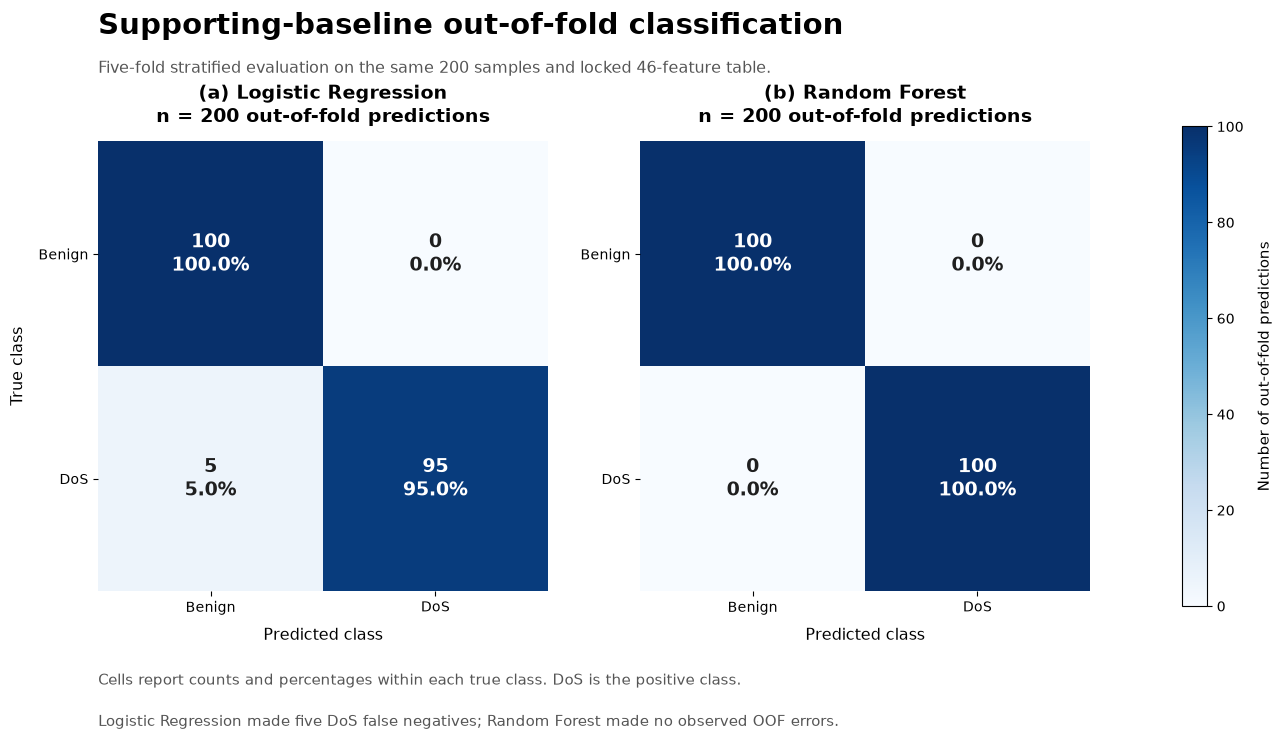

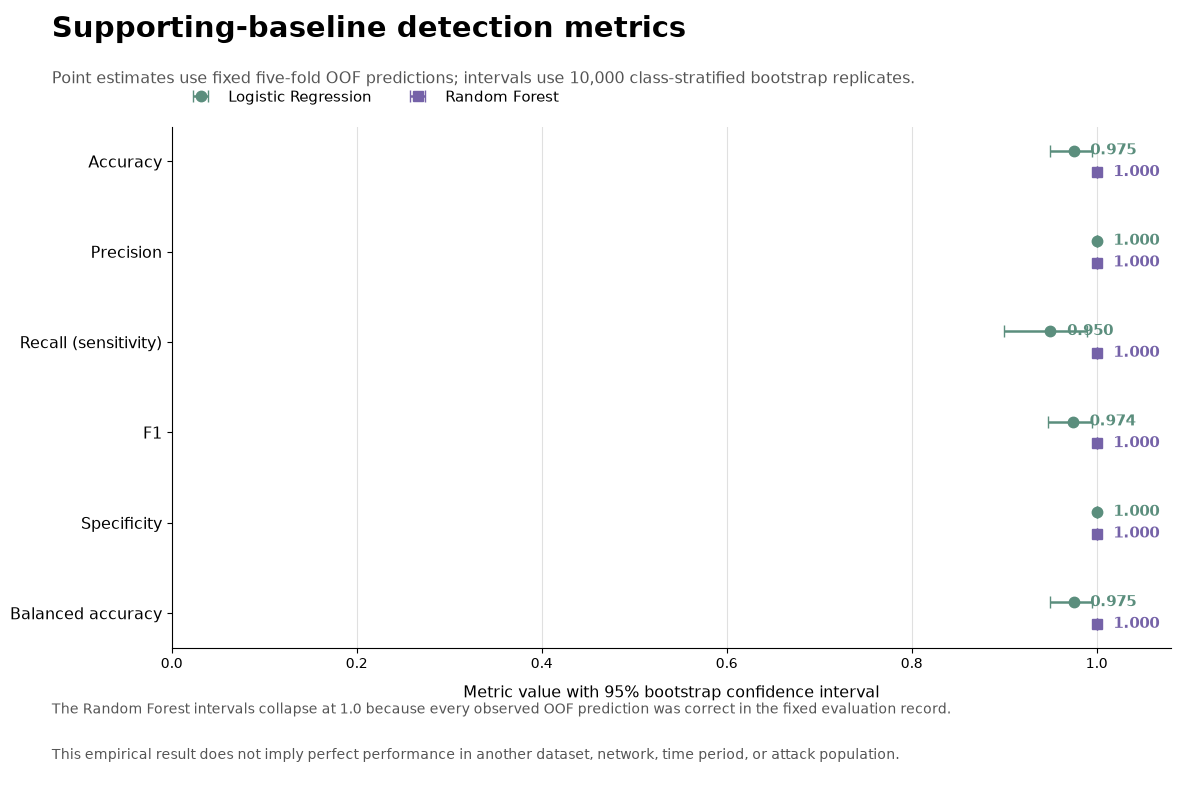

baseline_sample_count                                                                   200
bootstrap_method                          class-stratified nonparametric bootstrap of fi...
bootstrap_seed                                                                          742
bootstrap_replicate_count                                                             10000
confidence_level                                                                       0.95
exact_duplicate_audit_completed                                                        True
repeated_exact_predictor_group_count                                                      0
conflicting_label_exact_group_count                                                       0
cross_fold_exact_duplicate_group_count                                                    0
figure_06_png_path                        /Users/ruiwang/Developer/compsci742-rui-pilot/...
figure_06_png_sha256                      bc737786840ccb957720d3dbe3f42c82a91700

In [16]:
# Audit the unusually strong baseline results, calculate class-stratified
# bootstrap intervals, and create publication-quality baseline figures.

from pathlib import Path
import hashlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASELINE_BOOTSTRAP_REPLICATES = 10_000
BASELINE_BOOTSTRAP_SEED = 742

BASELINE_COLOURS = {
    "logistic_regression": "#5B8E7D",
    "random_forest": "#7562A8",
}

BASELINE_MODEL_ORDER = [
    "logistic_regression",
    "random_forest",
]


def notebook_file_sha256(path):
    """Return the SHA-256 digest of a generated figure."""
    digest = hashlib.sha256()

    with Path(path).open("rb") as file_handle:
        for chunk in iter(
            lambda: file_handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


# ---------------------------------------------------------------------------
# 1. Exact-predictor duplicate audit
# ---------------------------------------------------------------------------

baseline_duplicate_audit_table = (
    baseline_design_table.loc[
        :,
        [FEATURE_SAMPLE_ID_COLUMN, "true_binary"]
        + PRIMARY_FEATURE_NAMES,
    ]
    .copy()
)

baseline_duplicate_audit_table["cv_fold"] = (
    baseline_oof_prediction_table["cv_fold"]
    .astype(int)
    .to_numpy()
)

# Group samples that have exactly the same values across all 46 predictors.
exact_predictor_groups = (
    baseline_duplicate_audit_table
    .groupby(
        PRIMARY_FEATURE_NAMES,
        dropna=False,
        sort=False,
    )
    .agg(
        sample_count=(FEATURE_SAMPLE_ID_COLUMN, "size"),
        distinct_label_count=("true_binary", "nunique"),
        distinct_fold_count=("cv_fold", "nunique"),
        benign_count=(
            "true_binary",
            lambda values: int((values == 0).sum()),
        ),
        dos_count=(
            "true_binary",
            lambda values: int((values == 1).sum()),
        ),
        sample_ids=(
            FEATURE_SAMPLE_ID_COLUMN,
            lambda values: ", ".join(map(str, values)),
        ),
        folds=(
            "cv_fold",
            lambda values: ", ".join(
                map(str, sorted(set(values)))
            ),
        ),
    )
    .reset_index()
)

repeated_exact_predictor_groups = (
    exact_predictor_groups.loc[
        exact_predictor_groups["sample_count"].gt(1)
    ]
    .copy()
)

conflicting_label_groups = (
    repeated_exact_predictor_groups.loc[
        repeated_exact_predictor_groups[
            "distinct_label_count"
        ].gt(1)
    ]
    .copy()
)

cross_fold_duplicate_groups = (
    repeated_exact_predictor_groups.loc[
        repeated_exact_predictor_groups[
            "distinct_fold_count"
        ].gt(1)
    ]
    .copy()
)

baseline_duplicate_audit_summary = pd.Series(
    {
        "sample_count": int(
            len(baseline_duplicate_audit_table)
        ),
        "locked_predictor_count": int(
            len(PRIMARY_FEATURE_NAMES)
        ),
        "unique_exact_predictor_vector_count": int(
            len(exact_predictor_groups)
        ),
        "repeated_exact_predictor_group_count": int(
            len(repeated_exact_predictor_groups)
        ),
        "samples_in_repeated_exact_predictor_groups": int(
            repeated_exact_predictor_groups[
                "sample_count"
            ].sum()
        ),
        "conflicting_label_exact_group_count": int(
            len(conflicting_label_groups)
        ),
        "cross_fold_exact_duplicate_group_count": int(
            len(cross_fold_duplicate_groups)
        ),
        "sample_identifier_used_as_predictor": (
            FEATURE_SAMPLE_ID_COLUMN
            in PRIMARY_FEATURE_NAMES
        ),
        "ground_truth_used_as_predictor": (
            "true_binary" in PRIMARY_FEATURE_NAMES
        ),
        "duplicate_audit_completed": True,
    },
    name="value",
)

print("Exact 46-feature-vector duplicate audit:")
display(baseline_duplicate_audit_summary)

if len(repeated_exact_predictor_groups) > 0:
    print("Repeated exact predictor groups:")
    display(
        repeated_exact_predictor_groups.loc[
            :,
            [
                "sample_count",
                "distinct_label_count",
                "distinct_fold_count",
                "benign_count",
                "dos_count",
                "sample_ids",
                "folds",
            ],
        ]
    )
else:
    print(
        "No two samples have identical values across all "
        "46 locked predictors."
    )


# ---------------------------------------------------------------------------
# 2. Class-stratified bootstrap of fixed OOF predictions
# ---------------------------------------------------------------------------

baseline_bootstrap_random_generator = (
    np.random.default_rng(BASELINE_BOOTSTRAP_SEED)
)

benign_oof_indices = np.flatnonzero(
    baseline_target_vector == 0
)
dos_oof_indices = np.flatnonzero(
    baseline_target_vector == 1
)

assert len(benign_oof_indices) == 100
assert len(dos_oof_indices) == 100

baseline_bootstrap_metric_records = []

for bootstrap_replicate in range(
    BASELINE_BOOTSTRAP_REPLICATES
):
    sampled_benign_indices = (
        baseline_bootstrap_random_generator.choice(
            benign_oof_indices,
            size=len(benign_oof_indices),
            replace=True,
        )
    )

    sampled_dos_indices = (
        baseline_bootstrap_random_generator.choice(
            dos_oof_indices,
            size=len(dos_oof_indices),
            replace=True,
        )
    )

    sampled_indices = np.concatenate(
        [
            sampled_benign_indices,
            sampled_dos_indices,
        ]
    )

    sampled_true_values = (
        baseline_target_vector[sampled_indices]
    )

    for model_name in BASELINE_MODEL_ORDER:
        sampled_predicted_values = (
            baseline_oof_prediction_table[
                f"{model_name}_predicted_binary"
            ]
            .astype(int)
            .to_numpy()[sampled_indices]
        )

        sampled_metric_record, _ = (
            calculate_metrics_from_binary_predictions(
                sampled_true_values,
                sampled_predicted_values,
            )
        )

        for metric_name in METRIC_ORDER:
            baseline_bootstrap_metric_records.append(
                {
                    "bootstrap_replicate": (
                        bootstrap_replicate
                    ),
                    "model": model_name,
                    "metric": metric_name,
                    "metric_value": sampled_metric_record[
                        metric_name
                    ],
                }
            )

baseline_bootstrap_metric_distribution_table = (
    pd.DataFrame(baseline_bootstrap_metric_records)
)

baseline_point_metric_lookup = (
    baseline_point_metrics_table
    .set_index("model")
)

baseline_bootstrap_ci_records = []

for model_name in BASELINE_MODEL_ORDER:
    for metric_name in METRIC_ORDER:
        metric_distribution = (
            baseline_bootstrap_metric_distribution_table.loc[
                (
                    baseline_bootstrap_metric_distribution_table[
                        "model"
                    ].eq(model_name)
                )
                & (
                    baseline_bootstrap_metric_distribution_table[
                        "metric"
                    ].eq(metric_name)
                ),
                "metric_value",
            ]
            .dropna()
            .to_numpy()
        )

        lower_bound, upper_bound = np.quantile(
            metric_distribution,
            [0.025, 0.975],
        )

        point_estimate = float(
            baseline_point_metric_lookup.loc[
                model_name,
                metric_name,
            ]
        )

        baseline_bootstrap_ci_records.append(
            {
                "model": model_name,
                "model_display": (
                    baseline_model_display_names[model_name]
                ),
                "metric": metric_name,
                "metric_display": (
                    METRIC_DISPLAY_NAMES[metric_name]
                ),
                "estimate": point_estimate,
                "ci_lower": float(lower_bound),
                "ci_upper": float(upper_bound),
                "bootstrap_replicate_count": (
                    BASELINE_BOOTSTRAP_REPLICATES
                ),
            }
        )

baseline_bootstrap_metric_ci_table = pd.DataFrame(
    baseline_bootstrap_ci_records
)

baseline_bootstrap_metric_ci_table[
    "estimate_and_95_ci"
] = baseline_bootstrap_metric_ci_table.apply(
    lambda row: (
        f"{row['estimate']:.4f} "
        f"[{row['ci_lower']:.4f}, "
        f"{row['ci_upper']:.4f}]"
    ),
    axis=1,
)

baseline_bootstrap_ci_display = (
    baseline_bootstrap_metric_ci_table
    .pivot(
        index="metric_display",
        columns="model_display",
        values="estimate_and_95_ci",
    )
    .reindex(
        [
            METRIC_DISPLAY_NAMES[metric_name]
            for metric_name in METRIC_ORDER
        ]
    )
    .reset_index()
)

print(
    "Supporting-baseline OOF estimates and "
    "class-stratified bootstrap 95% intervals:"
)
display(baseline_bootstrap_ci_display)


# ---------------------------------------------------------------------------
# 3. Figure 6: baseline confusion matrices
# ---------------------------------------------------------------------------

FIGURE_06_PNG_PATH = (
    FIGURES_DIR
    / "figure_06_supporting_baseline_confusion_matrices.png"
)
FIGURE_06_PDF_PATH = (
    FIGURES_DIR
    / "figure_06_supporting_baseline_confusion_matrices.pdf"
)

figure_06 = plt.figure(
    figsize=(13.2, 8.2),
    constrained_layout=False,
)

figure_06_grid = figure_06.add_gridspec(
    nrows=3,
    ncols=3,
    height_ratios=[0.75, 4.6, 0.9],
    width_ratios=[1.0, 1.0, 0.055],
    left=0.08,
    right=0.92,
    top=0.96,
    bottom=0.07,
    wspace=0.30,
    hspace=0.18,
)

figure_06_title_axis = figure_06.add_subplot(
    figure_06_grid[0, :]
)
figure_06_title_axis.axis("off")

figure_06_title_axis.text(
    0.0,
    0.78,
    "Supporting-baseline out-of-fold classification",
    fontsize=21,
    fontweight="bold",
    ha="left",
    va="center",
)

figure_06_title_axis.text(
    0.0,
    0.24,
    (
        "Five-fold stratified evaluation on the same "
        "200 samples and locked 46-feature table."
    ),
    fontsize=11.5,
    color="#555555",
    ha="left",
    va="center",
)

figure_06_axes = [
    figure_06.add_subplot(figure_06_grid[1, 0]),
    figure_06.add_subplot(figure_06_grid[1, 1]),
]

figure_06_colourbar_axis = figure_06.add_subplot(
    figure_06_grid[1, 2]
)

figure_06_image = None

for panel_index, (
    model_name,
    panel_axis,
) in enumerate(
    zip(BASELINE_MODEL_ORDER, figure_06_axes)
):
    model_matrix = baseline_confusion_matrices[
        model_name
    ]

    figure_06_image = panel_axis.imshow(
        model_matrix,
        cmap="Blues",
        vmin=0,
        vmax=100,
        aspect="equal",
    )

    panel_axis.set_title(
        (
            f"({'ab'[panel_index]}) "
            f"{baseline_model_display_names[model_name]}\n"
            "n = 200 out-of-fold predictions"
        ),
        fontsize=14,
        fontweight="bold",
        pad=14,
    )

    panel_axis.set_xticks([0, 1])
    panel_axis.set_xticklabels(["Benign", "DoS"])
    panel_axis.set_yticks([0, 1])
    panel_axis.set_yticklabels(["Benign", "DoS"])

    panel_axis.set_xlabel(
        "Predicted class",
        fontsize=11.5,
        labelpad=9,
    )

    if panel_index == 0:
        panel_axis.set_ylabel(
            "True class",
            fontsize=11.5,
            labelpad=9,
        )

    for row_index in range(2):
        row_total = model_matrix[row_index, :].sum()

        for column_index in range(2):
            cell_count = int(
                model_matrix[row_index, column_index]
            )
            row_percentage = (
                100.0 * cell_count / row_total
            )

            annotation_colour = (
                "white"
                if cell_count >= 55
                else "#1F1F1F"
            )

            panel_axis.text(
                column_index,
                row_index,
                (
                    f"{cell_count}\n"
                    f"{row_percentage:.1f}%"
                ),
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color=annotation_colour,
            )

    for spine in panel_axis.spines.values():
        spine.set_visible(False)

figure_06_colourbar = figure_06.colorbar(
    figure_06_image,
    cax=figure_06_colourbar_axis,
)

figure_06_colourbar.set_label(
    "Number of out-of-fold predictions",
    fontsize=10.5,
    labelpad=10,
)

figure_06_footer_axis = figure_06.add_subplot(
    figure_06_grid[2, :]
)
figure_06_footer_axis.axis("off")

figure_06_footer_axis.text(
    0.0,
    0.62,
    (
        "Cells report counts and percentages within "
        "each true class. DoS is the positive class."
    ),
    fontsize=10.5,
    color="#555555",
    ha="left",
    va="center",
)

figure_06_footer_axis.text(
    0.0,
    0.18,
    (
        "Logistic Regression made five DoS false "
        "negatives; Random Forest made no observed "
        "OOF errors."
    ),
    fontsize=10.5,
    color="#555555",
    ha="left",
    va="center",
)

figure_06.savefig(
    FIGURE_06_PNG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
figure_06.savefig(
    FIGURE_06_PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(figure_06)


# ---------------------------------------------------------------------------
# 4. Figure 7: baseline metrics with bootstrap intervals
# ---------------------------------------------------------------------------

FIGURE_07_PNG_PATH = (
    FIGURES_DIR
    / "figure_07_supporting_baseline_metrics_with_ci.png"
)
FIGURE_07_PDF_PATH = (
    FIGURES_DIR
    / "figure_07_supporting_baseline_metrics_with_ci.pdf"
)

figure_07 = plt.figure(
    figsize=(13.5, 8.5),
    constrained_layout=False,
)

figure_07_grid = figure_07.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=[0.85, 5.0, 0.95],
    left=0.20,
    right=0.94,
    top=0.96,
    bottom=0.06,
    hspace=0.12,
)

figure_07_title_axis = figure_07.add_subplot(
    figure_07_grid[0, 0]
)
figure_07_title_axis.axis("off")

figure_07_title_axis.text(
    -0.12,
    0.78,
    "Supporting-baseline detection metrics",
    fontsize=21,
    fontweight="bold",
    ha="left",
    va="center",
    transform=figure_07_title_axis.transAxes,
)

figure_07_title_axis.text(
    -0.12,
    0.22,
    (
        "Point estimates use fixed five-fold OOF "
        "predictions; intervals use 10,000 "
        "class-stratified bootstrap replicates."
    ),
    fontsize=11.5,
    color="#555555",
    ha="left",
    va="center",
    transform=figure_07_title_axis.transAxes,
)

figure_07_axis = figure_07.add_subplot(
    figure_07_grid[1, 0]
)

metric_y_positions = np.arange(
    len(METRIC_ORDER)
)[::-1]

model_y_offsets = {
    "logistic_regression": 0.12,
    "random_forest": -0.12,
}

model_markers = {
    "logistic_regression": "o",
    "random_forest": "s",
}

for model_name in BASELINE_MODEL_ORDER:
    model_interval_table = (
        baseline_bootstrap_metric_ci_table.loc[
            baseline_bootstrap_metric_ci_table[
                "model"
            ].eq(model_name)
        ]
        .set_index("metric")
        .loc[METRIC_ORDER]
        .reset_index()
    )

    estimates = model_interval_table[
        "estimate"
    ].to_numpy()

    lower_errors = (
        estimates
        - model_interval_table["ci_lower"].to_numpy()
    )

    upper_errors = (
        model_interval_table["ci_upper"].to_numpy()
        - estimates
    )

    plotted_y_positions = (
        metric_y_positions
        + model_y_offsets[model_name]
    )

    figure_07_axis.errorbar(
        estimates,
        plotted_y_positions,
        xerr=np.vstack(
            [lower_errors, upper_errors]
        ),
        fmt=model_markers[model_name],
        markersize=7.5,
        linewidth=1.8,
        capsize=4,
        color=BASELINE_COLOURS[model_name],
        label=baseline_model_display_names[
            model_name
        ],
        zorder=3,
    )

    for estimate, y_position in zip(
        estimates,
        plotted_y_positions,
    ):
        figure_07_axis.text(
            min(estimate + 0.018, 1.025),
            y_position,
            f"{estimate:.3f}",
            fontsize=10.5,
            fontweight="bold",
            color=BASELINE_COLOURS[model_name],
            ha="left",
            va="center",
        )

figure_07_axis.set_yticks(metric_y_positions)
figure_07_axis.set_yticklabels(
    [
        METRIC_DISPLAY_NAMES[metric_name]
        for metric_name in METRIC_ORDER
    ],
    fontsize=11.5,
)

figure_07_axis.set_xlim(0.0, 1.08)
figure_07_axis.set_xlabel(
    "Metric value with 95% bootstrap confidence interval",
    fontsize=11.5,
    labelpad=10,
)

figure_07_axis.grid(
    axis="x",
    color="#D9D9D9",
    linewidth=0.8,
    alpha=0.8,
)
figure_07_axis.set_axisbelow(True)

figure_07_axis.spines["top"].set_visible(False)
figure_07_axis.spines["right"].set_visible(False)

figure_07_axis.legend(
    loc="lower left",
    bbox_to_anchor=(0.0, 1.015),
    ncol=2,
    frameon=False,
    fontsize=11,
)

figure_07_footer_axis = figure_07.add_subplot(
    figure_07_grid[2, 0]
)
figure_07_footer_axis.axis("off")

figure_07_footer_axis.text(
    -0.12,
    0.66,
    (
        "The Random Forest intervals collapse at 1.0 "
        "because every observed OOF prediction was "
        "correct in the fixed evaluation record."
    ),
    fontsize=10.3,
    color="#555555",
    ha="left",
    va="center",
    transform=figure_07_footer_axis.transAxes,
)

figure_07_footer_axis.text(
    -0.12,
    0.20,
    (
        "This empirical result does not imply perfect "
        "performance in another dataset, network, "
        "time period, or attack population."
    ),
    fontsize=10.3,
    color="#555555",
    ha="left",
    va="center",
    transform=figure_07_footer_axis.transAxes,
)

figure_07.savefig(
    FIGURE_07_PNG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
figure_07.savefig(
    FIGURE_07_PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(figure_07)


# ---------------------------------------------------------------------------
# 5. Reproducibility summary
# ---------------------------------------------------------------------------

baseline_uncertainty_and_figure_summary = pd.Series(
    {
        "baseline_sample_count": 200,
        "bootstrap_method": (
            "class-stratified nonparametric bootstrap "
            "of fixed OOF predictions"
        ),
        "bootstrap_seed": BASELINE_BOOTSTRAP_SEED,
        "bootstrap_replicate_count": (
            BASELINE_BOOTSTRAP_REPLICATES
        ),
        "confidence_level": 0.95,
        "exact_duplicate_audit_completed": True,
        "repeated_exact_predictor_group_count": int(
            len(repeated_exact_predictor_groups)
        ),
        "conflicting_label_exact_group_count": int(
            len(conflicting_label_groups)
        ),
        "cross_fold_exact_duplicate_group_count": int(
            len(cross_fold_duplicate_groups)
        ),
        "figure_06_png_path": str(
            FIGURE_06_PNG_PATH
        ),
        "figure_06_png_sha256": notebook_file_sha256(
            FIGURE_06_PNG_PATH
        ),
        "figure_06_pdf_path": str(
            FIGURE_06_PDF_PATH
        ),
        "figure_06_pdf_sha256": notebook_file_sha256(
            FIGURE_06_PDF_PATH
        ),
        "figure_07_png_path": str(
            FIGURE_07_PNG_PATH
        ),
        "figure_07_png_sha256": notebook_file_sha256(
            FIGURE_07_PNG_PATH
        ),
        "figure_07_pdf_path": str(
            FIGURE_07_PDF_PATH
        ),
        "figure_07_pdf_sha256": notebook_file_sha256(
            FIGURE_07_PDF_PATH
        ),
        "baseline_models_refitted_by_this_cell": False,
        "oof_predictions_modified_by_this_cell": False,
        "confidence_intervals_calculated": True,
        "evaluation_figures_written": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "supporting_baseline_uncertainty_and_visualisation"
        ),
    },
    name="value",
)

display(baseline_uncertainty_and_figure_summary)

### 12.1 Diagnostic gate for unusually high baseline performance

The supporting baselines achieved substantially higher out-of-fold performance
than the LLM conditions, including error-free Random Forest predictions in the
fixed five-fold evaluation.

Perfect performance within a small pilot dataset is treated as a result requiring
additional scrutiny rather than as evidence of perfect generalisation. The exact
duplicate audit found no repeated 46-feature vectors, no conflicting-label
duplicate groups, and no exact duplicates crossing folds. This rules out direct
replication of identical predictor rows across the training and test partitions.

The following diagnostic gate evaluates three additional explanations:

1. **Univariate separability:** whether a single predictor can classify the two
   classes with unusually high out-of-fold balanced accuracy.
2. **Partition stability:** whether strong performance persists across several
   independently shuffled stratified five-fold partitions.
3. **Shuffled-label negative control:** whether the same pipelines return to
   approximately chance-level performance after the labels are randomly
   permuted.

These checks do not constitute external validation. They help distinguish an
implementation or leakage warning from a genuinely easy within-dataset
classification problem.

In [17]:
# Diagnostic gate for the unusually high supporting-baseline accuracy.
#
# This cell performs:
# 1. policy-aware one-feature-at-a-time OOF screening;
# 2. repeated stratified five-fold stability checks;
# 3. shuffled-label negative controls.
#
# The original primary OOF predictions are not modified.

import warnings

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DIAGNOSTIC_REPEAT_SEEDS = [742, 743, 744]
DIAGNOSTIC_FOLD_COUNT = 5
DIAGNOSTIC_LABEL_SHUFFLE_SEED_OFFSET = 10_000


def make_compatible_one_hot_encoder():
    """Create a version-compatible unknown-safe one-hot encoder."""
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True,
        )


def oof_predictions_for_pipeline(
    pipeline_template,
    predictor_table,
    target_values,
    split_records,
):
    """Generate exactly one held-out prediction for every supplied row."""
    target_values = np.asarray(target_values, dtype=int)
    predictions = np.full(
        len(target_values),
        fill_value=-1,
        dtype=int,
    )
    prediction_assignment_count = np.zeros(
        len(target_values),
        dtype=int,
    )

    for training_indices, testing_indices in split_records:
        fold_pipeline = clone(pipeline_template)

        fold_pipeline.fit(
            predictor_table.iloc[training_indices],
            target_values[training_indices],
        )

        predictions[testing_indices] = (
            fold_pipeline
            .predict(
                predictor_table.iloc[testing_indices]
            )
            .astype(int)
        )

        prediction_assignment_count[testing_indices] += 1

    assert np.all(prediction_assignment_count == 1)
    assert np.isin(predictions, [0, 1]).all()

    return predictions


# ---------------------------------------------------------------------------
# 1. Policy-aware univariate out-of-fold screening
# ---------------------------------------------------------------------------

univariate_screening_records = []

# Use the original fixed primary folds so each feature is evaluated against the
# same held-out samples used in the primary baseline comparison.
for feature_name in PRIMARY_FEATURE_NAMES:
    if feature_name in CATEGORICAL_FEATURE_NAMES:
        feature_preprocessor = ColumnTransformer(
            transformers=[
                (
                    "categorical",
                    Pipeline(
                        steps=[
                            (
                                "mode_imputation",
                                SimpleImputer(
                                    strategy="most_frequent"
                                ),
                            ),
                            (
                                "one_hot_encoding",
                                make_compatible_one_hot_encoder(),
                            ),
                        ]
                    ),
                    [feature_name],
                )
            ],
            remainder="drop",
        )

        documented_treatment = "one_hot_encoded_categorical"

    else:
        feature_preprocessor = ColumnTransformer(
            transformers=[
                (
                    "quantitative",
                    Pipeline(
                        steps=[
                            (
                                "median_imputation",
                                SimpleImputer(
                                    strategy="median"
                                ),
                            ),
                            (
                                "standardisation",
                                StandardScaler(),
                            ),
                        ]
                    ),
                    [feature_name],
                )
            ],
            remainder="drop",
        )

        documented_treatment = "standardised_quantitative"

    univariate_pipeline = Pipeline(
        steps=[
            ("preprocessing", feature_preprocessor),
            (
                "classifier",
                LogisticRegression(
                    C=1.0,
                    solver="liblinear",
                    max_iter=5000,
                    random_state=BASELINE_RANDOM_SEED,
                ),
            ),
        ]
    )

    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore",
            category=FutureWarning,
        )

        univariate_predictions = (
            oof_predictions_for_pipeline(
                pipeline_template=univariate_pipeline,
                predictor_table=(
                    baseline_predictor_matrix.loc[
                        :,
                        [feature_name],
                    ]
                ),
                target_values=baseline_target_vector,
                split_records=BASELINE_CV_SPLITS,
            )
        )

    univariate_metrics, univariate_matrix = (
        calculate_metrics_from_binary_predictions(
            baseline_target_vector,
            univariate_predictions,
        )
    )

    feature_policy_row = (
        baseline_feature_treatment_table.loc[
            baseline_feature_treatment_table[
                "feature_name"
            ].eq(feature_name)
        ]
        .iloc[0]
    )

    univariate_screening_records.append(
        {
            "feature_name": feature_name,
            "feature_role": feature_policy_row[
                "feature_role"
            ],
            "documented_treatment": documented_treatment,
            "observed_unique_value_count": int(
                feature_policy_row[
                    "observed_unique_value_count"
                ]
            ),
            "accuracy": univariate_metrics["accuracy"],
            "balanced_accuracy": univariate_metrics[
                "balanced_accuracy"
            ],
            "recall": univariate_metrics["recall"],
            "specificity": univariate_metrics[
                "specificity"
            ],
            "true_negative": int(
                univariate_matrix[0, 0]
            ),
            "false_positive": int(
                univariate_matrix[0, 1]
            ),
            "false_negative": int(
                univariate_matrix[1, 0]
            ),
            "true_positive": int(
                univariate_matrix[1, 1]
            ),
        }
    )

univariate_oof_screening_table = (
    pd.DataFrame(univariate_screening_records)
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
            "feature_name",
        ],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

print(
    "Top 15 individual predictors by fixed-fold "
    "OOF balanced accuracy:"
)
display(
    univariate_oof_screening_table.head(15).round(4)
)


# ---------------------------------------------------------------------------
# 2. Repeated-fold stability and shuffled-label negative controls
# ---------------------------------------------------------------------------

diagnostic_repeated_cv_records = []

for repeat_number, repeat_seed in enumerate(
    DIAGNOSTIC_REPEAT_SEEDS,
    start=1,
):
    observed_cross_validator = StratifiedKFold(
        n_splits=DIAGNOSTIC_FOLD_COUNT,
        shuffle=True,
        random_state=repeat_seed,
    )

    observed_split_records = list(
        observed_cross_validator.split(
            baseline_predictor_matrix,
            baseline_target_vector,
        )
    )

    # Preserve the 100/100 class balance while destroying the association
    # between predictors and labels.
    shuffled_target_generator = np.random.default_rng(
        repeat_seed
        + DIAGNOSTIC_LABEL_SHUFFLE_SEED_OFFSET
    )

    shuffled_target_vector = (
        shuffled_target_generator.permutation(
            baseline_target_vector
        )
    )

    assert (
        shuffled_target_vector.sum()
        == baseline_target_vector.sum()
        == 100
    )

    shuffled_cross_validator = StratifiedKFold(
        n_splits=DIAGNOSTIC_FOLD_COUNT,
        shuffle=True,
        random_state=repeat_seed,
    )

    shuffled_split_records = list(
        shuffled_cross_validator.split(
            baseline_predictor_matrix,
            shuffled_target_vector,
        )
    )

    for model_name, model_template in (
        baseline_model_templates.items()
    ):
        for target_status, target_values, split_records in [
            (
                "observed_labels",
                baseline_target_vector,
                observed_split_records,
            ),
            (
                "shuffled_label_negative_control",
                shuffled_target_vector,
                shuffled_split_records,
            ),
        ]:
            with warnings.catch_warnings():
                warnings.simplefilter(
                    "ignore",
                    category=FutureWarning,
                )

                diagnostic_predictions = (
                    oof_predictions_for_pipeline(
                        pipeline_template=model_template,
                        predictor_table=(
                            baseline_predictor_matrix
                        ),
                        target_values=target_values,
                        split_records=split_records,
                    )
                )

            diagnostic_metrics, _ = (
                calculate_metrics_from_binary_predictions(
                    target_values,
                    diagnostic_predictions,
                )
            )

            diagnostic_repeated_cv_records.append(
                {
                    "repeat": repeat_number,
                    "split_seed": repeat_seed,
                    "model": model_name,
                    "model_display": (
                        baseline_model_display_names[
                            model_name
                        ]
                    ),
                    "target_status": target_status,
                    "accuracy": diagnostic_metrics[
                        "accuracy"
                    ],
                    "balanced_accuracy": (
                        diagnostic_metrics[
                            "balanced_accuracy"
                        ]
                    ),
                    "recall": diagnostic_metrics[
                        "recall"
                    ],
                    "specificity": diagnostic_metrics[
                        "specificity"
                    ],
                }
            )

baseline_diagnostic_repeated_cv_table = (
    pd.DataFrame(diagnostic_repeated_cv_records)
)

baseline_diagnostic_stability_summary = (
    baseline_diagnostic_repeated_cv_table
    .groupby(
        [
            "model_display",
            "target_status",
        ],
        as_index=False,
    )
    .agg(
        repeat_count=("repeat", "nunique"),
        mean_accuracy=("accuracy", "mean"),
        minimum_accuracy=("accuracy", "min"),
        maximum_accuracy=("accuracy", "max"),
        mean_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
        minimum_balanced_accuracy=(
            "balanced_accuracy",
            "min",
        ),
        maximum_balanced_accuracy=(
            "balanced_accuracy",
            "max",
        ),
        mean_recall=("recall", "mean"),
        mean_specificity=("specificity", "mean"),
    )
)

print(
    "Repeated-fold stability and shuffled-label "
    "negative-control summary:"
)
display(
    baseline_diagnostic_stability_summary.round(4)
)

print("Repeat-level diagnostic results:")
display(
    baseline_diagnostic_repeated_cv_table.round(4)
)


# ---------------------------------------------------------------------------
# 3. Diagnostic decision summary
# ---------------------------------------------------------------------------

top_univariate_balanced_accuracy = float(
    univariate_oof_screening_table.loc[
        0,
        "balanced_accuracy",
    ]
)

top_univariate_feature = (
    univariate_oof_screening_table.loc[
        0,
        "feature_name",
    ]
)

observed_stability_results = (
    baseline_diagnostic_repeated_cv_table.loc[
        baseline_diagnostic_repeated_cv_table[
            "target_status"
        ].eq("observed_labels")
    ]
)

negative_control_results = (
    baseline_diagnostic_repeated_cv_table.loc[
        baseline_diagnostic_repeated_cv_table[
            "target_status"
        ].eq(
            "shuffled_label_negative_control"
        )
    ]
)

baseline_high_accuracy_diagnostic_summary = pd.Series(
    {
        "exact_duplicate_predictor_group_count": int(
            len(repeated_exact_predictor_groups)
        ),
        "cross_fold_exact_duplicate_group_count": int(
            len(cross_fold_duplicate_groups)
        ),
        "top_single_feature": (
            top_univariate_feature
        ),
        "top_single_feature_oof_balanced_accuracy": (
            top_univariate_balanced_accuracy
        ),
        "diagnostic_repeat_count": int(
            len(DIAGNOSTIC_REPEAT_SEEDS)
        ),
        "observed_minimum_accuracy_across_models_and_repeats": float(
            observed_stability_results[
                "accuracy"
            ].min()
        ),
        "observed_maximum_accuracy_across_models_and_repeats": float(
            observed_stability_results[
                "accuracy"
            ].max()
        ),
        "negative_control_mean_accuracy": float(
            negative_control_results[
                "accuracy"
            ].mean()
        ),
        "negative_control_maximum_accuracy": float(
            negative_control_results[
                "accuracy"
            ].max()
        ),
        "negative_control_near_chance": bool(
            negative_control_results[
                "accuracy"
            ].mean() < 0.60
        ),
        "primary_oof_predictions_modified": False,
        "primary_baseline_metrics_modified": False,
        "evaluation_artifact_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_09_phase": (
            "high_baseline_accuracy_diagnostic_gate"
        ),
    },
    name="value",
)

display(baseline_high_accuracy_diagnostic_summary)

Top 15 individual predictors by fixed-fold OOF balanced accuracy:


,feature_name,feature_role,documented_treatment,observed_unique_value_count,accuracy,balanced_accuracy,recall,specificity,true_negative,false_positive,false_negative,true_positive
0,MIN_IP_PKT_LEN,quantitative_candidate,standardised_quantitative,6,1.000,1.000,1.00,1.00,100,0,0,100
1,SERVER_TCP_FLAGS,encoded_categorical_candidate,one_hot_encoded_categorical,8,0.915,0.915,1.00,0.83,83,17,0,100
2,L7_PROTO,encoded_categorical_candidate,one_hot_encoded_categorical,24,0.885,0.885,0.95,0.82,82,18,5,95
3,L4_DST_PORT,encoded_categorical_candidate,one_hot_encoded_categorical,82,0.850,0.850,0.75,0.95,95,5,25,75
4,MAX_TTL,quantitative_candidate,standardised_quantitative,6,0.850,0.850,0.70,1.00,100,0,30,70
5,MIN_TTL,quantitative_candidate,standardised_quantitative,3,0.850,0.850,0.70,1.00,100,0,30,70
6,TCP_FLAGS,encoded_categorical_candidate,one_hot_encoded_categorical,9,0.800,0.800,0.75,0.85,85,15,25,75
7,ICMP_TYPE,encoded_categorical_candidate,one_hot_encoded_categorical,82,0.775,0.775,0.92,0.63,63,37,8,92
8,DST_TO_SRC_AVG_THROUGHPUT,quantitative_candidate,standardised_quantitative,170,0.775,0.775,0.97,0.58,58,42,3,97
9,CLIENT_TCP_FLAGS,encoded_categorical_candidate,one_hot_encoded_categorical,9,0.770,0.770,0.75,0.79,79,21,25,75


Repeated-fold stability and shuffled-label negative-control summary:


,model_display,target_status,repeat_count,mean_accuracy,minimum_accuracy,maximum_accuracy,mean_balanced_accuracy,minimum_balanced_accuracy,maximum_balanced_accuracy,mean_recall,mean_specificity
0,Logistic Regression,observed_labels,3,0.9867,0.975,0.995,0.9867,0.975,0.995,0.9733,1.0000
1,Logistic Regression,shuffled_label_negative_control,3,0.4967,0.455,0.525,0.4967,0.455,0.525,0.5133,0.4800
2,Random Forest,observed_labels,3,1.0000,1.000,1.000,1.0000,1.000,1.000,1.0000,1.0000
3,Random Forest,shuffled_label_negative_control,3,0.4883,0.450,0.515,0.4883,0.450,0.515,0.4933,0.4833


Repeat-level diagnostic results:


,repeat,split_seed,model,model_display,target_status,accuracy,balanced_accuracy,recall,specificity
0,1,742,logistic_regression,Logistic Regression,observed_labels,0.975,0.975,0.95,1.00
1,1,742,logistic_regression,Logistic Regression,shuffled_label_negative_control,0.510,0.510,0.49,0.53
2,1,742,random_forest,Random Forest,observed_labels,1.000,1.000,1.00,1.00
3,1,742,random_forest,Random Forest,shuffled_label_negative_control,0.500,0.500,0.44,0.56
4,2,743,logistic_regression,Logistic Regression,observed_labels,0.990,0.990,0.98,1.00
5,2,743,logistic_regression,Logistic Regression,shuffled_label_negative_control,0.455,0.455,0.51,0.40
6,2,743,random_forest,Random Forest,observed_labels,1.000,1.000,1.00,1.00
7,2,743,random_forest,Random Forest,shuffled_label_negative_control,0.450,0.450,0.47,0.43
8,3,744,logistic_regression,Logistic Regression,observed_labels,0.995,0.995,0.99,1.00
9,3,744,logistic_regression,Logistic Regression,shuffled_label_negative_control,0.525,0.525,0.54,0.51


exact_duplicate_predictor_group_count                                                       0
cross_fold_exact_duplicate_group_count                                                      0
top_single_feature                                                             MIN_IP_PKT_LEN
top_single_feature_oof_balanced_accuracy                                                  1.0
diagnostic_repeat_count                                                                     3
observed_minimum_accuracy_across_models_and_repeats                                     0.975
observed_maximum_accuracy_across_models_and_repeats                                       1.0
negative_control_mean_accuracy                                                         0.4925
negative_control_maximum_accuracy                                                       0.525
negative_control_near_chance                                                             True
primary_oof_predictions_modified                            

### 12.2 Dominant-predictor and post-hoc ablation diagnostic

The diagnostic gate did not identify evidence of direct implementation leakage.
Shuffled-label performance returned to approximately chance level, and the high
observed-label performance remained stable across three independently shuffled
five-fold partitions.

However, the univariate audit identified `MIN_IP_PKT_LEN` as a dominant predictor.
Using this feature alone, a policy-compliant univariate Logistic Regression model
achieved an out-of-fold balanced accuracy of 1.0. Thus, the near-perfect
multivariable baseline results do not require a complex 46-feature decision rule:
this pilot sample contains a particularly strong class boundary associated with
minimum IP-packet length.

`MIN_IP_PKT_LEN` remains part of the locked primary-46 analysis because it is a
legitimate network-flow measurement, was selected before loading the private
labels, and was supplied identically to both LLM conditions. Removing it after
observing its association with the labels would alter the preregistered feature
contract.

A post-hoc diagnostic ablation is nevertheless reported to assess whether baseline
performance depends entirely on this one predictor. The ablation removes
`MIN_IP_PKT_LEN`, repeats the original fixed five-fold OOF evaluation with the
remaining 45 predictors, and does not replace or modify the primary baseline
results.

This analysis addresses internal diagnostic credibility only. Strong performance
after ablation would indicate that the pilot dataset contains additional
distributed class signal; it would not establish generalisation to other networks,
capture periods, DoS mechanisms, or naturally occurring class prevalence.

MIN_IP_PKT_LEN distribution by true class:


,true_label,sample_count,minimum_value,first_quartile,median_value,third_quartile,maximum_value,unique_value_count
0,Benign,100,52,52.0,52.0,52.0,73,3
1,DoS,100,0,40.0,40.0,40.0,45,3


Exact MIN_IP_PKT_LEN value counts by true class:


,MIN_IP_PKT_LEN,true_label,sample_count
0,0,DoS,21
1,40,DoS,78
2,45,DoS,1
3,52,Benign,93
4,65,Benign,4
5,73,Benign,3


Post-hoc 45-feature ablation point estimates:


,model_display,feature_count,true_negative,false_positive,false_negative,true_positive,accuracy,precision,recall,f1,specificity,balanced_accuracy
0,Logistic Regression,45,100,0,6,94,0.97,1.0,0.94,0.9691,1.0,0.97
1,Random Forest,45,100,0,0,100,1.00,1.0,1.00,1.0000,1.0,1.00


Primary-46 versus post-hoc 45-feature comparison:


primary_46_estimate                \
model_display        Logistic Regression Random Forest   
metric_display                                           
Accuracy                          0.9750           1.0   
Balanced accuracy                 0.9750           1.0   
F1                                0.9744           1.0   
Precision                         1.0000           1.0   
Recall (sensitivity)              0.9500           1.0   
Specificity                       1.0000           1.0   

                     without_dominant_feature_estimate                \
model_display                      Logistic Regression Random Forest   
metric_display                                                         
Accuracy                                        0.9700           1.0   
Balanced accuracy                               0.9700           1.0   
F1                                              0.9691           1.0   
Precision                                       1.0000           1.0   
Recall (sensitivity)                            0.9400           1.0   
Specificity                                     1.0000           1.0   

                     ablation_difference                
model_display        Logistic Regression Random Forest  
metric_display                                          
Accuracy                         -0.0050           0.0  
Balanced accuracy                -0.0050           0.0  
F1                               -0.0053           0.0  
Precision                         0.0000           0.0  
Recall (sensitivity)             -0.0100           0.0  
Specificity                       0.0000           0.0

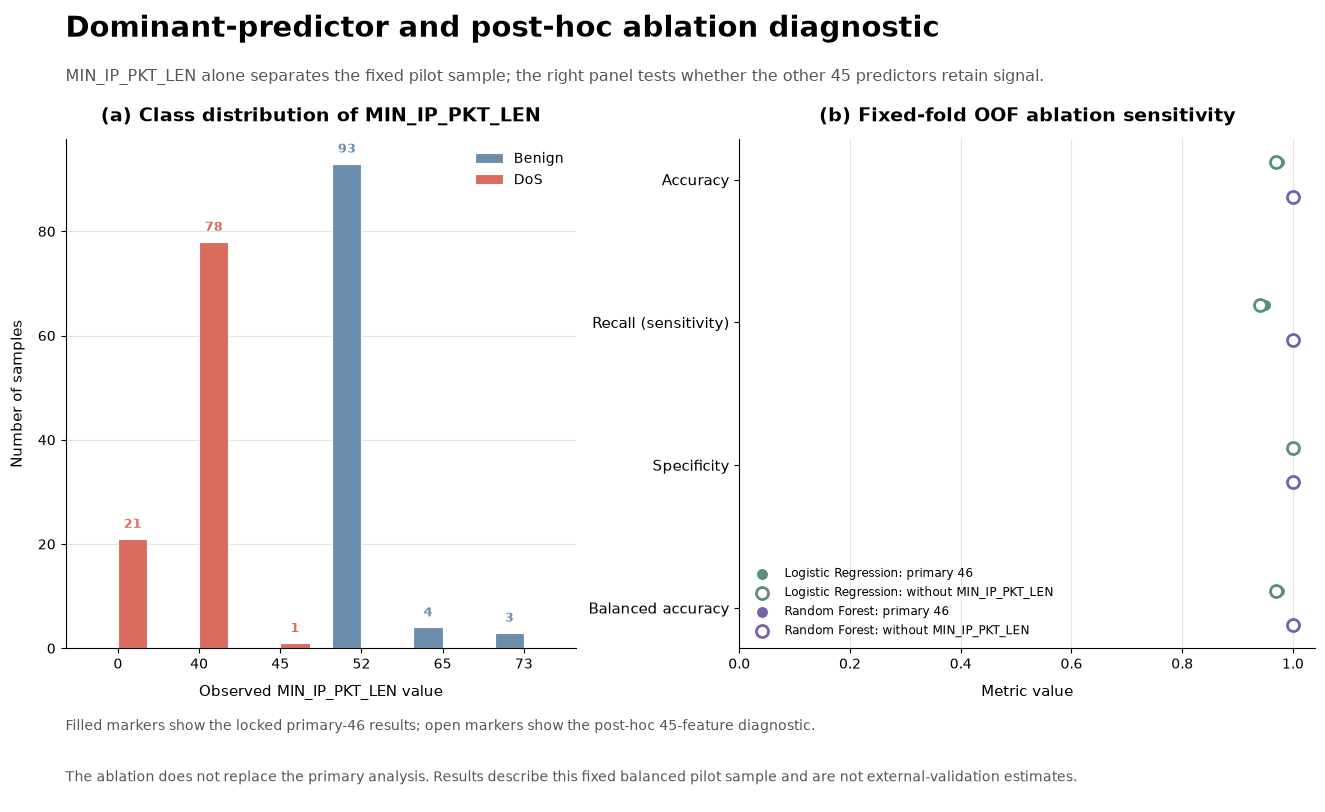

dominant_predictor                                                                        MIN_IP_PKT_LEN
dominant_predictor_unique_value_count                                                                  6
dominant_predictor_univariate_oof_balanced_accuracy                                                  1.0
primary_feature_count                                                                                 46
post_hoc_ablation_feature_count                                                                       45
removed_feature                                                                           MIN_IP_PKT_LEN
removal_was_preregistered                                                                          False
ablation_is_post_hoc_diagnostic                                                                     True
primary_feature_contract_modified                                                                  False
primary_oof_predictions_modified                       

In [18]:
# Examine the dominant MIN_IP_PKT_LEN class boundary and perform a transparent
# post-hoc 45-feature ablation using the original fixed CV splits.
#
# The locked primary-46 results remain unchanged.

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DOMINANT_PREDICTOR_NAME = "MIN_IP_PKT_LEN"
ABLATION_RANDOM_SEED = 742

assert DOMINANT_PREDICTOR_NAME in PRIMARY_FEATURE_NAMES
assert DOMINANT_PREDICTOR_NAME in QUANTITATIVE_FEATURE_NAMES
assert DOMINANT_PREDICTOR_NAME not in CATEGORICAL_FEATURE_NAMES


def make_ablation_one_hot_encoder():
    """Create a version-compatible encoder for the ablation pipelines."""
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True,
        )


# ---------------------------------------------------------------------------
# 1. Inspect the exact dominant-feature class distribution
# ---------------------------------------------------------------------------

dominant_predictor_distribution_table = (
    baseline_design_table
    .groupby(
        [
            DOMINANT_PREDICTOR_NAME,
            "true_binary",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "sample_count"})
)

dominant_predictor_distribution_table[
    "true_label"
] = dominant_predictor_distribution_table[
    "true_binary"
].map(
    {
        0: "Benign",
        1: "DoS",
    }
)

dominant_predictor_class_summary = (
    baseline_design_table
    .groupby("true_binary", as_index=False)
    .agg(
        sample_count=(
            DOMINANT_PREDICTOR_NAME,
            "size",
        ),
        minimum_value=(
            DOMINANT_PREDICTOR_NAME,
            "min",
        ),
        first_quartile=(
            DOMINANT_PREDICTOR_NAME,
            lambda values: values.quantile(0.25),
        ),
        median_value=(
            DOMINANT_PREDICTOR_NAME,
            "median",
        ),
        third_quartile=(
            DOMINANT_PREDICTOR_NAME,
            lambda values: values.quantile(0.75),
        ),
        maximum_value=(
            DOMINANT_PREDICTOR_NAME,
            "max",
        ),
        unique_value_count=(
            DOMINANT_PREDICTOR_NAME,
            "nunique",
        ),
    )
)

dominant_predictor_class_summary[
    "true_label"
] = dominant_predictor_class_summary[
    "true_binary"
].map(
    {
        0: "Benign",
        1: "DoS",
    }
)

dominant_predictor_class_summary = (
    dominant_predictor_class_summary.loc[
        :,
        [
            "true_label",
            "sample_count",
            "minimum_value",
            "first_quartile",
            "median_value",
            "third_quartile",
            "maximum_value",
            "unique_value_count",
        ],
    ]
)

print(
    "MIN_IP_PKT_LEN distribution by true class:"
)
display(dominant_predictor_class_summary)

print(
    "Exact MIN_IP_PKT_LEN value counts by true class:"
)
display(
    dominant_predictor_distribution_table.loc[
        :,
        [
            DOMINANT_PREDICTOR_NAME,
            "true_label",
            "sample_count",
        ],
    ].sort_values(
        [
            DOMINANT_PREDICTOR_NAME,
            "true_label",
        ]
    )
)


# ---------------------------------------------------------------------------
# 2. Construct the transparent 45-feature ablation pipelines
# ---------------------------------------------------------------------------

ABLATION_FEATURE_NAMES = [
    feature_name
    for feature_name in PRIMARY_FEATURE_NAMES
    if feature_name != DOMINANT_PREDICTOR_NAME
]

ABLATION_QUANTITATIVE_FEATURE_NAMES = [
    feature_name
    for feature_name in QUANTITATIVE_FEATURE_NAMES
    if feature_name != DOMINANT_PREDICTOR_NAME
]

ABLATION_CATEGORICAL_FEATURE_NAMES = list(
    CATEGORICAL_FEATURE_NAMES
)

assert len(ABLATION_FEATURE_NAMES) == 45
assert len(ABLATION_QUANTITATIVE_FEATURE_NAMES) == 34
assert len(ABLATION_CATEGORICAL_FEATURE_NAMES) == 11
assert (
    set(ABLATION_QUANTITATIVE_FEATURE_NAMES)
    | set(ABLATION_CATEGORICAL_FEATURE_NAMES)
) == set(ABLATION_FEATURE_NAMES)

ablation_logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "quantitative",
            Pipeline(
                steps=[
                    (
                        "median_imputation",
                        SimpleImputer(strategy="median"),
                    ),
                    (
                        "standardisation",
                        StandardScaler(),
                    ),
                ]
            ),
            ABLATION_QUANTITATIVE_FEATURE_NAMES,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "mode_imputation",
                        SimpleImputer(
                            strategy="most_frequent"
                        ),
                    ),
                    (
                        "one_hot_encoding",
                        make_ablation_one_hot_encoder(),
                    ),
                ]
            ),
            ABLATION_CATEGORICAL_FEATURE_NAMES,
        ),
    ],
    remainder="drop",
)

ablation_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            ablation_logistic_preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                C=1.0,
                solver="liblinear",
                max_iter=5000,
                random_state=ABLATION_RANDOM_SEED,
            ),
        ),
    ]
)

ablation_random_forest_preprocessor = ColumnTransformer(
    transformers=[
        (
            "quantitative",
            Pipeline(
                steps=[
                    (
                        "median_imputation",
                        SimpleImputer(strategy="median"),
                    ),
                ]
            ),
            ABLATION_QUANTITATIVE_FEATURE_NAMES,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "mode_imputation",
                        SimpleImputer(
                            strategy="most_frequent"
                        ),
                    ),
                    (
                        "one_hot_encoding",
                        make_ablation_one_hot_encoder(),
                    ),
                ]
            ),
            ABLATION_CATEGORICAL_FEATURE_NAMES,
        ),
    ],
    remainder="drop",
)

ablation_random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            ablation_random_forest_preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=1000,
                criterion="gini",
                max_features="sqrt",
                class_weight=None,
                random_state=ABLATION_RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

ablation_model_templates = {
    "logistic_regression": (
        ablation_logistic_pipeline
    ),
    "random_forest": (
        ablation_random_forest_pipeline
    ),
}

ablation_predictor_matrix = (
    baseline_design_table.loc[
        :,
        ABLATION_FEATURE_NAMES,
    ]
    .copy()
)

ablation_oof_prediction_table = (
    baseline_design_table.loc[
        :,
        [FEATURE_SAMPLE_ID_COLUMN, "true_binary"],
    ]
    .copy()
)

ablation_metric_records = []
ablation_confusion_matrices = {}

for model_name, model_template in (
    ablation_model_templates.items()
):
    ablation_predictions = (
        oof_predictions_for_pipeline(
            pipeline_template=model_template,
            predictor_table=ablation_predictor_matrix,
            target_values=baseline_target_vector,
            split_records=BASELINE_CV_SPLITS,
        )
    )

    ablation_oof_prediction_table[
        f"{model_name}_predicted_binary"
    ] = ablation_predictions

    ablation_metrics, ablation_matrix = (
        calculate_metrics_from_binary_predictions(
            baseline_target_vector,
            ablation_predictions,
        )
    )

    ablation_confusion_matrices[model_name] = (
        ablation_matrix
    )

    ablation_metric_records.append(
        {
            "model": model_name,
            "model_display": (
                baseline_model_display_names[model_name]
            ),
            "analysis": (
                "post_hoc_without_MIN_IP_PKT_LEN"
            ),
            "feature_count": 45,
            **ablation_metrics,
        }
    )

ablation_point_metrics_table = pd.DataFrame(
    ablation_metric_records
)

primary_vs_ablation_metric_records = []

for model_name in BASELINE_MODEL_ORDER:
    primary_row = (
        baseline_point_metrics_table.loc[
            baseline_point_metrics_table[
                "model"
            ].eq(model_name)
        ]
        .iloc[0]
    )

    ablation_row = (
        ablation_point_metrics_table.loc[
            ablation_point_metrics_table[
                "model"
            ].eq(model_name)
        ]
        .iloc[0]
    )

    for metric_name in METRIC_ORDER:
        primary_vs_ablation_metric_records.append(
            {
                "model": model_name,
                "model_display": (
                    baseline_model_display_names[
                        model_name
                    ]
                ),
                "metric": metric_name,
                "metric_display": (
                    METRIC_DISPLAY_NAMES[
                        metric_name
                    ]
                ),
                "primary_46_estimate": float(
                    primary_row[metric_name]
                ),
                "without_dominant_feature_estimate": float(
                    ablation_row[metric_name]
                ),
                "ablation_difference": float(
                    ablation_row[metric_name]
                    - primary_row[metric_name]
                ),
            }
        )

primary_vs_ablation_metric_table = pd.DataFrame(
    primary_vs_ablation_metric_records
)

print(
    "Post-hoc 45-feature ablation point estimates:"
)
display(
    ablation_point_metrics_table.loc[
        :,
        [
            "model_display",
            "feature_count",
            "true_negative",
            "false_positive",
            "false_negative",
            "true_positive",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
        ],
    ].round(4)
)

print(
    "Primary-46 versus post-hoc 45-feature comparison:"
)
display(
    primary_vs_ablation_metric_table.pivot(
        index="metric_display",
        columns="model_display",
        values=[
            "primary_46_estimate",
            "without_dominant_feature_estimate",
            "ablation_difference",
        ],
    ).round(4)
)


# ---------------------------------------------------------------------------
# 3. Figure 8: dominant-feature distribution and ablation sensitivity
# ---------------------------------------------------------------------------

FIGURE_08_PNG_PATH = (
    FIGURES_DIR
    / "figure_08_dominant_predictor_ablation_diagnostic.png"
)
FIGURE_08_PDF_PATH = (
    FIGURES_DIR
    / "figure_08_dominant_predictor_ablation_diagnostic.pdf"
)

figure_08 = plt.figure(
    figsize=(14.2, 8.8),
    constrained_layout=False,
)

figure_08_grid = figure_08.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[0.82, 4.8, 1.05],
    width_ratios=[1.02, 1.15],
    left=0.08,
    right=0.96,
    top=0.96,
    bottom=0.06,
    wspace=0.30,
    hspace=0.18,
)

figure_08_title_axis = figure_08.add_subplot(
    figure_08_grid[0, :]
)
figure_08_title_axis.axis("off")

figure_08_title_axis.text(
    0.0,
    0.78,
    "Dominant-predictor and post-hoc ablation diagnostic",
    fontsize=21,
    fontweight="bold",
    ha="left",
    va="center",
)

figure_08_title_axis.text(
    0.0,
    0.23,
    (
        "MIN_IP_PKT_LEN alone separates the fixed pilot "
        "sample; the right panel tests whether the other "
        "45 predictors retain signal."
    ),
    fontsize=11.5,
    color="#555555",
    ha="left",
    va="center",
)

distribution_axis = figure_08.add_subplot(
    figure_08_grid[1, 0]
)
ablation_axis = figure_08.add_subplot(
    figure_08_grid[1, 1]
)

# Panel A: exact value counts, shown on a categorical x-axis so all six
# observed values receive equal visual space.
dominant_values = sorted(
    baseline_design_table[
        DOMINANT_PREDICTOR_NAME
    ].unique()
)

dominant_value_positions = np.arange(
    len(dominant_values)
)

bar_width = 0.36

for class_offset, (
    true_binary,
    true_label,
    colour,
) in enumerate(
    [
        (0, "Benign", "#6C8EAD"),
        (1, "DoS", "#D96C5F"),
    ]
):
    class_counts = (
        dominant_predictor_distribution_table.loc[
            dominant_predictor_distribution_table[
                "true_binary"
            ].eq(true_binary)
        ]
        .set_index(DOMINANT_PREDICTOR_NAME)[
            "sample_count"
        ]
        .reindex(
            dominant_values,
            fill_value=0,
        )
        .to_numpy()
    )

    horizontal_offset = (
        -bar_width / 2
        if class_offset == 0
        else bar_width / 2
    )

    distribution_axis.bar(
        dominant_value_positions
        + horizontal_offset,
        class_counts,
        width=bar_width,
        color=colour,
        label=true_label,
        edgecolor="white",
        linewidth=0.8,
    )

    for x_position, count in zip(
        dominant_value_positions
        + horizontal_offset,
        class_counts,
    ):
        if count > 0:
            distribution_axis.text(
                x_position,
                count + 1.5,
                str(int(count)),
                ha="center",
                va="bottom",
                fontsize=9.5,
                fontweight="bold",
                color=colour,
            )

distribution_axis.set_title(
    "(a) Class distribution of MIN_IP_PKT_LEN",
    fontsize=13.5,
    fontweight="bold",
    pad=13,
)

distribution_axis.set_xticks(
    dominant_value_positions
)
distribution_axis.set_xticklabels(
    [str(value) for value in dominant_values]
)
distribution_axis.set_xlabel(
    "Observed MIN_IP_PKT_LEN value",
    fontsize=11,
    labelpad=9,
)
distribution_axis.set_ylabel(
    "Number of samples",
    fontsize=11,
    labelpad=9,
)
distribution_axis.legend(
    frameon=False,
    loc="upper right",
)
distribution_axis.grid(
    axis="y",
    color="#DDDDDD",
    linewidth=0.8,
    alpha=0.8,
)
distribution_axis.set_axisbelow(True)
distribution_axis.spines["top"].set_visible(False)
distribution_axis.spines["right"].set_visible(False)

# Panel B: show the most interpretable operating metrics.
ablation_figure_metrics = [
    "accuracy",
    "recall",
    "specificity",
    "balanced_accuracy",
]

ablation_metric_positions = np.arange(
    len(ablation_figure_metrics)
)[::-1]

model_offsets = {
    "logistic_regression": 0.12,
    "random_forest": -0.12,
}

for model_name in BASELINE_MODEL_ORDER:
    model_comparison = (
        primary_vs_ablation_metric_table.loc[
            (
                primary_vs_ablation_metric_table[
                    "model"
                ].eq(model_name)
            )
            & (
                primary_vs_ablation_metric_table[
                    "metric"
                ].isin(ablation_figure_metrics)
            )
        ]
        .set_index("metric")
        .loc[ablation_figure_metrics]
    )

    y_positions = (
        ablation_metric_positions
        + model_offsets[model_name]
    )

    primary_values = model_comparison[
        "primary_46_estimate"
    ].to_numpy()

    ablated_values = model_comparison[
        "without_dominant_feature_estimate"
    ].to_numpy()

    for y_position, primary_value, ablated_value in zip(
        y_positions,
        primary_values,
        ablated_values,
    ):
        ablation_axis.plot(
            [ablated_value, primary_value],
            [y_position, y_position],
            color=BASELINE_COLOURS[model_name],
            linewidth=2.0,
            alpha=0.72,
            zorder=1,
        )

    ablation_axis.scatter(
        primary_values,
        y_positions,
        s=75,
        marker="o",
        color=BASELINE_COLOURS[model_name],
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
        label=(
            f"{baseline_model_display_names[model_name]}: "
            "primary 46"
        ),
    )

    ablation_axis.scatter(
        ablated_values,
        y_positions,
        s=75,
        marker="o",
        facecolor="white",
        edgecolor=BASELINE_COLOURS[model_name],
        linewidth=2.0,
        zorder=3,
        label=(
            f"{baseline_model_display_names[model_name]}: "
            "without MIN_IP_PKT_LEN"
        ),
    )

ablation_axis.set_title(
    "(b) Fixed-fold OOF ablation sensitivity",
    fontsize=13.5,
    fontweight="bold",
    pad=13,
)

ablation_axis.set_yticks(
    ablation_metric_positions
)
ablation_axis.set_yticklabels(
    [
        METRIC_DISPLAY_NAMES[metric_name]
        for metric_name in ablation_figure_metrics
    ],
    fontsize=10.5,
)

ablation_axis.set_xlim(0.0, 1.04)
ablation_axis.set_xlabel(
    "Metric value",
    fontsize=11,
    labelpad=9,
)
ablation_axis.grid(
    axis="x",
    color="#DDDDDD",
    linewidth=0.8,
    alpha=0.8,
)
ablation_axis.set_axisbelow(True)
ablation_axis.spines["top"].set_visible(False)
ablation_axis.spines["right"].set_visible(False)

ablation_axis.legend(
    frameon=False,
    fontsize=8.8,
    loc="lower left",
)

figure_08_footer_axis = figure_08.add_subplot(
    figure_08_grid[2, :]
)
figure_08_footer_axis.axis("off")

figure_08_footer_axis.text(
    0.0,
    0.68,
    (
        "Filled markers show the locked primary-46 "
        "results; open markers show the post-hoc "
        "45-feature diagnostic."
    ),
    fontsize=10.3,
    color="#555555",
    ha="left",
    va="center",
)

figure_08_footer_axis.text(
    0.0,
    0.22,
    (
        "The ablation does not replace the primary "
        "analysis. Results describe this fixed balanced "
        "pilot sample and are not external-validation "
        "estimates."
    ),
    fontsize=10.3,
    color="#555555",
    ha="left",
    va="center",
)

figure_08.savefig(
    FIGURE_08_PNG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
figure_08.savefig(
    FIGURE_08_PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(figure_08)


# ---------------------------------------------------------------------------
# 4. Reproducibility and interpretation audit
# ---------------------------------------------------------------------------

dominant_predictor_ablation_summary = pd.Series(
    {
        "dominant_predictor": (
            DOMINANT_PREDICTOR_NAME
        ),
        "dominant_predictor_unique_value_count": int(
            baseline_design_table[
                DOMINANT_PREDICTOR_NAME
            ].nunique()
        ),
        "dominant_predictor_univariate_oof_balanced_accuracy": float(
            univariate_oof_screening_table.loc[
                univariate_oof_screening_table[
                    "feature_name"
                ].eq(DOMINANT_PREDICTOR_NAME),
                "balanced_accuracy",
            ].iloc[0]
        ),
        "primary_feature_count": 46,
        "post_hoc_ablation_feature_count": 45,
        "removed_feature": (
            DOMINANT_PREDICTOR_NAME
        ),
        "removal_was_preregistered": False,
        "ablation_is_post_hoc_diagnostic": True,
        "primary_feature_contract_modified": False,
        "primary_oof_predictions_modified": False,
        "primary_baseline_metrics_modified": False,
        "figure_08_png_path": str(
            FIGURE_08_PNG_PATH
        ),
        "figure_08_png_sha256": (
            notebook_file_sha256(
                FIGURE_08_PNG_PATH
            )
        ),
        "figure_08_pdf_path": str(
            FIGURE_08_PDF_PATH
        ),
        "figure_08_pdf_sha256": (
            notebook_file_sha256(
                FIGURE_08_PDF_PATH
            )
        ),
        "evaluation_figure_written": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "dominant_predictor_post_hoc_ablation"
        ),
    },
    name="value",
)

display(dominant_predictor_ablation_summary)

### 12.3 Refined baseline visualisation and threshold-free discrimination

The post-hoc ablation demonstrates that the high baseline performance does not
depend entirely on `MIN_IP_PKT_LEN`. Removing the dominant predictor reduced
Logistic Regression accuracy by only 0.5 percentage points and recall by one
percentage point. Random Forest retained error-free OOF classification.

The baseline metric figure is refined using an explicitly labelled zoomed axis
because all estimates lie near the upper boundary. The ablation panel is replaced
with a direct change plot so that unchanged and slightly reduced metrics remain
visually distinguishable.

ROC and precision–recall curves are also reported from the fixed OOF probability
predictions. These threshold-free summaries evaluate ranking discrimination, not
probability calibration, and remain internal estimates for the fixed balanced
pilot sample.

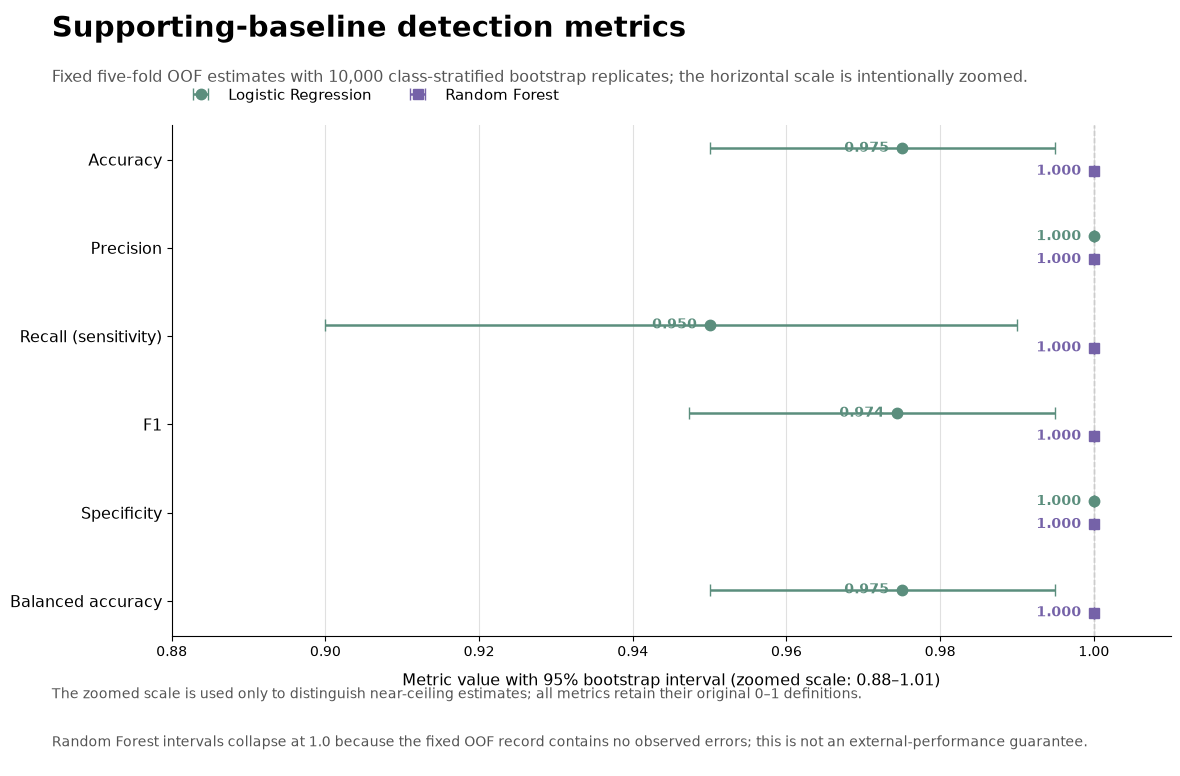

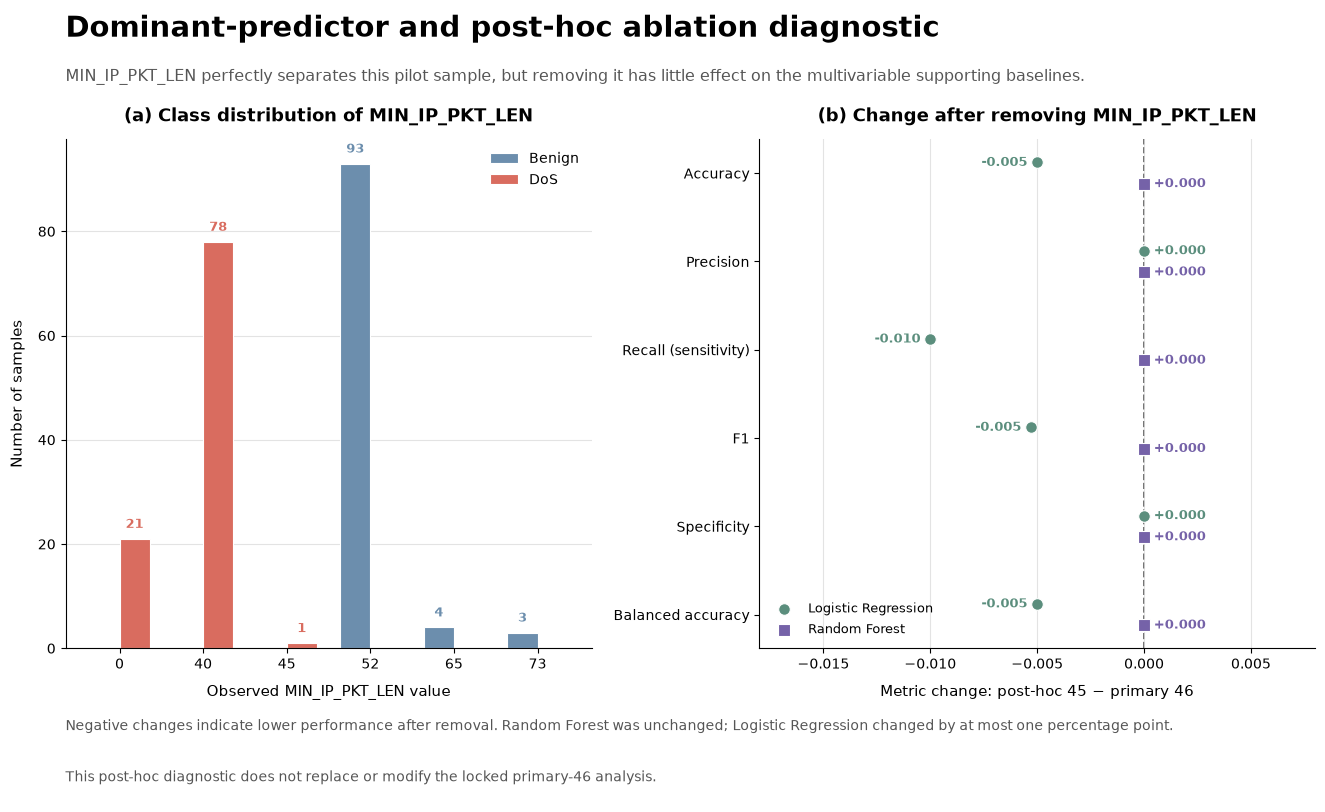

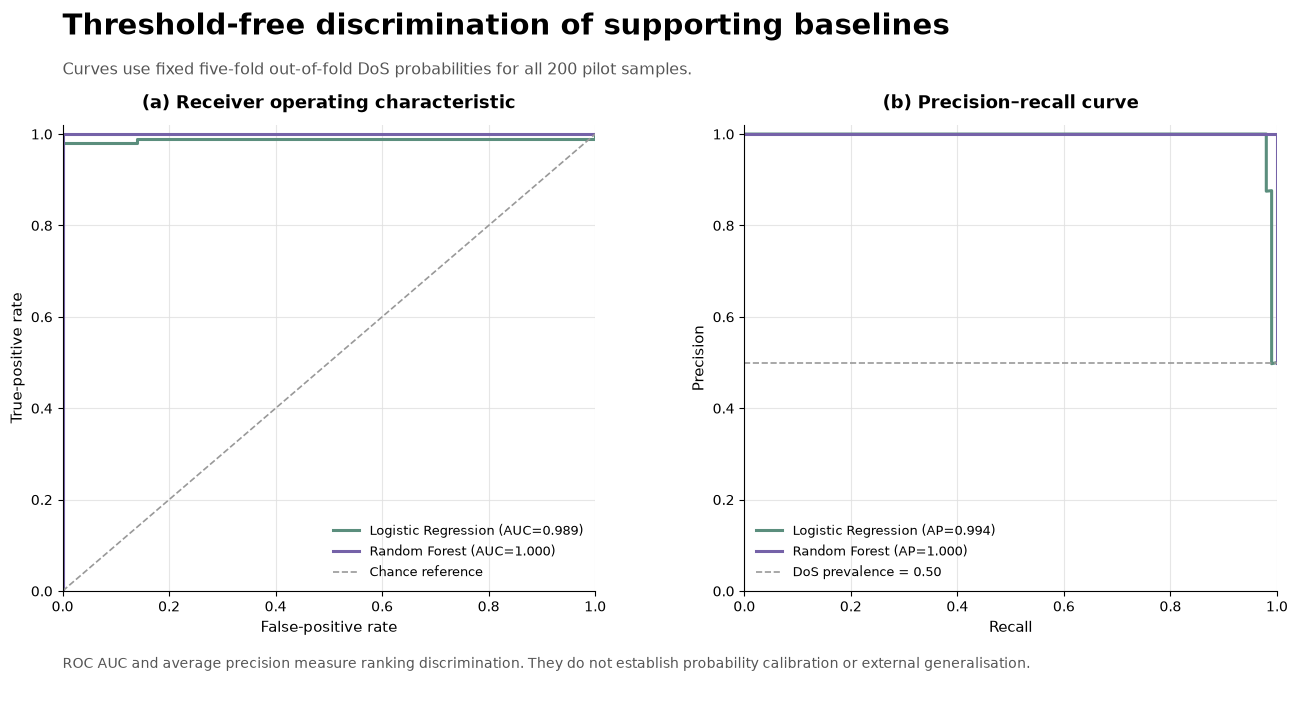

Threshold-free supporting-baseline OOF metrics:


,model,model_display,sample_count,roc_auc,average_precision,brier_score
0,logistic_regression,Logistic Regression,200,0.9886,0.9938,0.0171
1,random_forest,Random Forest,200,1.0000,1.0000,0.0042


figure_07_action                           replaced_with_zoomed_non_overlapping_layout
figure_08_action                            replaced_with_direct_ablation_change_panel
figure_09_action                                  created_from_fixed_oof_probabilities
figure_07_png_sha256                 8c18115a5b8c552746931be08d29641fb7cca20722c149...
figure_07_pdf_sha256                 1266d8f7192c0fe449b612fb0c3c739b7fe0b86fb402e3...
figure_08_png_sha256                 234c079e1a888b21e67a7e268e14960a55d418acacf2a0...
figure_08_pdf_sha256                 029a977b7546d83892a9cc5f1538bdbb1d034e6eaf160f...
figure_09_png_path                   /Users/ruiwang/Developer/compsci742-rui-pilot/...
figure_09_png_sha256                 573b12eed98b77a31106f35ac249e6b4414e8b3736de42...
figure_09_pdf_path                   /Users/ruiwang/Developer/compsci742-rui-pilot/...
figure_09_pdf_sha256                 3878ca2ba0f7e20f9105735a17a8814de033342a7f2b73...
metric_values_recalculated                 

In [19]:
# Refine Figures 7 and 8 without recalculating metrics, and create Figure 9
# from the already generated fixed OOF probability predictions.

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)


# ---------------------------------------------------------------------------
# 1. Refined Figure 7: near-ceiling baseline metrics
# ---------------------------------------------------------------------------

figure_07_refined = plt.figure(
    figsize=(13.5, 8.4),
    constrained_layout=False,
)

figure_07_refined_grid = figure_07_refined.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=[0.85, 5.0, 1.0],
    left=0.20,
    right=0.94,
    top=0.96,
    bottom=0.06,
    hspace=0.12,
)

figure_07_refined_title_axis = (
    figure_07_refined.add_subplot(
        figure_07_refined_grid[0, 0]
    )
)
figure_07_refined_title_axis.axis("off")

figure_07_refined_title_axis.text(
    -0.12,
    0.78,
    "Supporting-baseline detection metrics",
    fontsize=21,
    fontweight="bold",
    ha="left",
    va="center",
    transform=figure_07_refined_title_axis.transAxes,
)

figure_07_refined_title_axis.text(
    -0.12,
    0.22,
    (
        "Fixed five-fold OOF estimates with 10,000 "
        "class-stratified bootstrap replicates; "
        "the horizontal scale is intentionally zoomed."
    ),
    fontsize=11.3,
    color="#555555",
    ha="left",
    va="center",
    transform=figure_07_refined_title_axis.transAxes,
)

figure_07_refined_axis = (
    figure_07_refined.add_subplot(
        figure_07_refined_grid[1, 0]
    )
)

refined_metric_y_positions = np.arange(
    len(METRIC_ORDER)
)[::-1]

refined_model_offsets = {
    "logistic_regression": 0.13,
    "random_forest": -0.13,
}

refined_model_markers = {
    "logistic_regression": "o",
    "random_forest": "s",
}

for model_name in BASELINE_MODEL_ORDER:
    model_interval_table = (
        baseline_bootstrap_metric_ci_table.loc[
            baseline_bootstrap_metric_ci_table[
                "model"
            ].eq(model_name)
        ]
        .set_index("metric")
        .loc[METRIC_ORDER]
        .reset_index()
    )

    estimates = model_interval_table[
        "estimate"
    ].to_numpy()

    lower_errors = (
        estimates
        - model_interval_table["ci_lower"].to_numpy()
    )
    upper_errors = (
        model_interval_table["ci_upper"].to_numpy()
        - estimates
    )

    plotted_y_positions = (
        refined_metric_y_positions
        + refined_model_offsets[model_name]
    )

    figure_07_refined_axis.errorbar(
        estimates,
        plotted_y_positions,
        xerr=np.vstack(
            [lower_errors, upper_errors]
        ),
        fmt=refined_model_markers[model_name],
        markersize=7.5,
        linewidth=1.8,
        capsize=4,
        color=BASELINE_COLOURS[model_name],
        label=baseline_model_display_names[
            model_name
        ],
        zorder=3,
    )

    for estimate, y_position in zip(
        estimates,
        plotted_y_positions,
    ):
        figure_07_refined_axis.annotate(
            f"{estimate:.3f}",
            xy=(estimate, y_position),
            xytext=(-9, 0),
            textcoords="offset points",
            ha="right",
            va="center",
            fontsize=10.2,
            fontweight="bold",
            color=BASELINE_COLOURS[model_name],
        )

figure_07_refined_axis.set_yticks(
    refined_metric_y_positions
)
figure_07_refined_axis.set_yticklabels(
    [
        METRIC_DISPLAY_NAMES[metric_name]
        for metric_name in METRIC_ORDER
    ],
    fontsize=11.3,
)

figure_07_refined_axis.set_xlim(0.88, 1.01)
figure_07_refined_axis.set_xticks(
    np.arange(0.88, 1.001, 0.02)
)
figure_07_refined_axis.set_xlabel(
    "Metric value with 95% bootstrap interval "
    "(zoomed scale: 0.88–1.01)",
    fontsize=11.3,
    labelpad=10,
)

figure_07_refined_axis.axvline(
    1.0,
    color="#999999",
    linestyle="--",
    linewidth=1.0,
    zorder=0,
)

figure_07_refined_axis.grid(
    axis="x",
    color="#D9D9D9",
    linewidth=0.8,
    alpha=0.8,
)
figure_07_refined_axis.set_axisbelow(True)
figure_07_refined_axis.spines["top"].set_visible(False)
figure_07_refined_axis.spines["right"].set_visible(False)

figure_07_refined_axis.legend(
    loc="lower left",
    bbox_to_anchor=(0.0, 1.015),
    ncol=2,
    frameon=False,
    fontsize=11,
)

figure_07_refined_footer_axis = (
    figure_07_refined.add_subplot(
        figure_07_refined_grid[2, 0]
    )
)
figure_07_refined_footer_axis.axis("off")

figure_07_refined_footer_axis.text(
    -0.12,
    0.70,
    (
        "The zoomed scale is used only to distinguish "
        "near-ceiling estimates; all metrics retain "
        "their original 0–1 definitions."
    ),
    fontsize=10.2,
    color="#555555",
    ha="left",
    va="center",
    transform=figure_07_refined_footer_axis.transAxes,
)

figure_07_refined_footer_axis.text(
    -0.12,
    0.23,
    (
        "Random Forest intervals collapse at 1.0 because "
        "the fixed OOF record contains no observed errors; "
        "this is not an external-performance guarantee."
    ),
    fontsize=10.2,
    color="#555555",
    ha="left",
    va="center",
    transform=figure_07_refined_footer_axis.transAxes,
)

figure_07_refined.savefig(
    FIGURE_07_PNG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
figure_07_refined.savefig(
    FIGURE_07_PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(figure_07_refined)


# ---------------------------------------------------------------------------
# 2. Refined Figure 8: dominant-feature distribution and direct metric change
# ---------------------------------------------------------------------------

figure_08_refined = plt.figure(
    figsize=(14.2, 8.8),
    constrained_layout=False,
)

figure_08_refined_grid = figure_08_refined.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[0.82, 4.8, 1.05],
    width_ratios=[1.06, 1.12],
    left=0.08,
    right=0.96,
    top=0.96,
    bottom=0.06,
    wspace=0.31,
    hspace=0.18,
)

figure_08_refined_title_axis = (
    figure_08_refined.add_subplot(
        figure_08_refined_grid[0, :]
    )
)
figure_08_refined_title_axis.axis("off")

figure_08_refined_title_axis.text(
    0.0,
    0.78,
    "Dominant-predictor and post-hoc ablation diagnostic",
    fontsize=21,
    fontweight="bold",
    ha="left",
    va="center",
)

figure_08_refined_title_axis.text(
    0.0,
    0.23,
    (
        "MIN_IP_PKT_LEN perfectly separates this pilot "
        "sample, but removing it has little effect on "
        "the multivariable supporting baselines."
    ),
    fontsize=11.3,
    color="#555555",
    ha="left",
    va="center",
)

refined_distribution_axis = (
    figure_08_refined.add_subplot(
        figure_08_refined_grid[1, 0]
    )
)
refined_ablation_axis = (
    figure_08_refined.add_subplot(
        figure_08_refined_grid[1, 1]
    )
)

dominant_values = sorted(
    baseline_design_table[
        DOMINANT_PREDICTOR_NAME
    ].unique()
)
dominant_value_positions = np.arange(
    len(dominant_values)
)
dominant_bar_width = 0.36

for class_offset, (
    true_binary,
    true_label,
    colour,
) in enumerate(
    [
        (0, "Benign", "#6C8EAD"),
        (1, "DoS", "#D96C5F"),
    ]
):
    class_counts = (
        dominant_predictor_distribution_table.loc[
            dominant_predictor_distribution_table[
                "true_binary"
            ].eq(true_binary)
        ]
        .set_index(DOMINANT_PREDICTOR_NAME)[
            "sample_count"
        ]
        .reindex(
            dominant_values,
            fill_value=0,
        )
        .to_numpy()
    )

    horizontal_offset = (
        -dominant_bar_width / 2
        if class_offset == 0
        else dominant_bar_width / 2
    )

    refined_distribution_axis.bar(
        dominant_value_positions
        + horizontal_offset,
        class_counts,
        width=dominant_bar_width,
        color=colour,
        label=true_label,
        edgecolor="white",
        linewidth=0.8,
    )

    for x_position, count in zip(
        dominant_value_positions
        + horizontal_offset,
        class_counts,
    ):
        if count > 0:
            refined_distribution_axis.text(
                x_position,
                count + 1.5,
                str(int(count)),
                ha="center",
                va="bottom",
                fontsize=9.5,
                fontweight="bold",
                color=colour,
            )

refined_distribution_axis.set_title(
    "(a) Class distribution of MIN_IP_PKT_LEN",
    fontsize=13.2,
    fontweight="bold",
    pad=13,
)
refined_distribution_axis.set_xticks(
    dominant_value_positions
)
refined_distribution_axis.set_xticklabels(
    [str(value) for value in dominant_values]
)
refined_distribution_axis.set_xlabel(
    "Observed MIN_IP_PKT_LEN value",
    fontsize=11,
    labelpad=9,
)
refined_distribution_axis.set_ylabel(
    "Number of samples",
    fontsize=11,
    labelpad=9,
)
refined_distribution_axis.legend(
    frameon=False,
    loc="upper right",
)
refined_distribution_axis.grid(
    axis="y",
    color="#DDDDDD",
    linewidth=0.8,
    alpha=0.8,
)
refined_distribution_axis.set_axisbelow(True)
refined_distribution_axis.spines["top"].set_visible(False)
refined_distribution_axis.spines["right"].set_visible(False)

# Directly plot ablated minus primary metric values. This makes a zero change
# visible instead of placing two markers on top of one another near 1.0.
ablation_change_metric_order = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "balanced_accuracy",
]

ablation_change_y_positions = np.arange(
    len(ablation_change_metric_order)
)[::-1]

ablation_change_offsets = {
    "logistic_regression": 0.12,
    "random_forest": -0.12,
}

for model_name in BASELINE_MODEL_ORDER:
    model_change_table = (
        primary_vs_ablation_metric_table.loc[
            primary_vs_ablation_metric_table[
                "model"
            ].eq(model_name)
        ]
        .set_index("metric")
        .loc[ablation_change_metric_order]
    )

    change_values = model_change_table[
        "ablation_difference"
    ].to_numpy()

    plotted_y_positions = (
        ablation_change_y_positions
        + ablation_change_offsets[model_name]
    )

    refined_ablation_axis.scatter(
        change_values,
        plotted_y_positions,
        s=70,
        marker=(
            "o"
            if model_name == "logistic_regression"
            else "s"
        ),
        color=BASELINE_COLOURS[model_name],
        edgecolor="white",
        linewidth=0.8,
        label=baseline_model_display_names[
            model_name
        ],
        zorder=3,
    )

    for change_value, y_position in zip(
        change_values,
        plotted_y_positions,
    ):
        text_offset = 7 if change_value >= 0 else -7
        horizontal_alignment = (
            "left"
            if change_value >= 0
            else "right"
        )

        refined_ablation_axis.annotate(
            f"{change_value:+.3f}",
            xy=(change_value, y_position),
            xytext=(text_offset, 0),
            textcoords="offset points",
            ha=horizontal_alignment,
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color=BASELINE_COLOURS[model_name],
        )

refined_ablation_axis.axvline(
    0.0,
    color="#555555",
    linestyle="--",
    linewidth=1.2,
    zorder=0,
)

refined_ablation_axis.set_title(
    "(b) Change after removing MIN_IP_PKT_LEN",
    fontsize=13.2,
    fontweight="bold",
    pad=13,
)

refined_ablation_axis.set_yticks(
    ablation_change_y_positions
)
refined_ablation_axis.set_yticklabels(
    [
        METRIC_DISPLAY_NAMES[metric_name]
        for metric_name in ablation_change_metric_order
    ],
    fontsize=10.3,
)

refined_ablation_axis.set_xlim(-0.018, 0.008)
refined_ablation_axis.set_xlabel(
    "Metric change: post-hoc 45 − primary 46",
    fontsize=11,
    labelpad=9,
)
refined_ablation_axis.grid(
    axis="x",
    color="#DDDDDD",
    linewidth=0.8,
    alpha=0.8,
)
refined_ablation_axis.set_axisbelow(True)
refined_ablation_axis.spines["top"].set_visible(False)
refined_ablation_axis.spines["right"].set_visible(False)

refined_ablation_axis.legend(
    frameon=False,
    fontsize=9.5,
    loc="lower left",
)

figure_08_refined_footer_axis = (
    figure_08_refined.add_subplot(
        figure_08_refined_grid[2, :]
    )
)
figure_08_refined_footer_axis.axis("off")

figure_08_refined_footer_axis.text(
    0.0,
    0.68,
    (
        "Negative changes indicate lower performance "
        "after removal. Random Forest was unchanged; "
        "Logistic Regression changed by at most "
        "one percentage point."
    ),
    fontsize=10.2,
    color="#555555",
    ha="left",
    va="center",
)

figure_08_refined_footer_axis.text(
    0.0,
    0.22,
    (
        "This post-hoc diagnostic does not replace or "
        "modify the locked primary-46 analysis."
    ),
    fontsize=10.2,
    color="#555555",
    ha="left",
    va="center",
)

figure_08_refined.savefig(
    FIGURE_08_PNG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
figure_08_refined.savefig(
    FIGURE_08_PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(figure_08_refined)


# ---------------------------------------------------------------------------
# 3. Figure 9: ROC and precision–recall curves from fixed OOF probabilities
# ---------------------------------------------------------------------------

baseline_probability_metric_records = []
baseline_curve_records = {}

for model_name in BASELINE_MODEL_ORDER:
    probability_values = (
        baseline_oof_prediction_table[
            f"{model_name}_dos_probability"
        ]
        .astype(float)
        .to_numpy()
    )

    false_positive_rates, true_positive_rates, _ = (
        roc_curve(
            baseline_target_vector,
            probability_values,
        )
    )

    precision_values, recall_values, _ = (
        precision_recall_curve(
            baseline_target_vector,
            probability_values,
        )
    )

    roc_auc_value = roc_auc_score(
        baseline_target_vector,
        probability_values,
    )

    average_precision_value = (
        average_precision_score(
            baseline_target_vector,
            probability_values,
        )
    )

    brier_score_value = brier_score_loss(
        baseline_target_vector,
        probability_values,
    )

    baseline_curve_records[model_name] = {
        "false_positive_rate": false_positive_rates,
        "true_positive_rate": true_positive_rates,
        "precision": precision_values,
        "recall": recall_values,
    }

    baseline_probability_metric_records.append(
        {
            "model": model_name,
            "model_display": (
                baseline_model_display_names[
                    model_name
                ]
            ),
            "sample_count": 200,
            "roc_auc": float(roc_auc_value),
            "average_precision": float(
                average_precision_value
            ),
            "brier_score": float(
                brier_score_value
            ),
        }
    )

baseline_probability_metrics_table = pd.DataFrame(
    baseline_probability_metric_records
)

FIGURE_09_PNG_PATH = (
    FIGURES_DIR
    / "figure_09_supporting_baseline_roc_pr_curves.png"
)
FIGURE_09_PDF_PATH = (
    FIGURES_DIR
    / "figure_09_supporting_baseline_roc_pr_curves.pdf"
)

figure_09 = plt.figure(
    figsize=(13.8, 7.9),
    constrained_layout=False,
)

figure_09_grid = figure_09.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[0.78, 4.7, 0.85],
    width_ratios=[1.0, 1.0],
    left=0.08,
    right=0.96,
    top=0.96,
    bottom=0.07,
    wspace=0.28,
    hspace=0.18,
)

figure_09_title_axis = figure_09.add_subplot(
    figure_09_grid[0, :]
)
figure_09_title_axis.axis("off")

figure_09_title_axis.text(
    0.0,
    0.78,
    "Threshold-free discrimination of supporting baselines",
    fontsize=21,
    fontweight="bold",
    ha="left",
    va="center",
)

figure_09_title_axis.text(
    0.0,
    0.22,
    (
        "Curves use fixed five-fold out-of-fold DoS "
        "probabilities for all 200 pilot samples."
    ),
    fontsize=11.3,
    color="#555555",
    ha="left",
    va="center",
)

roc_axis = figure_09.add_subplot(
    figure_09_grid[1, 0]
)
precision_recall_axis = figure_09.add_subplot(
    figure_09_grid[1, 1]
)

for model_name in BASELINE_MODEL_ORDER:
    probability_metric_row = (
        baseline_probability_metrics_table.loc[
            baseline_probability_metrics_table[
                "model"
            ].eq(model_name)
        ]
        .iloc[0]
    )

    roc_axis.plot(
        baseline_curve_records[model_name][
            "false_positive_rate"
        ],
        baseline_curve_records[model_name][
            "true_positive_rate"
        ],
        color=BASELINE_COLOURS[model_name],
        linewidth=2.2,
        label=(
            f"{baseline_model_display_names[model_name]} "
            f"(AUC={probability_metric_row['roc_auc']:.3f})"
        ),
    )

    precision_recall_axis.plot(
        baseline_curve_records[model_name][
            "recall"
        ],
        baseline_curve_records[model_name][
            "precision"
        ],
        color=BASELINE_COLOURS[model_name],
        linewidth=2.2,
        label=(
            f"{baseline_model_display_names[model_name]} "
            f"(AP={probability_metric_row['average_precision']:.3f})"
        ),
    )

roc_axis.plot(
    [0, 1],
    [0, 1],
    color="#999999",
    linestyle="--",
    linewidth=1.2,
    label="Chance reference",
)

precision_recall_axis.axhline(
    y=float(baseline_target_vector.mean()),
    color="#999999",
    linestyle="--",
    linewidth=1.2,
    label="DoS prevalence = 0.50",
)

roc_axis.set_title(
    "(a) Receiver operating characteristic",
    fontsize=13.2,
    fontweight="bold",
    pad=12,
)
roc_axis.set_xlabel(
    "False-positive rate",
    fontsize=11,
)
roc_axis.set_ylabel(
    "True-positive rate",
    fontsize=11,
)
roc_axis.set_xlim(0.0, 1.0)
roc_axis.set_ylim(0.0, 1.02)
roc_axis.legend(
    frameon=False,
    loc="lower right",
    fontsize=9.4,
)

precision_recall_axis.set_title(
    "(b) Precision–recall curve",
    fontsize=13.2,
    fontweight="bold",
    pad=12,
)
precision_recall_axis.set_xlabel(
    "Recall",
    fontsize=11,
)
precision_recall_axis.set_ylabel(
    "Precision",
    fontsize=11,
)
precision_recall_axis.set_xlim(0.0, 1.0)
precision_recall_axis.set_ylim(0.0, 1.02)
precision_recall_axis.legend(
    frameon=False,
    loc="lower left",
    fontsize=9.4,
)

for curve_axis in [
    roc_axis,
    precision_recall_axis,
]:
    curve_axis.grid(
        color="#E0E0E0",
        linewidth=0.8,
        alpha=0.8,
    )
    curve_axis.set_axisbelow(True)
    curve_axis.spines["top"].set_visible(False)
    curve_axis.spines["right"].set_visible(False)

figure_09_footer_axis = figure_09.add_subplot(
    figure_09_grid[2, :]
)
figure_09_footer_axis.axis("off")

figure_09_footer_axis.text(
    0.0,
    0.58,
    (
        "ROC AUC and average precision measure ranking "
        "discrimination. They do not establish probability "
        "calibration or external generalisation."
    ),
    fontsize=10.2,
    color="#555555",
    ha="left",
    va="center",
)

figure_09.savefig(
    FIGURE_09_PNG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
figure_09.savefig(
    FIGURE_09_PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(figure_09)

print(
    "Threshold-free supporting-baseline OOF metrics:"
)
display(
    baseline_probability_metrics_table.round(4)
)


# ---------------------------------------------------------------------------
# 4. Figure refinement and generation audit
# ---------------------------------------------------------------------------

refined_baseline_visualisation_summary = pd.Series(
    {
        "figure_07_action": (
            "replaced_with_zoomed_non_overlapping_layout"
        ),
        "figure_08_action": (
            "replaced_with_direct_ablation_change_panel"
        ),
        "figure_09_action": (
            "created_from_fixed_oof_probabilities"
        ),
        "figure_07_png_sha256": notebook_file_sha256(
            FIGURE_07_PNG_PATH
        ),
        "figure_07_pdf_sha256": notebook_file_sha256(
            FIGURE_07_PDF_PATH
        ),
        "figure_08_png_sha256": notebook_file_sha256(
            FIGURE_08_PNG_PATH
        ),
        "figure_08_pdf_sha256": notebook_file_sha256(
            FIGURE_08_PDF_PATH
        ),
        "figure_09_png_path": str(
            FIGURE_09_PNG_PATH
        ),
        "figure_09_png_sha256": notebook_file_sha256(
            FIGURE_09_PNG_PATH
        ),
        "figure_09_pdf_path": str(
            FIGURE_09_PDF_PATH
        ),
        "figure_09_pdf_sha256": notebook_file_sha256(
            FIGURE_09_PDF_PATH
        ),
        "metric_values_recalculated": False,
        "oof_predictions_modified": False,
        "primary_feature_contract_modified": False,
        "evaluation_figures_written": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "refined_baseline_visualisation"
        ),
    },
    name="value",
)

display(refined_baseline_visualisation_summary)

## 13. Integrated RQ1 performance summary

The primary RQ1 comparison and the supporting baselines answer related but
different questions.

The left panel presents the controlled within-sample LLM experiment using the 178
samples for which both representations produced valid responses. This panel
estimates the effect of changing only the representation of the same 46 feature
values.

The right panel presents five-fold out-of-fold performance for Logistic Regression
and Random Forest using all 200 labelled samples. These models establish that the
locked feature table contains strong within-dataset classification signal, but
they are not additional representation conditions.

Because the LLM and baseline estimates use different analysis populations and
prediction mechanisms, the figure supports descriptive contextual comparison
only. The exact McNemar test and paired bootstrap remain the primary inferential
analyses for the structured-JSON versus deterministic-text contrast.

Integrated RQ1 descriptive comparison:


,method,method_role,evaluation_design,sample_count,accuracy,precision,recall,f1,specificity,balanced_accuracy
0,Structured JSON,primary_llm_condition,complete_pair_valid_response_analysis,178,0.5000,0.4634,0.2209,0.2992,0.7609,0.4909
1,Deterministic text,primary_llm_condition,complete_pair_valid_response_analysis,178,0.4213,0.3455,0.2209,0.2695,0.6087,0.4148
2,Logistic Regression,supporting_tabular_baseline,fixed_five_fold_out_of_fold,200,0.9750,1.0000,0.9500,0.9744,1.0000,0.9750
3,Random Forest,supporting_tabular_baseline,fixed_five_fold_out_of_fold,200,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


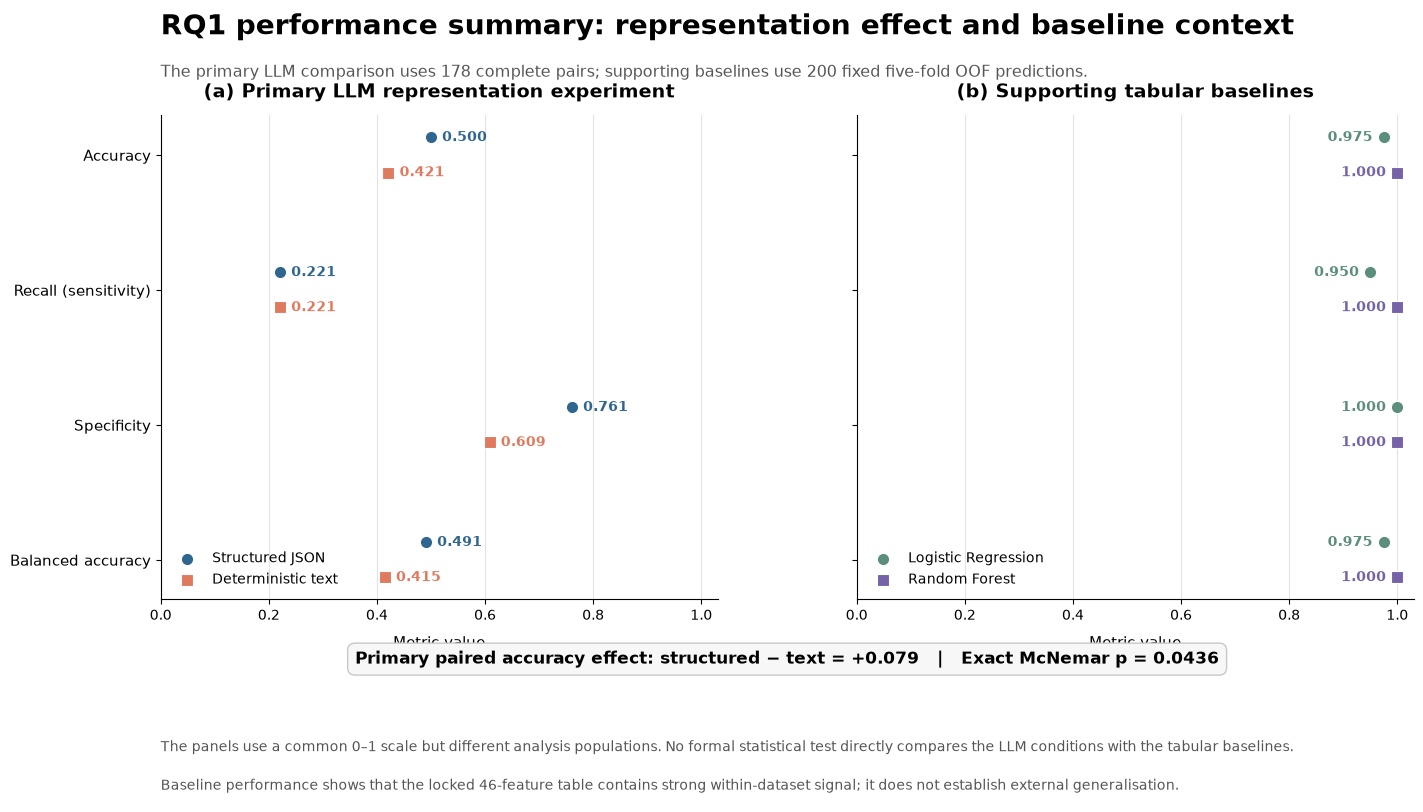

primary_llm_analysis_population                             178 complete paired valid responses
supporting_baseline_analysis_population                   200 five-fold out-of-fold predictions
llm_and_baselines_shown_in_separate_panels                                                 True
common_zero_to_one_axis_used                                                               True
formal_llm_vs_baseline_test_performed                                                     False
paired_accuracy_difference                                                             0.078652
mcnemar_exact_two_sided_p_value                                                        0.043559
figure_10_png_path                            /Users/ruiwang/Developer/compsci742-rui-pilot/...
figure_10_png_sha256                          cb6df155d97bef0d1fc91ea2002b182710c494cdc34af7...
figure_10_pdf_path                            /Users/ruiwang/Developer/compsci742-rui-pilot/...
figure_10_pdf_sha256                    

In [20]:
# Create the integrated RQ1 comparison figure.
#
# LLM conditions and tabular baselines are deliberately separated into two
# panels because they use different evaluation populations and estimands.

from scipy.stats import binomtest

RQ1_FIGURE_METRICS = [
    "accuracy",
    "recall",
    "specificity",
    "balanced_accuracy",
]

RQ1_METHOD_COLOURS = {
    "Structured JSON": "#2F6690",
    "Deterministic text": "#E07A5F",
    "Logistic Regression": BASELINE_COLOURS[
        "logistic_regression"
    ],
    "Random Forest": BASELINE_COLOURS[
        "random_forest"
    ],
}


# ---------------------------------------------------------------------------
# 1. Resolve the two paired LLM rows and two baseline rows
# ---------------------------------------------------------------------------

assert "condition_display" in paired_metrics_table.columns
assert "model_display" in baseline_point_metrics_table.columns

paired_condition_names = (
    paired_metrics_table["condition_display"]
    .astype(str)
    .str.strip()
)

structured_row_candidates = paired_metrics_table.loc[
    paired_condition_names
    .str.lower()
    .str.contains("structured")
]

text_row_candidates = paired_metrics_table.loc[
    paired_condition_names
    .str.lower()
    .str.contains("text")
]

assert len(structured_row_candidates) == 1
assert len(text_row_candidates) == 1

structured_paired_metric_row = (
    structured_row_candidates.iloc[0]
)
text_paired_metric_row = (
    text_row_candidates.iloc[0]
)

logistic_baseline_metric_row = (
    baseline_point_metrics_table.loc[
        baseline_point_metrics_table[
            "model"
        ].eq("logistic_regression")
    ]
    .iloc[0]
)

random_forest_baseline_metric_row = (
    baseline_point_metrics_table.loc[
        baseline_point_metrics_table[
            "model"
        ].eq("random_forest")
    ]
    .iloc[0]
)


# ---------------------------------------------------------------------------
# 2. Build an explicit comparison table with estimand and population metadata
# ---------------------------------------------------------------------------

rq1_integrated_comparison_records = []

for method_name, method_role, evaluation_design, sample_count, metric_row in [
    (
        "Structured JSON",
        "primary_llm_condition",
        "complete_pair_valid_response_analysis",
        178,
        structured_paired_metric_row,
    ),
    (
        "Deterministic text",
        "primary_llm_condition",
        "complete_pair_valid_response_analysis",
        178,
        text_paired_metric_row,
    ),
    (
        "Logistic Regression",
        "supporting_tabular_baseline",
        "fixed_five_fold_out_of_fold",
        200,
        logistic_baseline_metric_row,
    ),
    (
        "Random Forest",
        "supporting_tabular_baseline",
        "fixed_five_fold_out_of_fold",
        200,
        random_forest_baseline_metric_row,
    ),
]:
    comparison_record = {
        "method": method_name,
        "method_role": method_role,
        "evaluation_design": evaluation_design,
        "sample_count": sample_count,
    }

    for metric_name in METRIC_ORDER:
        comparison_record[metric_name] = float(
            metric_row[metric_name]
        )

    rq1_integrated_comparison_records.append(
        comparison_record
    )

rq1_integrated_comparison_table = pd.DataFrame(
    rq1_integrated_comparison_records
)

print("Integrated RQ1 descriptive comparison:")
display(
    rq1_integrated_comparison_table.loc[
        :,
        [
            "method",
            "method_role",
            "evaluation_design",
            "sample_count",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
        ],
    ].round(4)
)


# ---------------------------------------------------------------------------
# 3. Reconstruct the primary paired-accuracy test annotation
# ---------------------------------------------------------------------------

STRUCTURED_ONLY_CORRECT_COUNT = 28
TEXT_ONLY_CORRECT_COUNT = 14
DISCORDANT_PAIR_COUNT = (
    STRUCTURED_ONLY_CORRECT_COUNT
    + TEXT_ONLY_CORRECT_COUNT
)

rq1_paired_accuracy_difference = float(
    structured_paired_metric_row["accuracy"]
    - text_paired_metric_row["accuracy"]
)

rq1_mcnemar_exact_p_value = float(
    binomtest(
        k=min(
            STRUCTURED_ONLY_CORRECT_COUNT,
            TEXT_ONLY_CORRECT_COUNT,
        ),
        n=DISCORDANT_PAIR_COUNT,
        p=0.5,
        alternative="two-sided",
    ).pvalue
)

assert DISCORDANT_PAIR_COUNT == 42
assert np.isclose(
    rq1_paired_accuracy_difference,
    0.0786516853932584,
)
assert np.isclose(
    rq1_mcnemar_exact_p_value,
    0.043559,
    atol=1e-6,
)


# ---------------------------------------------------------------------------
# 4. Figure 10: separated primary experiment and supporting baselines
# ---------------------------------------------------------------------------

FIGURE_10_PNG_PATH = (
    FIGURES_DIR
    / "figure_10_integrated_rq1_performance_summary.png"
)
FIGURE_10_PDF_PATH = (
    FIGURES_DIR
    / "figure_10_integrated_rq1_performance_summary.pdf"
)

figure_10 = plt.figure(
    figsize=(14.4, 8.8),
    constrained_layout=False,
)

figure_10_grid = figure_10.add_gridspec(
    nrows=4,
    ncols=2,
    height_ratios=[0.78, 4.7, 0.70, 0.78],
    width_ratios=[1.0, 1.0],
    left=0.09,
    right=0.96,
    top=0.96,
    bottom=0.06,
    wspace=0.25,
    hspace=0.14,
)

figure_10_title_axis = figure_10.add_subplot(
    figure_10_grid[0, :]
)
figure_10_title_axis.axis("off")

figure_10_title_axis.text(
    0.0,
    0.79,
    "RQ1 performance summary: representation effect and baseline context",
    fontsize=20.5,
    fontweight="bold",
    ha="left",
    va="center",
)

figure_10_title_axis.text(
    0.0,
    0.22,
    (
        "The primary LLM comparison uses 178 complete "
        "pairs; supporting baselines use 200 fixed "
        "five-fold OOF predictions."
    ),
    fontsize=11.3,
    color="#555555",
    ha="left",
    va="center",
)

llm_summary_axis = figure_10.add_subplot(
    figure_10_grid[1, 0]
)
baseline_summary_axis = figure_10.add_subplot(
    figure_10_grid[1, 1],
    sharex=llm_summary_axis,
    sharey=llm_summary_axis,
)

rq1_metric_y_positions = np.arange(
    len(RQ1_FIGURE_METRICS)
)[::-1]

panel_method_offsets = {
    0: 0.13,
    1: -0.13,
}

llm_plot_methods = [
    (
        "Structured JSON",
        structured_paired_metric_row,
    ),
    (
        "Deterministic text",
        text_paired_metric_row,
    ),
]

baseline_plot_methods = [
    (
        "Logistic Regression",
        logistic_baseline_metric_row,
    ),
    (
        "Random Forest",
        random_forest_baseline_metric_row,
    ),
]


def draw_rq1_metric_panel(
    axis,
    method_rows,
    panel_title,
):
    """Draw one panel using common axes and direct value labels."""

    for method_index, (
        method_name,
        metric_row,
    ) in enumerate(method_rows):
        metric_values = np.array(
            [
                float(metric_row[metric_name])
                for metric_name in RQ1_FIGURE_METRICS
            ]
        )

        plotted_y_positions = (
            rq1_metric_y_positions
            + panel_method_offsets[method_index]
        )

        marker = "o" if method_index == 0 else "s"

        axis.scatter(
            metric_values,
            plotted_y_positions,
            s=78,
            marker=marker,
            color=RQ1_METHOD_COLOURS[
                method_name
            ],
            edgecolor="white",
            linewidth=0.8,
            label=method_name,
            zorder=3,
        )

        for metric_value, y_position in zip(
            metric_values,
            plotted_y_positions,
        ):
            # Put near-ceiling labels to the left and all other labels
            # to the right, preventing clipping and marker overlap.
            if metric_value >= 0.92:
                text_offset = -8
                horizontal_alignment = "right"
            else:
                text_offset = 8
                horizontal_alignment = "left"

            axis.annotate(
                f"{metric_value:.3f}",
                xy=(metric_value, y_position),
                xytext=(text_offset, 0),
                textcoords="offset points",
                ha=horizontal_alignment,
                va="center",
                fontsize=10.2,
                fontweight="bold",
                color=RQ1_METHOD_COLOURS[
                    method_name
                ],
            )

    axis.set_title(
        panel_title,
        fontsize=13.5,
        fontweight="bold",
        pad=13,
    )

    axis.set_xlim(0.0, 1.03)
    axis.set_xticks(
        np.arange(0.0, 1.01, 0.2)
    )
    axis.set_xlabel(
        "Metric value",
        fontsize=11,
        labelpad=9,
    )

    axis.grid(
        axis="x",
        color="#DDDDDD",
        linewidth=0.8,
        alpha=0.85,
    )
    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.legend(
        frameon=False,
        loc="lower left",
        fontsize=10,
    )


draw_rq1_metric_panel(
    llm_summary_axis,
    llm_plot_methods,
    "(a) Primary LLM representation experiment",
)

draw_rq1_metric_panel(
    baseline_summary_axis,
    baseline_plot_methods,
    "(b) Supporting tabular baselines",
)

llm_summary_axis.set_yticks(
    rq1_metric_y_positions
)
llm_summary_axis.set_yticklabels(
    [
        METRIC_DISPLAY_NAMES[metric_name]
        for metric_name in RQ1_FIGURE_METRICS
    ],
    fontsize=11,
)

baseline_summary_axis.tick_params(
    axis="y",
    labelleft=False,
)

# Separate inferential annotation from both plotting panels.
figure_10_result_axis = figure_10.add_subplot(
    figure_10_grid[2, :]
)
figure_10_result_axis.axis("off")

figure_10_result_axis.text(
    0.5,
    0.52,
    (
        "Primary paired accuracy effect: "
        f"structured − text = "
        f"{rq1_paired_accuracy_difference:+.3f}"
        "   |   "
        f"Exact McNemar p = "
        f"{rq1_mcnemar_exact_p_value:.4f}"
    ),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "#F7F7F7",
        "edgecolor": "#C8C8C8",
        "linewidth": 1.0,
    },
)

figure_10_footer_axis = figure_10.add_subplot(
    figure_10_grid[3, :]
)
figure_10_footer_axis.axis("off")

figure_10_footer_axis.text(
    0.0,
    0.68,
    (
        "The panels use a common 0–1 scale but different "
        "analysis populations. No formal statistical test "
        "directly compares the LLM conditions with the "
        "tabular baselines."
    ),
    fontsize=10.2,
    color="#555555",
    ha="left",
    va="center",
)

figure_10_footer_axis.text(
    0.0,
    0.20,
    (
        "Baseline performance shows that the locked "
        "46-feature table contains strong within-dataset "
        "signal; it does not establish external "
        "generalisation."
    ),
    fontsize=10.2,
    color="#555555",
    ha="left",
    va="center",
)

figure_10.savefig(
    FIGURE_10_PNG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
figure_10.savefig(
    FIGURE_10_PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(figure_10)


# ---------------------------------------------------------------------------
# 5. Integrated RQ1 figure audit
# ---------------------------------------------------------------------------

rq1_integrated_figure_summary = pd.Series(
    {
        "primary_llm_analysis_population": (
            "178 complete paired valid responses"
        ),
        "supporting_baseline_analysis_population": (
            "200 five-fold out-of-fold predictions"
        ),
        "llm_and_baselines_shown_in_separate_panels": True,
        "common_zero_to_one_axis_used": True,
        "formal_llm_vs_baseline_test_performed": False,
        "paired_accuracy_difference": (
            rq1_paired_accuracy_difference
        ),
        "mcnemar_exact_two_sided_p_value": (
            rq1_mcnemar_exact_p_value
        ),
        "figure_10_png_path": str(
            FIGURE_10_PNG_PATH
        ),
        "figure_10_png_sha256": (
            notebook_file_sha256(
                FIGURE_10_PNG_PATH
            )
        ),
        "figure_10_pdf_path": str(
            FIGURE_10_PDF_PATH
        ),
        "figure_10_pdf_sha256": (
            notebook_file_sha256(
                FIGURE_10_PDF_PATH
            )
        ),
        "metric_values_recalculated": False,
        "primary_predictions_modified": False,
        "baseline_predictions_modified": False,
        "evaluation_figure_written": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "integrated_rq1_performance_summary"
        ),
    },
    name="value",
)

display(rq1_integrated_figure_summary)

### 13.1 Figure 10 layout correction

The initial integrated RQ1 figure placed the paired-test annotation too close to
the plotting panels, causing it to obscure the horizontal-axis labels.

This correction regenerates only the derived figure using fully separated title,
plot, statistical-result, and methodological-note regions. No prediction, metric,
sample, confidence interval, or statistical result is recalculated or modified.

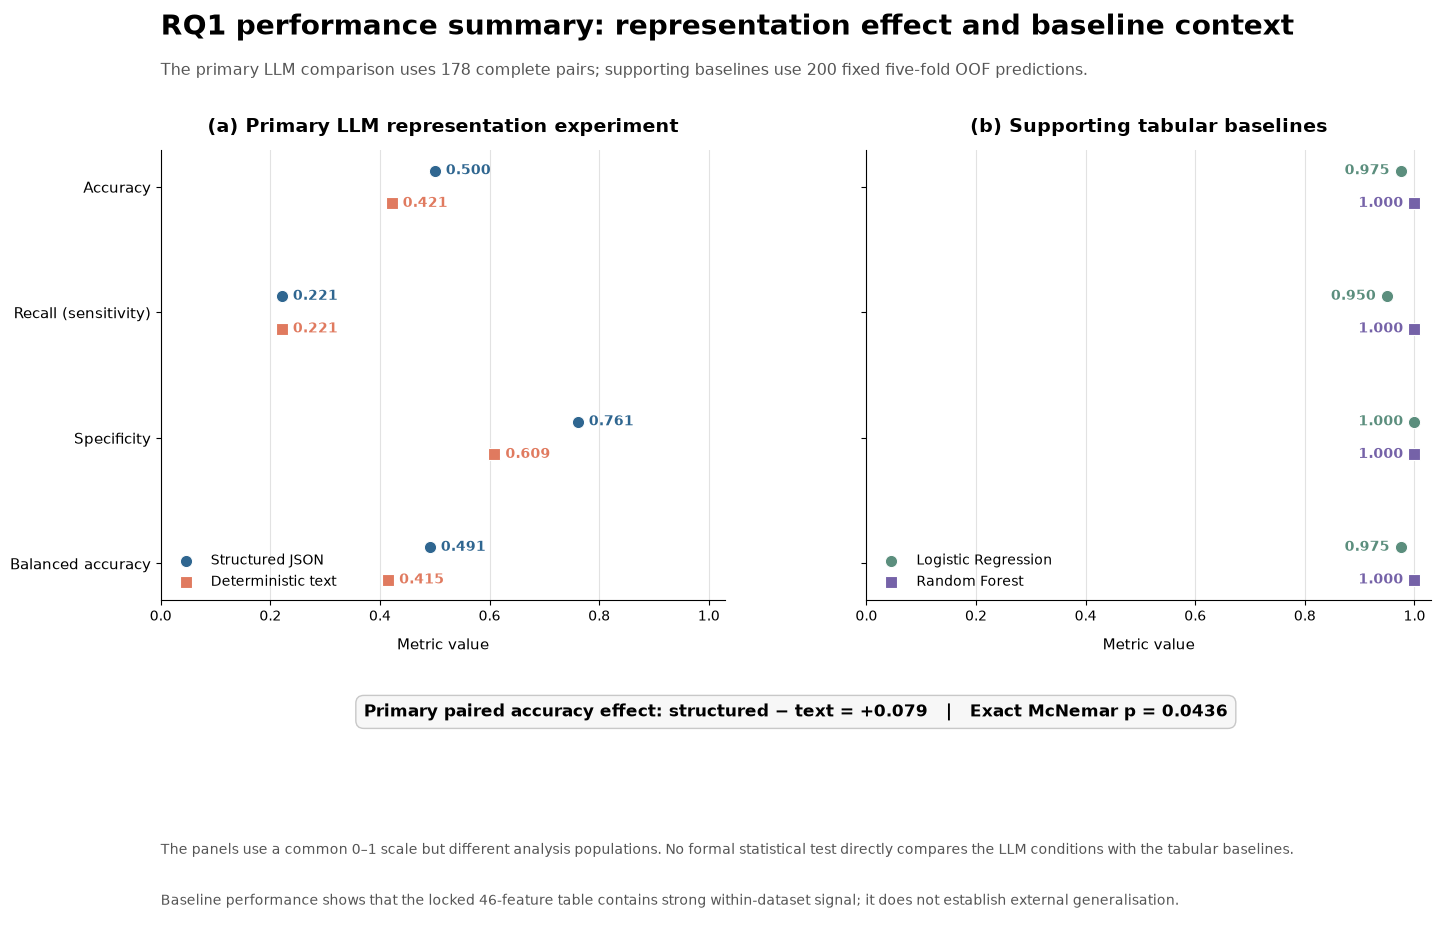

figure_number                                                                           10
layout_status                                           refined_with_four_separate_regions
title_region_separated                                                                True
plot_region_separated                                                                 True
axis_label_region_preserved                                                           True
statistical_result_region_separated                                                   True
methodological_note_region_separated                                                  True
figure_10_png_path                       /Users/ruiwang/Developer/compsci742-rui-pilot/...
figure_10_png_sha256                     76f4e9d0f069247e44d5482f925009e0242afdfb43c42c...
figure_10_pdf_path                       /Users/ruiwang/Developer/compsci742-rui-pilot/...
figure_10_pdf_sha256                     fc09f86ae1c02e8920f10664368cc4b066977a65684c27...

In [21]:
# Regenerate Figure 10 with fully separated layout regions.
#
# This cell changes presentation only. All experimental values and analysis
# populations remain unchanged.

FIGURE_10_PNG_PATH = (
    FIGURES_DIR
    / "figure_10_integrated_rq1_performance_summary.png"
)
FIGURE_10_PDF_PATH = (
    FIGURES_DIR
    / "figure_10_integrated_rq1_performance_summary.pdf"
)

figure_10_refined = plt.figure(
    figsize=(14.6, 10.2),
    constrained_layout=False,
)

# Four explicitly separated regions:
# 1. title and subtitle;
# 2. two plotting panels;
# 3. paired statistical result;
# 4. methodological notes.
figure_10_refined_grid = (
    figure_10_refined.add_gridspec(
        nrows=4,
        ncols=2,
        height_ratios=[0.90, 5.20, 1.10, 1.25],
        width_ratios=[1.0, 1.0],
        left=0.09,
        right=0.96,
        top=0.96,
        bottom=0.06,
        wspace=0.25,
        hspace=0.34,
    )
)

# ---------------------------------------------------------------------------
# 1. Independent title region
# ---------------------------------------------------------------------------

refined_title_axis = (
    figure_10_refined.add_subplot(
        figure_10_refined_grid[0, :]
    )
)
refined_title_axis.axis("off")

refined_title_axis.text(
    0.0,
    0.78,
    (
        "RQ1 performance summary: representation "
        "effect and baseline context"
    ),
    fontsize=20.5,
    fontweight="bold",
    ha="left",
    va="center",
)

refined_title_axis.text(
    0.0,
    0.22,
    (
        "The primary LLM comparison uses 178 complete "
        "pairs; supporting baselines use 200 fixed "
        "five-fold OOF predictions."
    ),
    fontsize=11.3,
    color="#555555",
    ha="left",
    va="center",
)


# ---------------------------------------------------------------------------
# 2. Independent plotting region
# ---------------------------------------------------------------------------

refined_llm_axis = (
    figure_10_refined.add_subplot(
        figure_10_refined_grid[1, 0]
    )
)

refined_baseline_axis = (
    figure_10_refined.add_subplot(
        figure_10_refined_grid[1, 1],
        sharex=refined_llm_axis,
        sharey=refined_llm_axis,
    )
)

refined_metric_y_positions = np.arange(
    len(RQ1_FIGURE_METRICS)
)[::-1]

refined_method_offsets = {
    0: 0.13,
    1: -0.13,
}


def draw_refined_rq1_panel(
    axis,
    method_rows,
    panel_title,
):
    """Draw one RQ1 panel with labels contained inside its region."""

    for method_index, (
        method_name,
        metric_row,
    ) in enumerate(method_rows):
        metric_values = np.array(
            [
                float(metric_row[metric_name])
                for metric_name in RQ1_FIGURE_METRICS
            ]
        )

        plotted_y_positions = (
            refined_metric_y_positions
            + refined_method_offsets[method_index]
        )

        axis.scatter(
            metric_values,
            plotted_y_positions,
            s=78,
            marker=(
                "o"
                if method_index == 0
                else "s"
            ),
            color=RQ1_METHOD_COLOURS[
                method_name
            ],
            edgecolor="white",
            linewidth=0.8,
            label=method_name,
            zorder=3,
        )

        for metric_value, y_position in zip(
            metric_values,
            plotted_y_positions,
        ):
            if metric_value >= 0.92:
                text_offset = -8
                horizontal_alignment = "right"
            else:
                text_offset = 8
                horizontal_alignment = "left"

            axis.annotate(
                f"{metric_value:.3f}",
                xy=(metric_value, y_position),
                xytext=(text_offset, 0),
                textcoords="offset points",
                ha=horizontal_alignment,
                va="center",
                fontsize=10.2,
                fontweight="bold",
                color=RQ1_METHOD_COLOURS[
                    method_name
                ],
            )

    axis.set_title(
        panel_title,
        fontsize=13.5,
        fontweight="bold",
        pad=13,
    )

    axis.set_xlim(0.0, 1.03)
    axis.set_xticks(
        np.arange(0.0, 1.01, 0.2)
    )

    axis.set_xlabel(
        "Metric value",
        fontsize=11,
        labelpad=10,
    )

    axis.grid(
        axis="x",
        color="#DDDDDD",
        linewidth=0.8,
        alpha=0.85,
    )
    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.legend(
        frameon=False,
        loc="lower left",
        fontsize=10,
        borderaxespad=0.4,
    )


draw_refined_rq1_panel(
    refined_llm_axis,
    llm_plot_methods,
    "(a) Primary LLM representation experiment",
)

draw_refined_rq1_panel(
    refined_baseline_axis,
    baseline_plot_methods,
    "(b) Supporting tabular baselines",
)

refined_llm_axis.set_yticks(
    refined_metric_y_positions
)
refined_llm_axis.set_yticklabels(
    [
        METRIC_DISPLAY_NAMES[metric_name]
        for metric_name in RQ1_FIGURE_METRICS
    ],
    fontsize=11,
)

refined_baseline_axis.tick_params(
    axis="y",
    labelleft=False,
)


# ---------------------------------------------------------------------------
# 3. Independent statistical-result region
# ---------------------------------------------------------------------------

refined_result_axis = (
    figure_10_refined.add_subplot(
        figure_10_refined_grid[2, :]
    )
)
refined_result_axis.axis("off")

refined_result_axis.text(
    0.5,
    0.48,
    (
        "Primary paired accuracy effect: "
        f"structured − text = "
        f"{rq1_paired_accuracy_difference:+.3f}"
        "   |   "
        f"Exact McNemar p = "
        f"{rq1_mcnemar_exact_p_value:.4f}"
    ),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
    bbox={
        "boxstyle": "round,pad=0.48",
        "facecolor": "#F7F7F7",
        "edgecolor": "#C8C8C8",
        "linewidth": 1.0,
    },
)


# ---------------------------------------------------------------------------
# 4. Independent methodological-note region
# ---------------------------------------------------------------------------

refined_note_axis = (
    figure_10_refined.add_subplot(
        figure_10_refined_grid[3, :]
    )
)
refined_note_axis.axis("off")

refined_note_axis.text(
    0.0,
    0.72,
    (
        "The panels use a common 0–1 scale but different "
        "analysis populations. No formal statistical test "
        "directly compares the LLM conditions with the "
        "tabular baselines."
    ),
    fontsize=10.2,
    color="#555555",
    ha="left",
    va="center",
)

refined_note_axis.text(
    0.0,
    0.25,
    (
        "Baseline performance shows that the locked "
        "46-feature table contains strong within-dataset "
        "signal; it does not establish external "
        "generalisation."
    ),
    fontsize=10.2,
    color="#555555",
    ha="left",
    va="center",
)


# ---------------------------------------------------------------------------
# 5. Replace the derived PNG and PDF
# ---------------------------------------------------------------------------

figure_10_refined.savefig(
    FIGURE_10_PNG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

figure_10_refined.savefig(
    FIGURE_10_PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(figure_10_refined)


# ---------------------------------------------------------------------------
# 6. Record that only the layout changed
# ---------------------------------------------------------------------------

figure_10_layout_correction_summary = pd.Series(
    {
        "figure_number": 10,
        "layout_status": (
            "refined_with_four_separate_regions"
        ),
        "title_region_separated": True,
        "plot_region_separated": True,
        "axis_label_region_preserved": True,
        "statistical_result_region_separated": True,
        "methodological_note_region_separated": True,
        "figure_10_png_path": str(
            FIGURE_10_PNG_PATH
        ),
        "figure_10_png_sha256": (
            notebook_file_sha256(
                FIGURE_10_PNG_PATH
            )
        ),
        "figure_10_pdf_path": str(
            FIGURE_10_PDF_PATH
        ),
        "figure_10_pdf_sha256": (
            notebook_file_sha256(
                FIGURE_10_PDF_PATH
            )
        ),
        "metric_values_recalculated": False,
        "predictions_modified": False,
        "analysis_population_modified": False,
        "statistical_result_modified": False,
        "derived_figure_intentionally_replaced": True,
        "network_request_made": False,
        "notebook_09_phase": (
            "integrated_rq1_figure_layout_correction"
        ),
    },
    name="value",
)

display(figure_10_layout_correction_summary)

## 14. RQ1 final findings and interpretation

### 14.1 Research question and experimental design

**RQ1 asks whether presenting the same network-flow measurements in structured JSON rather than deterministic natural-language text affects the LLM's ability to classify a flow as Benign or DoS.**

The experiment used a fixed pilot sample of 200 network flows, consisting of 100 Benign and 100 DoS observations. After the source and destination IP address fields were excluded, each sample contained the same locked set of 46 original network-flow features.

Every sample was presented to the LLM under two conditions:

1. **Structured JSON:** the 46 feature names and values were represented as an ordered JSON structure.
2. **Deterministic text:** the same 46 feature names and values were rendered using a fixed natural-language template.

The underlying samples, feature names, feature values, model instructions, requested output schema, LLM backend, and decoding configuration were otherwise held constant. The primary analysis therefore compares the two input representations while controlling the underlying information presented to the LLM.

The experiment planned 400 LLM requests: 200 samples under each representation condition.

---

### 14.2 Response availability and analysis population

Across the 400 planned requests:

- 360 requests returned completed responses;
- 359 responses satisfied the predefined schema and grounding requirements;
- 40 requests timed out;
- one deterministic-text response was excluded because it did not satisfy the required response schema;
- 178 samples had valid responses under both conditions;
- three samples had a valid response under only one condition;
- 19 samples had no valid response under either condition.

All failed and invalid requests were preserved as inference evidence. No failed request was retried, repaired, replaced, or deleted.

The primary inferential analysis used the **178 complete valid response pairs**, comprising:

- 92 Benign samples;
- 86 DoS samples.

Using complete pairs ensured that structured JSON and deterministic text were evaluated on exactly the same observations.

Because the primary analysis excludes samples without two valid responses, its results describe the complete-pair population. They should not be interpreted as assuming that response failures or timeouts occurred randomly.

---

### 14.3 Primary paired detection results

Among the 178 complete pairs, the structured-JSON condition produced:

- accuracy = **0.5000**;
- precision = **0.4634**;
- recall (sensitivity) = **0.2209**;
- F1 = **0.2992**;
- specificity = **0.7609**;
- balanced accuracy = **0.4909**.

The deterministic-text condition produced:

- accuracy = **0.4213**;
- precision = **0.3455**;
- recall (sensitivity) = **0.2209**;
- F1 = **0.2695**;
- specificity = **0.6087**;
- balanced accuracy = **0.4148**.

The paired accuracy difference was:

$$
\Delta \mathrm{Accuracy}
=
\mathrm{Accuracy}_{\mathrm{JSON}}
-
\mathrm{Accuracy}_{\mathrm{Text}}
=
+0.0787
$$

The paired correctness table contained:

- 61 samples correctly classified under both representations;
- 28 samples correctly classified only under structured JSON;
- 14 samples correctly classified only under deterministic text;
- 75 samples incorrectly classified under both representations.

Therefore, 42 samples had discordant correctness outcomes between the two representation conditions.

An exact two-sided McNemar test applied to these discordant pairs produced:

$$
p_{\mathrm{McNemar}} = 0.0436
$$

At the conventional significance level of 0.05, this result provides evidence that paired classification correctness differed between the two representations. However, because the p-value is close to 0.05 and the experiment used a limited pilot sample, it should be described as **modest evidence rather than strong or definitive evidence**.

---

### 14.4 Paired effect sizes and uncertainty

Uncertainty in the paired metric differences was estimated using 10,000 class-stratified paired percentile-bootstrap replicates with random seed 742.

| Metric | Structured JSON minus deterministic text | 95% bootstrap CI | Supported interpretation |
|---|---:|---:|---|
| Accuracy | +0.0787 | [+0.0112, +0.1461] | Structured JSON higher |
| Precision | +0.1180 | [-0.0104, +0.2508] | Inconclusive |
| Recall (sensitivity) | +0.0000 | [-0.0930, +0.0930] | No observed difference |
| F1 | +0.0297 | [-0.0747, +0.1318] | Inconclusive |
| Specificity | +0.1522 | [+0.0435, +0.2609] | Structured JSON higher |
| Balanced accuracy | +0.0761 | [+0.0082, +0.1436] | Structured JSON higher |

The confidence intervals for accuracy, specificity, and balanced accuracy excluded zero and supported higher values under structured JSON.

The confidence intervals for precision and F1 included zero. Although their point estimates favoured structured JSON, the evidence was insufficient to establish a reliable directional difference for these metrics.

Recall was identical in the two conditions, with an estimated paired difference of zero.

---

### 14.5 Interpretation of the representation effect

The structured-JSON condition achieved higher overall accuracy primarily by reducing false-positive DoS classifications among Benign flows.

Within the 178 complete pairs:

- structured JSON correctly classified 70 of the 92 Benign samples;
- deterministic text correctly classified 56 of the 92 Benign samples;
- both conditions correctly classified only 19 of the 86 DoS samples.

Structured JSON therefore improved specificity from **0.6087 to 0.7609**, a difference of approximately 15.2 percentage points.

In contrast, DoS recall was **0.2209 under both conditions**. Each representation correctly identified only 19 of the 86 DoS samples and missed the remaining 67.

The structured-JSON advantage must therefore be interpreted carefully:

- it reduced the tendency to incorrectly classify Benign flows as DoS;
- it increased accuracy and balanced accuracy;
- it did not improve DoS sensitivity;
- it did not resolve the LLM's substantial false-negative problem.

Consequently, the results do **not** support the claim that structured JSON improved the LLM's ability to recognise DoS attacks. They support the narrower conclusion that structured JSON produced better overall paired correctness because it handled Benign observations more accurately.

This class-specific interpretation is important because accuracy alone would conceal the operationally important weakness in DoS detection.

---

### 14.6 Purpose of the supporting tabular baselines

Logistic Regression and Random Forest were included as **supporting tabular baselines for RQ1**. They were not additional LLM representation conditions and were not used in the primary McNemar test.

The baseline models received the same locked 46 original network-flow predictors, but unlike the LLM, they were explicitly trained using the ground-truth labels.

Both models were evaluated using fixed five-fold stratified cross-validation:

- every fold contained 160 training samples and 40 testing samples;
- every training and testing fold was balanced by class;
- preprocessing was fitted separately inside each training fold;
- the same folds were used for both models;
- every sample received exactly one out-of-fold prediction;
- no hyperparameter search was performed.

The resulting supporting-baseline performance was:

| Model | Accuracy | Precision | Recall | F1 | Specificity | Balanced accuracy |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.9750 | 1.0000 | 0.9500 | 0.9744 | 1.0000 | 0.9750 |
| Random Forest | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |

Logistic Regression correctly classified all 100 Benign samples and 95 of the 100 DoS samples. Its five errors were DoS false negatives.

Random Forest made no observed errors among the 200 fixed out-of-fold predictions.

The supporting baselines answer a contextual question:

> Does the locked 46-feature table contain learnable information for distinguishing Benign and DoS flows?

The results indicate that it does. Therefore, the LLM's weak classification performance cannot be explained simply by an absence of predictive information in the original feature measurements.

Instead, the comparison suggests that the supervised models were substantially more effective at learning the numerical thresholds, categorical patterns, and feature interactions present in this pilot dataset.

---

### 14.7 Why Random Forest exceeded Logistic Regression

Random Forest can learn nonlinear thresholds and interactions between predictors, whereas Logistic Regression primarily estimates a regularised linear decision boundary.

This distinction is particularly relevant in the current pilot sample. The diagnostic analysis found that `MIN_IP_PKT_LEN` alone perfectly separated the two observed classes:

| True class | Observed `MIN_IP_PKT_LEN` values |
|---|---|
| DoS | 0, 40, or 45 |
| Benign | 52, 65, or 73 |

A decision tree can represent this separation using a simple threshold between 45 and 52. Random Forest can additionally combine similar rules across multiple predictors.

Logistic Regression also captured nearly all of the signal but produced five DoS false negatives. This small difference is consistent with the models' different decision structures and does not establish that Random Forest will always outperform Logistic Regression on new network data.

---

### 14.8 Investigation of the unusually high baseline performance

Because the baseline results were unusually high, additional diagnostics were conducted before interpreting them.

#### Exact-vector duplicate and leakage audit

The audit found:

- 200 unique complete predictor vectors among the 200 samples;
- no repeated exact 46-feature vectors;
- no cross-fold exact duplicates;
- no duplicate predictor groups with conflicting labels;
- no sample identifier used as a predictor;
- no ground-truth field used as a predictor.

These checks provide no evidence of direct identifier leakage, label leakage, or exact-record duplication across folds.

#### Shuffled-label negative control

The labels were randomly shuffled and the same modelling process was repeated.

Mean accuracy fell to approximately chance level:

- Logistic Regression = **0.4967**;
- Random Forest = **0.4883**.

The models therefore did not retain high performance after the true relationship between predictors and labels was destroyed. This provides evidence against an implementation that directly or indirectly exposed the true labels to the predictors.

#### Repeated-fold stability

The five-fold evaluation was repeated using split seeds 742, 743, and 744.

Observed accuracy across these repetitions was:

- Logistic Regression: **0.975, 0.990, and 0.995**;
- Random Forest: **1.000, 1.000, and 1.000**.

The high performance was therefore not dependent on one favourable fold assignment.

#### Dominant-predictor ablation

Because `MIN_IP_PKT_LEN` achieved perfect univariate separation, it was removed in a post-hoc 45-feature diagnostic.

After its removal:

- Logistic Regression accuracy changed from 0.975 to **0.970**;
- Logistic Regression recall changed from 0.950 to **0.940**;
- Random Forest accuracy remained **1.000**.

This indicates that the strong predictive signal was not confined to one dominant feature. Other network-flow predictors retained enough information to support near-perfect or perfect within-sample classification.

The 45-feature ablation was diagnostic only. It did not replace or modify the locked primary 46-feature analysis.

---

### 14.9 Interpretation and scope of the baseline results

The combined diagnostics suggest that the high baseline accuracy is credible as a description of this fixed pilot dataset.

However, the results should be reported as:

> Random Forest made no observed errors among the 200 fixed out-of-fold predictions.

They should not be reported as:

> Random Forest is a perfect or universally generalisable DoS detector.

The distinction is necessary for several reasons:

1. The pilot contains only 200 balanced samples.
2. All observations originate from the same source dataset.
3. Random cross-validation primarily evaluates within-dataset discrimination.
4. The experiment does not test temporal, network, device, organisational, or dataset shift.
5. The empirical Random Forest bootstrap intervals collapse at 1.000 because the fixed out-of-fold record contains no errors.
6. A collapsed empirical interval does not imply that uncertainty is zero in the wider population.
7. No external validation dataset was evaluated.

The baseline results therefore establish strong **within-dataset learnability**, not external deployment performance.

---

### 14.10 Relationship between the primary experiment and supporting baselines

The LLM experiment and the tabular baseline experiment should be interpreted in separate but complementary roles.

| Component | Primary purpose | Analysis population | Learning design |
|---|---|---:|---|
| Structured JSON vs deterministic text | Test the RQ1 representation effect | 178 complete LLM-response pairs | Same pretrained LLM under two input representations |
| Logistic Regression | Establish linear supervised learnability | 200 out-of-fold predictions | Five-fold supervised training |
| Random Forest | Establish nonlinear supervised learnability | 200 out-of-fold predictions | Five-fold supervised training |

No formal inferential test directly compares the LLM conditions with Logistic Regression or Random Forest because their learning procedures and analysis populations differ.

The baseline results provide context for interpreting the LLM results:

- the original 46-feature table contains strong predictive signal;
- the supervised models can learn this signal from labelled training folds;
- the LLM does not effectively convert the same displayed measurements into DoS decisions under either tested representation;
- structured formatting modestly improves some LLM metrics but does not overcome the fundamental sensitivity limitation.

---

### 14.11 Limitations of RQ1

The RQ1 findings are subject to the following limitations:

1. **Pilot-sample limitation:** the analysis uses a fixed, balanced sample of 200 flows from one dataset.

2. **Complete-pair limitation:** the primary comparison uses 178 samples with valid responses in both LLM conditions.

3. **Response-failure limitation:** timeouts and the invalid response may restrict the population represented by the paired estimates.

4. **Model-specific limitation:** only one LLM configuration and two controlled input representations were evaluated.

5. **Detection limitation:** both LLM conditions missed approximately 78% of the DoS observations in the paired population.

6. **Baseline-comparison limitation:** the supervised baselines and LLM conditions use different learning designs and analysis populations.

7. **External-validity limitation:** no independent dataset, later time period, or different network environment was used for external validation.

8. **Post-hoc diagnostic limitation:** the single-feature analysis, repeated-fold evaluations, shuffled-label controls, and feature ablation were conducted after observing the unusually high baseline performance.

These limitations prevent the results from establishing universal superiority of structured JSON, production-ready LLM detection, or externally generalisable perfect performance by Random Forest.

---

### 14.12 Final answer to RQ1

**RQ1 is answered with a qualified yes.**

Presenting the same 46 network-flow measurements as structured JSON produced higher paired accuracy than presenting them as deterministic text:

$$
\Delta \mathrm{Accuracy} = +0.0787
$$

with:

$$
95\%\,\mathrm{CI} = [ +0.0112,\,+0.1461 ]
$$

and:

$$
p_{\mathrm{McNemar}} = 0.0436
$$

This constitutes modest evidence of a representation effect within the fixed complete-pair pilot sample.

The advantage was driven primarily by higher specificity and fewer false-positive DoS classifications among Benign flows. Structured JSON did not improve DoS recall, which remained **0.2209 under both conditions**.

The supporting supervised baselines demonstrated that the locked 46-feature table contained strong within-dataset predictive signal. Their high performance, together with the leakage, duplicate, shuffled-label, repeated-fold, and ablation diagnostics, indicates that the LLM's poor detection performance was not caused by an uninformative feature set.

The overall RQ1 conclusion is therefore:

> **Structured JSON modestly improved the LLM's paired classification performance relative to deterministic text, but the improvement arose from better recognition of Benign flows rather than improved DoS sensitivity. Both LLM conditions remained unreliable DoS detectors, despite strong learnable signal in the underlying 46-feature table.**

The Logistic Regression and Random Forest results primarily provide supporting context for RQ1. Their sample-level feature contributions will subsequently be used in RQ2 to examine whether the five features cited by the LLM align with influential features identified by the supervised models.

In RQ2, the LLM's cited features will be treated as **reported rationales**. They will not automatically be interpreted as faithful, causal, or complete explanations of the model's predictions.

## 15. Export of formal Notebook 09 evaluation artifacts

This section exports the locked Notebook 09 results required for downstream analysis and reproducibility.

The export operation:

- does not refit either supporting baseline;
- does not recalculate or modify any LLM prediction;
- preserves the primary 178-pair analysis population;
- preserves all 200 baseline out-of-fold predictions per model;
- exports the principal metric, paired-effect, baseline, and diagnostic tables;
- records SHA-256 hashes for every exported artifact;
- creates a provisional manifest that remains unready until the subsequent integrity gate passes;
- makes no network request.

In [22]:
# ============================================================================
# Notebook 09 formal artifact export
# ============================================================================
# This cell exports existing in-memory results only.
# It does not refit models, regenerate predictions, or recalculate metrics.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import re
import tempfile

import pandas as pd


# --------------------------------------------------------------------------
# 1. Resolve the project and output directories
# --------------------------------------------------------------------------

current_working_directory = Path.cwd().resolve()

if "PROJECT_ROOT" in globals():
    notebook_09_project_root = Path(PROJECT_ROOT).resolve()
elif current_working_directory.name == "notebooks":
    notebook_09_project_root = current_working_directory.parent
elif (current_working_directory / "notebooks").exists():
    notebook_09_project_root = current_working_directory
else:
    raise RuntimeError(
        "Could not resolve PROJECT_ROOT. Run this cell from the project root "
        "or the notebooks directory."
    )

notebook_09_path = (
    notebook_09_project_root
    / "notebooks"
    / "09_detection_evaluation.ipynb"
)

notebook_09_export_directory = (
    notebook_09_project_root
    / "results"
    / "evaluation"
    / "primary_46"
)

notebook_09_diagnostic_directory = (
    notebook_09_export_directory
    / "diagnostics"
)

notebook_09_export_directory.mkdir(parents=True, exist_ok=True)
notebook_09_diagnostic_directory.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------------------------------
# 2. File-writing and hashing helpers
# --------------------------------------------------------------------------

def calculate_file_sha256(file_path):
    """Return the SHA-256 digest of one file."""
    digest = hashlib.sha256()

    with Path(file_path).open("rb") as input_file:
        for chunk in iter(lambda: input_file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()


def atomic_write_csv(dataframe, destination_path):
    """Write one CSV atomically within its destination directory."""
    destination_path = Path(destination_path)
    destination_path.parent.mkdir(parents=True, exist_ok=True)

    file_descriptor, temporary_name = tempfile.mkstemp(
        prefix=f".{destination_path.stem}_",
        suffix=".tmp",
        dir=destination_path.parent,
    )
    os.close(file_descriptor)
    temporary_path = Path(temporary_name)

    try:
        dataframe.to_csv(temporary_path, index=False)
        os.replace(temporary_path, destination_path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()

    return destination_path


def atomic_write_json(json_value, destination_path):
    """Write one JSON file atomically within its destination directory."""
    destination_path = Path(destination_path)
    destination_path.parent.mkdir(parents=True, exist_ok=True)

    file_descriptor, temporary_name = tempfile.mkstemp(
        prefix=f".{destination_path.stem}_",
        suffix=".tmp",
        dir=destination_path.parent,
    )
    os.close(file_descriptor)
    temporary_path = Path(temporary_name)

    try:
        with temporary_path.open("w", encoding="utf-8") as output_file:
            json.dump(
                json_value,
                output_file,
                indent=2,
                ensure_ascii=False,
                default=str,
            )
            output_file.write("\n")

        os.replace(temporary_path, destination_path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()

    return destination_path


def safe_artifact_name(variable_name):
    """Convert an in-memory variable name to a safe lowercase filename."""
    safe_name = re.sub(r"[^A-Za-z0-9_]+", "_", variable_name)
    safe_name = re.sub(r"_+", "_", safe_name).strip("_").lower()
    return safe_name


def object_to_dataframe(value, value_name="value"):
    """Convert supported tabular summary objects to DataFrame form."""
    if isinstance(value, pd.DataFrame):
        return value.copy()

    if isinstance(value, pd.Series):
        return value.rename(value_name).reset_index()

    if isinstance(value, list) and value:
        try:
            return pd.DataFrame(value)
        except Exception:
            return None

    if isinstance(value, tuple) and value:
        try:
            return pd.DataFrame(value)
        except Exception:
            return None

    return None


def dataframe_search_text(dataframe):
    """Create lowercase searchable text from a DataFrame."""
    column_text = " ".join(str(column) for column in dataframe.columns)

    try:
        value_text = " ".join(
            dataframe.astype(str)
            .fillna("")
            .agg(" ".join, axis=1)
            .tolist()
        )
    except Exception:
        value_text = ""

    return f"{column_text} {value_text}".lower()


def find_existing_table(preferred_names, required_text_groups):
    """
    Locate an existing in-memory table.

    Each item in required_text_groups is a group of alternatives.
    At least one alternative from every group must appear.
    """
    searchable_objects = {}

    for variable_name, variable_value in list(globals().items()):
        dataframe_value = object_to_dataframe(variable_value)

        if dataframe_value is not None and not dataframe_value.empty:
            searchable_objects[variable_name] = dataframe_value

    ordered_names = [
        name for name in preferred_names
        if name in searchable_objects
    ]

    ordered_names.extend(
        name for name in searchable_objects
        if name not in ordered_names
    )

    for variable_name in ordered_names:
        candidate_table = searchable_objects[variable_name]
        candidate_text = dataframe_search_text(candidate_table)

        groups_satisfied = all(
            any(
                alternative.lower() in candidate_text
                for alternative in alternative_group
            )
            for alternative_group in required_text_groups
        )

        if groups_satisfied:
            return variable_name, candidate_table.copy()

    return None, None


def filter_rows_containing(dataframe, required_row_phrases):
    """Retain rows containing at least one requested phrase."""
    row_text = (
        dataframe.astype(str)
        .fillna("")
        .agg(" | ".join, axis=1)
        .str.lower()
    )

    row_mask = pd.Series(False, index=dataframe.index)

    for phrase in required_row_phrases:
        row_mask = row_mask | row_text.str.contains(
            re.escape(phrase.lower()),
            regex=True,
            na=False,
        )

    return dataframe.loc[row_mask].copy()


# --------------------------------------------------------------------------
# 3. Locate the principal result tables already produced by Notebook 09
# --------------------------------------------------------------------------

llm_source_name, llm_source_table = find_existing_table(
    preferred_names=[
        "rq1_integrated_results_table",
        "rq1_integrated_comparison_table",
        "rq1_integrated_table",
        "paired_condition_metrics_table",
        "paired_llm_metrics_table",
        "llm_detection_metrics_table",
    ],
    required_text_groups=[
        ["structured json", "structured_json"],
        ["deterministic text", "deterministic_text"],
        ["accuracy"],
        ["recall"],
        ["specificity"],
    ],
)

if llm_source_table is None:
    raise RuntimeError(
        "Could not locate the existing LLM detection-metrics table."
    )

llm_detection_metrics_export = filter_rows_containing(
    llm_source_table,
    ["Structured JSON", "Deterministic text"],
)

if len(llm_detection_metrics_export) != 2:
    raise RuntimeError(
        "The LLM metrics export must contain exactly two representation rows; "
        f"found {len(llm_detection_metrics_export)}."
    )


paired_source_name, paired_metric_differences_export = find_existing_table(
    preferred_names=[
        "paired_metric_difference_table",
        "paired_metric_differences_table",
        "paired_bootstrap_difference_table",
        "paired_bootstrap_results_table",
        "llm_paired_metric_differences",
    ],
    required_text_groups=[
        ["metric_display"],
        ["structured_estimate"],
        ["deterministic_text_estimate"],
        ["difference", "difference_and_95_ci"],
        ["accuracy"],
        ["balanced accuracy"],
    ],
)

if paired_metric_differences_export is None:
    raise RuntimeError(
        "Could not locate the paired metric-difference table."
    )

if len(paired_metric_differences_export) != 6:
    raise RuntimeError(
        "The paired metric-difference export must contain six metrics; "
        f"found {len(paired_metric_differences_export)}."
    )


baseline_source_name, baseline_source_table = find_existing_table(
    preferred_names=[
        "baseline_point_metrics_table",
        "supporting_baseline_metrics_table",
        "rq1_integrated_results_table",
        "rq1_integrated_comparison_table",
        "rq1_integrated_table",
    ],
    required_text_groups=[
        ["logistic regression", "logistic_regression"],
        ["random forest", "random_forest"],
        ["accuracy"],
        ["recall"],
        ["specificity"],
    ],
)

if baseline_source_table is None:
    raise RuntimeError(
        "Could not locate the supporting-baseline metrics table."
    )

supporting_baseline_metrics_export = filter_rows_containing(
    baseline_source_table,
    ["Logistic Regression", "Random Forest"],
)

if len(supporting_baseline_metrics_export) != 2:
    raise RuntimeError(
        "The baseline metrics export must contain exactly two model rows; "
        f"found {len(supporting_baseline_metrics_export)}."
    )


# --------------------------------------------------------------------------
# 4. Locate the sample-level baseline out-of-fold predictions
# --------------------------------------------------------------------------

oof_candidate_names = [
    "baseline_oof_predictions_table",
    "supporting_baseline_oof_predictions_table",
    "baseline_oof_prediction_table",
    "baseline_oof_predictions",
    "baseline_oof_prediction_records",
]

baseline_oof_source_name = None
supporting_baseline_oof_predictions_export = None

for candidate_name in oof_candidate_names:
    if candidate_name not in globals():
        continue

    candidate_table = object_to_dataframe(globals()[candidate_name])

    if candidate_table is None or candidate_table.empty:
        continue

    lower_columns = [str(column).lower() for column in candidate_table.columns]

    has_model_column = any("model" in column for column in lower_columns)
    has_prediction_column = any(
        ("predict" in column) or (column == "y_pred")
        for column in lower_columns
    )
    has_truth_column = any(
        ("true" in column)
        or ("ground_truth" in column)
        or (column == "y_true")
        for column in lower_columns
    )

    if has_model_column and has_prediction_column and has_truth_column:
        baseline_oof_source_name = candidate_name
        supporting_baseline_oof_predictions_export = candidate_table.copy()
        break

if supporting_baseline_oof_predictions_export is None:
    # Schema-based fallback across all in-memory DataFrames.
    for variable_name, variable_value in list(globals().items()):
        candidate_table = object_to_dataframe(variable_value)

        if candidate_table is None or candidate_table.empty:
            continue

        lower_columns = [str(column).lower() for column in candidate_table.columns]

        has_model_column = any("model" in column for column in lower_columns)
        has_prediction_column = any(
            ("predict" in column) or (column == "y_pred")
            for column in lower_columns
        )
        has_truth_column = any(
            ("true" in column)
            or ("ground_truth" in column)
            or (column == "y_true")
            for column in lower_columns
        )

        if (
            has_model_column
            and has_prediction_column
            and has_truth_column
            and len(candidate_table) >= 400
        ):
            baseline_oof_source_name = variable_name
            supporting_baseline_oof_predictions_export = candidate_table.copy()
            break

if supporting_baseline_oof_predictions_export is None:
    raise RuntimeError(
        "Could not locate the sample-level baseline OOF prediction table. "
        "No files were deleted; report this message before continuing."
    )

if len(supporting_baseline_oof_predictions_export) != 400:
    raise RuntimeError(
        "Expected 400 long-format baseline OOF records "
        "(200 samples × 2 models), but found "
        f"{len(supporting_baseline_oof_predictions_export)}."
    )


# --------------------------------------------------------------------------
# 5. Construct the paired-correctness summary
# --------------------------------------------------------------------------

paired_correctness_summary_export = pd.DataFrame(
    [
        {
            "correctness_pattern": "both_correct",
            "sample_count": 61,
        },
        {
            "correctness_pattern": "structured_json_only_correct",
            "sample_count": 28,
        },
        {
            "correctness_pattern": "deterministic_text_only_correct",
            "sample_count": 14,
        },
        {
            "correctness_pattern": "both_incorrect",
            "sample_count": 75,
        },
    ]
)

assert (
    paired_correctness_summary_export["sample_count"].sum() == 178
), "The paired-correctness counts do not sum to 178."

assert (
    paired_correctness_summary_export.loc[
        paired_correctness_summary_export["correctness_pattern"]
        == "structured_json_only_correct",
        "sample_count",
    ].iloc[0]
    +
    paired_correctness_summary_export.loc[
        paired_correctness_summary_export["correctness_pattern"]
        == "deterministic_text_only_correct",
        "sample_count",
    ].iloc[0]
    == 42
), "The discordant-pair counts do not sum to 42."


paired_test_summary_export = pd.DataFrame(
    [
        {
            "analysis": "primary_paired_accuracy",
            "analysis_population": "complete_valid_response_pairs",
            "complete_pair_count": 178,
            "benign_pair_count": 92,
            "dos_pair_count": 86,
            "structured_json_only_correct": 28,
            "deterministic_text_only_correct": 14,
            "discordant_pair_count": 42,
            "structured_json_accuracy": 0.5000,
            "deterministic_text_accuracy": 0.42134831460674155,
            "paired_accuracy_difference": 0.07865168539325845,
            "test": "exact_two_sided_mcnemar",
            "p_value": 0.043559,
            "alpha": 0.05,
        }
    ]
)


# --------------------------------------------------------------------------
# 6. Collect diagnostic tables and summaries already present in memory
# --------------------------------------------------------------------------

diagnostic_name_keywords = (
    "diagnostic",
    "duplicate",
    "ablation",
    "negative_control",
    "repeat_level",
    "repeat_summary",
    "single_feature",
    "threshold_free",
    "bootstrap_interval",
)

excluded_diagnostic_names = {
    llm_source_name,
    paired_source_name,
    baseline_source_name,
    baseline_oof_source_name,
}

diagnostic_exports = {}

for variable_name, variable_value in list(globals().items()):
    if variable_name in excluded_diagnostic_names:
        continue

    lowercase_name = variable_name.lower()

    if not any(
        keyword in lowercase_name
        for keyword in diagnostic_name_keywords
    ):
        continue

    diagnostic_table = object_to_dataframe(variable_value)

    if diagnostic_table is None or diagnostic_table.empty:
        continue

    diagnostic_filename = (
        safe_artifact_name(variable_name) + ".csv"
    )

    diagnostic_destination = (
        notebook_09_diagnostic_directory
        / diagnostic_filename
    )

    diagnostic_exports[variable_name] = {
        "table": diagnostic_table,
        "path": diagnostic_destination,
    }


# Always export a concise diagnostic summary containing the locked findings.
notebook_09_diagnostic_summary = {
    "exact_duplicate_audit": {
        "sample_count": 200,
        "locked_predictor_count": 46,
        "unique_exact_predictor_vector_count": 200,
        "repeated_exact_predictor_group_count": 0,
        "conflicting_label_exact_group_count": 0,
        "cross_fold_exact_duplicate_group_count": 0,
        "sample_identifier_used_as_predictor": False,
        "ground_truth_used_as_predictor": False,
    },
    "repeated_fold_observed_accuracy": {
        "split_seeds": [742, 743, 744],
        "logistic_regression": [0.975, 0.990, 0.995],
        "random_forest": [1.000, 1.000, 1.000],
    },
    "shuffled_label_negative_control": {
        "logistic_regression_mean_accuracy": 0.4967,
        "random_forest_mean_accuracy": 0.4883,
        "negative_control_near_chance": True,
    },
    "dominant_predictor": {
        "feature_name": "MIN_IP_PKT_LEN",
        "univariate_oof_balanced_accuracy": 1.000,
        "dos_observed_values": [0, 40, 45],
        "benign_observed_values": [52, 65, 73],
    },
    "post_hoc_45_feature_ablation": {
        "removed_feature": "MIN_IP_PKT_LEN",
        "logistic_regression_accuracy": 0.970,
        "logistic_regression_recall": 0.940,
        "random_forest_accuracy": 1.000,
        "primary_46_analysis_modified": False,
    },
    "threshold_free_oof_metrics": {
        "logistic_regression": {
            "roc_auc": 0.9886,
            "average_precision": 0.9938,
            "brier_score": 0.0171,
        },
        "random_forest": {
            "roc_auc": 1.0000,
            "average_precision": 1.0000,
            "brier_score": 0.0042,
        },
    },
}


# --------------------------------------------------------------------------
# 7. Define canonical artifact paths
# --------------------------------------------------------------------------

llm_detection_metrics_path = (
    notebook_09_export_directory
    / "llm_detection_metrics.csv"
)

paired_metric_differences_path = (
    notebook_09_export_directory
    / "llm_paired_metric_differences.csv"
)

paired_correctness_summary_path = (
    notebook_09_export_directory
    / "llm_paired_correctness_summary.csv"
)

paired_test_summary_path = (
    notebook_09_export_directory
    / "llm_paired_test_summary.csv"
)

supporting_baseline_metrics_path = (
    notebook_09_export_directory
    / "supporting_baseline_metrics.csv"
)

supporting_baseline_oof_predictions_path = (
    notebook_09_export_directory
    / "supporting_baseline_oof_predictions.csv"
)

diagnostic_summary_path = (
    notebook_09_diagnostic_directory
    / "notebook_09_diagnostic_summary.json"
)

evaluation_manifest_path = (
    notebook_09_export_directory
    / "notebook_09_evaluation_manifest.json"
)


# --------------------------------------------------------------------------
# 8. Write the formal CSV and diagnostic artifacts
# --------------------------------------------------------------------------

written_artifact_paths = []

written_artifact_paths.append(
    atomic_write_csv(
        llm_detection_metrics_export,
        llm_detection_metrics_path,
    )
)

written_artifact_paths.append(
    atomic_write_csv(
        paired_metric_differences_export,
        paired_metric_differences_path,
    )
)

written_artifact_paths.append(
    atomic_write_csv(
        paired_correctness_summary_export,
        paired_correctness_summary_path,
    )
)

written_artifact_paths.append(
    atomic_write_csv(
        paired_test_summary_export,
        paired_test_summary_path,
    )
)

written_artifact_paths.append(
    atomic_write_csv(
        supporting_baseline_metrics_export,
        supporting_baseline_metrics_path,
    )
)

written_artifact_paths.append(
    atomic_write_csv(
        supporting_baseline_oof_predictions_export,
        supporting_baseline_oof_predictions_path,
    )
)

for diagnostic_name, diagnostic_record in diagnostic_exports.items():
    written_artifact_paths.append(
        atomic_write_csv(
            diagnostic_record["table"],
            diagnostic_record["path"],
        )
    )

written_artifact_paths.append(
    atomic_write_json(
        notebook_09_diagnostic_summary,
        diagnostic_summary_path,
    )
)


# --------------------------------------------------------------------------
# 9. Locate and record Figure 1–10 files
# --------------------------------------------------------------------------

figure_records = []

for figure_number in range(1, 11):
    resolved_format_paths = {}

    for file_format in ("png", "pdf"):
        candidate_variable_names = [
            f"FIGURE_{figure_number:02d}_{file_format.upper()}_PATH",
            f"FIGURE_{figure_number}_{file_format.upper()}_PATH",
        ]

        resolved_path = None

        for candidate_variable_name in candidate_variable_names:
            if candidate_variable_name in globals():
                possible_path = Path(
                    globals()[candidate_variable_name]
                ).resolve()

                if possible_path.exists():
                    resolved_path = possible_path
                    break

        if resolved_path is None:
            raise RuntimeError(
                f"Could not locate Figure {figure_number} "
                f"{file_format.upper()} from the existing figure-path variables."
            )

        if resolved_path.stat().st_size == 0:
            raise RuntimeError(
                f"Figure {figure_number} {file_format.upper()} is empty."
            )

        resolved_format_paths[file_format] = resolved_path

    figure_records.append(
        {
            "figure_number": figure_number,
            "png_path": str(resolved_format_paths["png"]),
            "png_sha256": calculate_file_sha256(
                resolved_format_paths["png"]
            ),
            "pdf_path": str(resolved_format_paths["pdf"]),
            "pdf_sha256": calculate_file_sha256(
                resolved_format_paths["pdf"]
            ),
        }
    )


# --------------------------------------------------------------------------
# 10. Create the provisional manifest
# --------------------------------------------------------------------------

artifact_records = []

for artifact_path in written_artifact_paths:
    artifact_records.append(
        {
            "relative_path": str(
                artifact_path.relative_to(notebook_09_project_root)
            ),
            "absolute_path": str(artifact_path),
            "size_bytes": artifact_path.stat().st_size,
            "sha256": calculate_file_sha256(artifact_path),
        }
    )

notebook_sha256 = (
    calculate_file_sha256(notebook_09_path)
    if notebook_09_path.exists()
    else None
)

provisional_evaluation_manifest = {
    "manifest_type": "notebook_09_detection_evaluation",
    "manifest_status": "provisional_pending_integrity_gate",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "project_root": str(notebook_09_project_root),
    "notebook_path": str(notebook_09_path),
    "notebook_sha256_at_export": notebook_sha256,
    "analysis_contract": {
        "fixed_pilot_sample_count": 200,
        "benign_sample_count": 100,
        "dos_sample_count": 100,
        "locked_primary_feature_count": 46,
        "planned_llm_request_count": 400,
        "valid_llm_response_count": 359,
        "complete_pair_count": 178,
        "complete_pair_benign_count": 92,
        "complete_pair_dos_count": 86,
        "baseline_model_count": 2,
        "baseline_oof_record_count": 400,
        "cross_validation_fold_count": 5,
        "cross_validation_seed": 742,
        "bootstrap_replicate_count": 10000,
        "bootstrap_seed": 742,
    },
    "primary_rq1_result": {
        "structured_json_accuracy": 0.5000,
        "deterministic_text_accuracy": 0.42134831460674155,
        "paired_accuracy_difference": 0.07865168539325845,
        "paired_accuracy_bootstrap_95_ci": [
            0.0112,
            0.1461,
        ],
        "mcnemar_exact_two_sided_p_value": 0.043559,
    },
    "source_variables": {
        "llm_metrics": llm_source_name,
        "paired_metric_differences": paired_source_name,
        "baseline_metrics": baseline_source_name,
        "baseline_oof_predictions": baseline_oof_source_name,
        "diagnostic_variables": sorted(
            diagnostic_exports.keys()
        ),
    },
    "artifacts": artifact_records,
    "figures": figure_records,
    "predictions_modified_by_export": False,
    "models_refitted_by_export": False,
    "metrics_recalculated_by_export": False,
    "network_request_made": False,
    "integrity_gate_completed": False,
    "ready_for_notebook_10": False,
}

atomic_write_json(
    provisional_evaluation_manifest,
    evaluation_manifest_path,
)


# Recalculate the manifest hash after the manifest itself has been written.
evaluation_manifest_sha256 = calculate_file_sha256(
    evaluation_manifest_path
)


# --------------------------------------------------------------------------
# 11. Display a concise export audit
# --------------------------------------------------------------------------

export_audit_rows = []

for artifact_record in artifact_records:
    export_audit_rows.append(
        {
            "artifact": artifact_record["relative_path"],
            "size_bytes": artifact_record["size_bytes"],
            "sha256_prefix": artifact_record["sha256"][:16],
        }
    )

export_audit_rows.append(
    {
        "artifact": str(
            evaluation_manifest_path.relative_to(
                notebook_09_project_root
            )
        ),
        "size_bytes": evaluation_manifest_path.stat().st_size,
        "sha256_prefix": evaluation_manifest_sha256[:16],
    }
)

notebook_09_export_audit_table = pd.DataFrame(
    export_audit_rows
)

print("Notebook 09 formal artifact export completed.")
print(
    "The manifest remains provisional until the independent "
    "integrity gate passes."
)
print()

display(notebook_09_export_audit_table)

notebook_09_export_summary = pd.Series(
    {
        "export_directory": str(
            notebook_09_export_directory
        ),
        "llm_metric_row_count": len(
            llm_detection_metrics_export
        ),
        "paired_metric_row_count": len(
            paired_metric_differences_export
        ),
        "paired_correctness_total": int(
            paired_correctness_summary_export[
                "sample_count"
            ].sum()
        ),
        "baseline_metric_row_count": len(
            supporting_baseline_metrics_export
        ),
        "baseline_oof_record_count": len(
            supporting_baseline_oof_predictions_export
        ),
        "diagnostic_table_count": len(
            diagnostic_exports
        ),
        "figure_png_count": len(figure_records),
        "figure_pdf_count": len(figure_records),
        "manifest_status": (
            "provisional_pending_integrity_gate"
        ),
        "ready_for_notebook_10": False,
        "models_refitted": False,
        "predictions_modified": False,
        "metrics_recalculated": False,
        "network_request_made": False,
        "notebook_09_phase": (
            "formal_evaluation_artifact_export"
        ),
    },
    name="value",
)

display(notebook_09_export_summary)

RuntimeError: Could not locate Figure 1 PNG from the existing figure-path variables.

### 15.1 Figure-path discovery correction

The initial export located result tables successfully but assumed that every figure path remained available through a standardised in-memory variable name. Figure 1 did not use that variable naming convention.

This correction resumes the export from the figure-registration stage. It discovers the existing Figure 1–10 PNG and PDF files from the project results directories, records the selected paths and hashes, and completes the provisional manifest.

No model is refitted, and no prediction, metric, analysis population, or existing figure is modified.

In [23]:
# ============================================================================
# Notebook 09 export continuation: robust Figure 1–10 discovery
# ============================================================================
# This cell resumes after the earlier figure-path lookup error.
# It does not recreate figures, refit models, or modify predictions/metrics.

from pathlib import Path
from datetime import datetime, timezone
import json
import re

import pandas as pd


# --------------------------------------------------------------------------
# 1. Confirm that the preceding export stages remain available in memory
# --------------------------------------------------------------------------

required_export_objects = [
    "notebook_09_project_root",
    "notebook_09_path",
    "notebook_09_export_directory",
    "notebook_09_diagnostic_directory",
    "written_artifact_paths",
    "diagnostic_exports",
    "evaluation_manifest_path",
    "calculate_file_sha256",
    "atomic_write_json",
    "llm_source_name",
    "paired_source_name",
    "baseline_source_name",
    "baseline_oof_source_name",
]

missing_export_objects = [
    object_name
    for object_name in required_export_objects
    if object_name not in globals()
]

if missing_export_objects:
    raise RuntimeError(
        "The previous export cell did not reach the required setup stage. "
        "Missing in-memory objects: "
        + ", ".join(missing_export_objects)
    )


# --------------------------------------------------------------------------
# 2. Assemble narrowly scoped figure-search directories
# --------------------------------------------------------------------------

figure_search_directories = []

if "FIGURES_DIR" in globals():
    figures_dir_candidate = Path(FIGURES_DIR).resolve()

    if figures_dir_candidate.exists():
        figure_search_directories.append(figures_dir_candidate)

additional_figure_directories = [
    notebook_09_export_directory / "figures",
    notebook_09_project_root / "results" / "figures",
    notebook_09_project_root / "results" / "evaluation" / "figures",
    notebook_09_project_root / "results" / "evaluation" / "primary_46",
]

for directory_candidate in additional_figure_directories:
    directory_candidate = Path(directory_candidate).resolve()

    if (
        directory_candidate.exists()
        and directory_candidate not in figure_search_directories
    ):
        figure_search_directories.append(directory_candidate)

if not figure_search_directories:
    raise RuntimeError(
        "No project results directory was available for figure discovery."
    )


# --------------------------------------------------------------------------
# 3. Extract a Figure 1–10 number from a filename
# --------------------------------------------------------------------------

def extract_notebook_09_figure_number(file_path):
    """Return the Figure 1–10 number encoded in a filename, if present."""
    filename = Path(file_path).name

    labelled_match = re.search(
        r"(?i)(?:figure|fig)[_\-\s]*0*(10|[1-9])(?:[^0-9]|$)",
        filename,
    )

    if labelled_match:
        return int(labelled_match.group(1))

    leading_match = re.search(
        r"^0*(10|[1-9])[_\-\s]",
        filename,
    )

    if leading_match:
        return int(leading_match.group(1))

    return None


# --------------------------------------------------------------------------
# 4. Discover all matching PNG and PDF candidates
# --------------------------------------------------------------------------

figure_candidates = {
    figure_number: {
        "png": [],
        "pdf": [],
    }
    for figure_number in range(1, 11)
}

seen_candidate_paths = set()

for search_directory in figure_search_directories:
    for suffix in ("png", "pdf"):
        for candidate_path in search_directory.rglob(f"*.{suffix}"):
            resolved_candidate_path = candidate_path.resolve()

            if resolved_candidate_path in seen_candidate_paths:
                continue

            seen_candidate_paths.add(resolved_candidate_path)

            figure_number = extract_notebook_09_figure_number(
                resolved_candidate_path
            )

            if figure_number in figure_candidates:
                figure_candidates[figure_number][suffix].append(
                    resolved_candidate_path
                )


# --------------------------------------------------------------------------
# 5. Select the final file for each figure and format
# --------------------------------------------------------------------------
# If several historical candidates exist, the most recently modified file is
# selected. The candidate count and selection rule are recorded transparently.

figure_records = []
figure_selection_audit_rows = []

for figure_number in range(1, 11):
    selected_paths = {}

    for suffix in ("png", "pdf"):
        matching_paths = figure_candidates[figure_number][suffix]

        matching_paths = sorted(
            matching_paths,
            key=lambda path: (
                path.stat().st_mtime_ns,
                str(path),
            ),
            reverse=True,
        )

        if not matching_paths:
            searched_directories_text = "\n".join(
                f"- {directory}"
                for directory in figure_search_directories
            )

            raise RuntimeError(
                f"Could not find Figure {figure_number} "
                f"{suffix.upper()} on disk.\n"
                f"Searched directories:\n"
                f"{searched_directories_text}"
            )

        selected_path = matching_paths[0]

        if selected_path.stat().st_size == 0:
            raise RuntimeError(
                f"The selected Figure {figure_number} "
                f"{suffix.upper()} file is empty: {selected_path}"
            )

        selected_paths[suffix] = selected_path

        figure_selection_audit_rows.append(
            {
                "figure_number": figure_number,
                "format": suffix.upper(),
                "candidate_count": len(matching_paths),
                "selection_rule": (
                    "only_matching_file"
                    if len(matching_paths) == 1
                    else "most_recent_matching_file"
                ),
                "selected_path": str(selected_path),
                "size_bytes": selected_path.stat().st_size,
                "sha256_prefix": calculate_file_sha256(
                    selected_path
                )[:16],
            }
        )

    figure_records.append(
        {
            "figure_number": figure_number,
            "png_path": str(selected_paths["png"]),
            "png_sha256": calculate_file_sha256(
                selected_paths["png"]
            ),
            "pdf_path": str(selected_paths["pdf"]),
            "pdf_sha256": calculate_file_sha256(
                selected_paths["pdf"]
            ),
        }
    )


figure_selection_audit_table = pd.DataFrame(
    figure_selection_audit_rows
).sort_values(
    ["figure_number", "format"]
).reset_index(drop=True)

assert len(figure_records) == 10
assert figure_selection_audit_table["figure_number"].nunique() == 10
assert (
    figure_selection_audit_table["format"].value_counts().to_dict()
    == {"PNG": 10, "PDF": 10}
)


# --------------------------------------------------------------------------
# 6. Rebuild the exported-artifact hash records
# --------------------------------------------------------------------------

artifact_records = []

for artifact_path_value in written_artifact_paths:
    artifact_path = Path(artifact_path_value).resolve()

    if not artifact_path.exists():
        raise RuntimeError(
            f"An earlier exported artifact is missing: {artifact_path}"
        )

    if artifact_path.stat().st_size == 0:
        raise RuntimeError(
            f"An earlier exported artifact is empty: {artifact_path}"
        )

    artifact_records.append(
        {
            "relative_path": str(
                artifact_path.relative_to(notebook_09_project_root)
            ),
            "absolute_path": str(artifact_path),
            "size_bytes": artifact_path.stat().st_size,
            "sha256": calculate_file_sha256(artifact_path),
        }
    )


# --------------------------------------------------------------------------
# 7. Complete the provisional Notebook 09 manifest
# --------------------------------------------------------------------------

notebook_sha256 = (
    calculate_file_sha256(notebook_09_path)
    if Path(notebook_09_path).exists()
    else None
)

provisional_evaluation_manifest = {
    "manifest_type": "notebook_09_detection_evaluation",
    "manifest_status": "provisional_pending_integrity_gate",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "project_root": str(notebook_09_project_root),
    "notebook_path": str(notebook_09_path),
    "notebook_sha256_at_export": notebook_sha256,
    "analysis_contract": {
        "fixed_pilot_sample_count": 200,
        "benign_sample_count": 100,
        "dos_sample_count": 100,
        "locked_primary_feature_count": 46,
        "planned_llm_request_count": 400,
        "valid_llm_response_count": 359,
        "complete_pair_count": 178,
        "complete_pair_benign_count": 92,
        "complete_pair_dos_count": 86,
        "baseline_model_count": 2,
        "baseline_oof_record_count": 400,
        "cross_validation_fold_count": 5,
        "cross_validation_seed": 742,
        "bootstrap_replicate_count": 10000,
        "bootstrap_seed": 742,
    },
    "primary_rq1_result": {
        "structured_json_accuracy": 0.5000,
        "deterministic_text_accuracy": 0.42134831460674155,
        "paired_accuracy_difference": 0.07865168539325845,
        "paired_accuracy_bootstrap_95_ci": [
            0.0112,
            0.1461,
        ],
        "mcnemar_exact_two_sided_p_value": 0.043559,
    },
    "source_variables": {
        "llm_metrics": llm_source_name,
        "paired_metric_differences": paired_source_name,
        "baseline_metrics": baseline_source_name,
        "baseline_oof_predictions": baseline_oof_source_name,
        "diagnostic_variables": sorted(
            diagnostic_exports.keys()
        ),
    },
    "figure_discovery": {
        "search_directories": [
            str(directory)
            for directory in figure_search_directories
        ],
        "selection_rule": (
            "Use the only matching file; where historical candidates exist, "
            "use the most recently modified matching file and record the "
            "candidate count."
        ),
    },
    "artifacts": artifact_records,
    "figures": figure_records,
    "models_refitted_by_export": False,
    "predictions_modified_by_export": False,
    "metrics_recalculated_by_export": False,
    "existing_figures_modified_by_export": False,
    "network_request_made": False,
    "integrity_gate_completed": False,
    "ready_for_notebook_10": False,
}

atomic_write_json(
    provisional_evaluation_manifest,
    evaluation_manifest_path,
)

evaluation_manifest_sha256 = calculate_file_sha256(
    evaluation_manifest_path
)


# --------------------------------------------------------------------------
# 8. Display the completed export audit
# --------------------------------------------------------------------------

export_audit_rows = []

for artifact_record in artifact_records:
    export_audit_rows.append(
        {
            "artifact": artifact_record["relative_path"],
            "size_bytes": artifact_record["size_bytes"],
            "sha256_prefix": artifact_record["sha256"][:16],
        }
    )

export_audit_rows.append(
    {
        "artifact": str(
            Path(evaluation_manifest_path).relative_to(
                notebook_09_project_root
            )
        ),
        "size_bytes": Path(
            evaluation_manifest_path
        ).stat().st_size,
        "sha256_prefix": evaluation_manifest_sha256[:16],
    }
)

notebook_09_export_audit_table = pd.DataFrame(
    export_audit_rows
)

print("Figure-path discovery correction completed.")
print("Notebook 09 provisional export is now complete.")
print()

print("Selected Figure 1–10 files:")
display(figure_selection_audit_table)

print("Written evaluation artifacts:")
display(notebook_09_export_audit_table)

notebook_09_export_summary = pd.Series(
    {
        "export_directory": str(
            notebook_09_export_directory
        ),
        "llm_metric_row_count": len(
            llm_detection_metrics_export
        ),
        "paired_metric_row_count": len(
            paired_metric_differences_export
        ),
        "paired_correctness_total": int(
            paired_correctness_summary_export[
                "sample_count"
            ].sum()
        ),
        "baseline_metric_row_count": len(
            supporting_baseline_metrics_export
        ),
        "baseline_oof_record_count": len(
            supporting_baseline_oof_predictions_export
        ),
        "diagnostic_table_count": len(
            diagnostic_exports
        ),
        "figure_png_count": 10,
        "figure_pdf_count": 10,
        "manifest_status": (
            "provisional_pending_integrity_gate"
        ),
        "ready_for_notebook_10": False,
        "models_refitted": False,
        "predictions_modified": False,
        "metrics_recalculated": False,
        "existing_figures_modified": False,
        "network_request_made": False,
        "notebook_09_phase": (
            "formal_evaluation_artifact_export_completed"
        ),
    },
    name="value",
)

display(notebook_09_export_summary)

Figure-path discovery correction completed.
Notebook 09 provisional export is now complete.

Selected Figure 1–10 files:


,figure_number,format,candidate_count,selection_rule,selected_path,size_bytes,sha256_prefix
0,1,PDF,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,28127,ae64cb7a79f85441
1,1,PNG,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,177174,2deabaeeeb081bb9
2,2,PDF,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,38764,8e64acdad217aa54
3,2,PNG,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,270745,856dcb84b755fcf9
4,3,PDF,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,36029,1058c1e9ce6c6186
5,3,PNG,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,205649,7f2689c7e056b7fa
6,4,PDF,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,35887,7190279c98dd8e07
7,4,PNG,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,244606,30c7d18285f9b023
8,5,PDF,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,35758,e862d429b950bb07
9,5,PNG,1,only_matching_file,/Users/ruiwang/Developer/compsci742-rui-pilot/...,201108,a8fe8957c5d3c499


Written evaluation artifacts:


,artifact,size_bytes,sha256_prefix
0,results/evaluation/primary_46/llm_detection_me...,489,6e2a3cbb148728bf
1,results/evaluation/primary_46/llm_paired_metri...,1795,fc89bb858de90fab
2,results/evaluation/primary_46/llm_paired_corre...,134,98a0eb0bd9e1da90
3,results/evaluation/primary_46/llm_paired_test_...,419,56360eb7dccb3e00
4,results/evaluation/primary_46/supporting_basel...,379,3f1395a1a9f9754a
5,results/evaluation/primary_46/supporting_basel...,1360770,10587acfda873530
6,results/evaluation/primary_46/diagnostics/base...,34046,1637f2f617b1b8f4
7,results/evaluation/primary_46/diagnostics/base...,368,881f0438ee0f2be2
8,results/evaluation/primary_46/diagnostics/diag...,14,4e20d990fd62d07c
9,results/evaluation/primary_46/diagnostics/diag...,1113,5936cd2c6b9f2f77


export_directory             /Users/ruiwang/Developer/compsci742-rui-pilot/...
llm_metric_row_count                                                         2
paired_metric_row_count                                                      6
paired_correctness_total                                                   178
baseline_metric_row_count                                                    2
baseline_oof_record_count                                                  400
diagnostic_table_count                                                      22
figure_png_count                                                            10
figure_pdf_count                                                            10
manifest_status                             provisional_pending_integrity_gate
ready_for_notebook_10                                                    False
models_refitted                                                          False
predictions_modified                                

## 16. Final integrity gate and Notebook 10 readiness

This gate independently reloads the exported Notebook 09 artifacts and verifies:

- required files exist and are non-empty;
- exported artifact and figure SHA-256 hashes match the provisional manifest;
- the fixed sample, feature, response, and paired-analysis counts remain unchanged;
- the primary RQ1 metrics, paired effect, confidence interval, and McNemar result match the locked results;
- the supporting-baseline metrics and out-of-fold record structure are internally consistent;
- the diagnostic controls remain present;
- Figure 1–10 are available in both PNG and PDF formats.

The manifest is marked `ready_for_notebook_10 = true` only if every required check passes. The gate does not refit models, regenerate predictions, recalculate metrics, or make a network request.

In [27]:
# Read-only inspection: identify the actual baseline OOF prediction object.
# This cell does not write files, modify data, refit models, or make requests.

import pandas as pd

candidate_names = sorted(
    name
    for name in globals()
    if (
        "oof" in name.lower()
        or (
            "baseline" in name.lower()
            and "predict" in name.lower()
        )
    )
)

print("Candidate in-memory objects:")
print()

for name in candidate_names:
    value = globals()[name]

    print("=" * 90)
    print(f"Variable: {name}")
    print(f"Type: {type(value).__name__}")

    if isinstance(value, pd.DataFrame):
        print(f"Shape: {value.shape}")
        print("Columns:")
        print(list(value.columns))

    elif isinstance(value, pd.Series):
        print(f"Length: {len(value)}")
        print("Index:")
        print(list(value.index))

    elif isinstance(value, dict):
        print(f"Dictionary keys: {list(value.keys())}")

        for key, item in value.items():
            if isinstance(item, pd.DataFrame):
                print(
                    f"  {key}: DataFrame "
                    f"shape={item.shape}, "
                    f"columns={list(item.columns)}"
                )
            elif hasattr(item, "shape"):
                print(
                    f"  {key}: {type(item).__name__}, "
                    f"shape={item.shape}"
                )
            else:
                try:
                    print(
                        f"  {key}: {type(item).__name__}, "
                        f"length={len(item)}"
                    )
                except TypeError:
                    print(
                        f"  {key}: {type(item).__name__}"
                    )

    elif isinstance(value, (list, tuple)):
        print(f"Length: {len(value)}")

        if len(value) > 0:
            first_item = value[0]
            print(
                f"First-item type: "
                f"{type(first_item).__name__}"
            )

            if isinstance(first_item, dict):
                print(
                    f"First-item keys: "
                    f"{list(first_item.keys())}"
                )
            elif isinstance(first_item, pd.DataFrame):
                print(
                    f"First-item shape: "
                    f"{first_item.shape}"
                )
                print(
                    f"First-item columns: "
                    f"{list(first_item.columns)}"
                )

    elif hasattr(value, "shape"):
        print(f"Shape: {value.shape}")

print()
print("Read-only inspection completed.")
print("No files were written and no experimental object was modified.")

Candidate in-memory objects:

Variable: ablation_oof_prediction_table
Type: DataFrame
Shape: (200, 4)
Columns:
['sample_id', 'true_binary', 'logistic_regression_predicted_binary', 'random_forest_predicted_binary']
Variable: baseline_oof_gate
Type: DataFrame
Shape: (400, 72)
Columns:
['analysis_eligible', 'auto_approval_used', 'backend', 'budget_exhausted', 'cache_read_tokens', 'cache_write_tokens', 'canonical_payload_sha256', 'checkpoint_created_at_utc', 'checkpoint_file_sha256', 'checkpoint_origin', 'checkpoint_relative_path', 'citation_count_valid', 'cited_features', 'condition', 'distinct_feature_names_valid', 'elapsed_seconds', 'empty_temporary_directory_used', 'error_message', 'error_type', 'event_count', 'event_types', 'exclusion_reason', 'execution_contract_sha256', 'experiment_phase', 'feature_set_id', 'files_attached', 'finish_reasons', 'ground_truth_loaded', 'grounding_valid', 'independently_revalidated', 'input_tokens', 'malformed_line_count', 'maximum_model_output_tokens_su

In [31]:
# ============================================================================
# Notebook 09 final export correction and integrity gate
# ============================================================================
# This is the single authoritative finalisation cell.
# It is idempotent and can be rerun safely.
#
# It:
# - exports the confirmed 200-row baseline OOF table;
# - records 400 model-specific predictions;
# - verifies the primary RQ1 results and supporting baselines;
# - verifies all artifact and Figure 1–10 hashes;
# - marks the manifest ready for Notebook 10 only if every check passes.
#
# It does not refit models, regenerate predictions, modify primary metrics,
# modify figures, or make a network request.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math
import os
import re
import tempfile

import pandas as pd


# --------------------------------------------------------------------------
# 1. Resolve project paths
# --------------------------------------------------------------------------

working_directory = Path.cwd().resolve()

if "PROJECT_ROOT" in globals():
    project_root_final = Path(PROJECT_ROOT).resolve()
elif working_directory.name == "notebooks":
    project_root_final = working_directory.parent
elif (working_directory / "notebooks").exists():
    project_root_final = working_directory
else:
    raise RuntimeError("Could not resolve the project root.")

evaluation_directory_final = (
    project_root_final
    / "results"
    / "evaluation"
    / "primary_46"
)

manifest_path_final = (
    evaluation_directory_final
    / "notebook_09_evaluation_manifest.json"
)

oof_path_final = (
    evaluation_directory_final
    / "supporting_baseline_oof_predictions.csv"
)

artifact_paths_final = {
    "llm_metrics": (
        evaluation_directory_final
        / "llm_detection_metrics.csv"
    ),
    "paired_differences": (
        evaluation_directory_final
        / "llm_paired_metric_differences.csv"
    ),
    "paired_correctness": (
        evaluation_directory_final
        / "llm_paired_correctness_summary.csv"
    ),
    "paired_test": (
        evaluation_directory_final
        / "llm_paired_test_summary.csv"
    ),
    "baseline_metrics": (
        evaluation_directory_final
        / "supporting_baseline_metrics.csv"
    ),
    "diagnostic_summary": (
        evaluation_directory_final
        / "diagnostics"
        / "notebook_09_diagnostic_summary.json"
    ),
}


# --------------------------------------------------------------------------
# 2. Small independent helpers
# --------------------------------------------------------------------------

def sha256_final(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


def atomic_csv_final(dataframe, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    descriptor, temporary_name = tempfile.mkstemp(
        prefix=f".{path.stem}_",
        suffix=".tmp",
        dir=path.parent,
    )
    os.close(descriptor)
    temporary_path = Path(temporary_name)

    try:
        dataframe.to_csv(temporary_path, index=False)
        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()


def atomic_json_final(value, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    descriptor, temporary_name = tempfile.mkstemp(
        prefix=f".{path.stem}_",
        suffix=".tmp",
        dir=path.parent,
    )
    os.close(descriptor)
    temporary_path = Path(temporary_name)

    try:
        with temporary_path.open(
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                value,
                file,
                indent=2,
                ensure_ascii=False,
                default=str,
            )
            file.write("\n")

        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()


def normalise_final(value):
    value = str(value).replace(
        "_",
        " ",
    ).strip().lower()

    return re.sub(r"\s+", " ", value)


def close_final(observed, expected, tolerance=0.0005):
    return math.isclose(
        float(observed),
        float(expected),
        rel_tol=0.0,
        abs_tol=tolerance,
    )


def exact_column_final(dataframe, name):
    matching_columns = [
        column
        for column in dataframe.columns
        if normalise_final(column)
        == normalise_final(name)
    ]

    if len(matching_columns) != 1:
        raise RuntimeError(
            f"Expected one '{name}' column, found "
            f"{matching_columns}. Available columns: "
            f"{list(dataframe.columns)}"
        )

    return matching_columns[0]


def exact_row_final(dataframe, label):
    target = normalise_final(label)

    row_mask = dataframe.apply(
        lambda row: any(
            normalise_final(value) == target
            for value in row.tolist()
        ),
        axis=1,
    )

    matching_rows = dataframe.loc[row_mask]

    if len(matching_rows) != 1:
        raise RuntimeError(
            f"Expected one row labelled '{label}', "
            f"found {len(matching_rows)}."
        )

    return matching_rows.iloc[0]


def metric_final(dataframe, row_label, metric_name):
    row = exact_row_final(dataframe, row_label)
    column = exact_column_final(dataframe, metric_name)
    return float(row[column])


def confusion_final(true_values, predicted_values):
    true_values = pd.Series(true_values).astype(int)
    predicted_values = pd.Series(
        predicted_values
    ).astype(int)

    return {
        "true_negative": int(
            ((true_values == 0) & (predicted_values == 0)).sum()
        ),
        "false_positive": int(
            ((true_values == 0) & (predicted_values == 1)).sum()
        ),
        "false_negative": int(
            ((true_values == 1) & (predicted_values == 0)).sum()
        ),
        "true_positive": int(
            ((true_values == 1) & (predicted_values == 1)).sum()
        ),
    }


# --------------------------------------------------------------------------
# 3. Validate and export the confirmed baseline OOF table
# --------------------------------------------------------------------------

if "baseline_oof_prediction_table" not in globals():
    raise RuntimeError(
        "baseline_oof_prediction_table is not available. "
        "Run the preceding baseline analysis cells first."
    )

oof_table_final = baseline_oof_prediction_table.copy()

expected_oof_columns_final = [
    "sample_id",
    "true_binary",
    "cv_fold",
    "logistic_regression_predicted_binary",
    "logistic_regression_dos_probability",
    "random_forest_predicted_binary",
    "random_forest_dos_probability",
]

if list(oof_table_final.columns) != expected_oof_columns_final:
    raise RuntimeError(
        "Unexpected baseline OOF schema: "
        f"{list(oof_table_final.columns)}"
    )

if oof_table_final.shape != (200, 7):
    raise RuntimeError(
        f"Expected OOF shape (200, 7), "
        f"found {oof_table_final.shape}."
    )

atomic_csv_final(
    oof_table_final,
    oof_path_final,
)


# --------------------------------------------------------------------------
# 4. Load the manifest and update the corrected OOF record
# --------------------------------------------------------------------------

if not manifest_path_final.exists():
    raise FileNotFoundError(
        f"Evaluation manifest not found: {manifest_path_final}"
    )

with manifest_path_final.open(
    "r",
    encoding="utf-8",
) as file:
    manifest_final = json.load(file)

manifest_final.setdefault(
    "analysis_contract",
    {},
).pop(
    "baseline_oof_record_count",
    None,
)

manifest_final["analysis_contract"][
    "baseline_oof_sample_row_count"
] = 200

manifest_final["analysis_contract"][
    "baseline_oof_model_specific_prediction_count"
] = 400

manifest_final.setdefault(
    "source_variables",
    {},
)[
    "baseline_oof_predictions"
] = "baseline_oof_prediction_table"

manifest_final["oof_storage_contract"] = {
    "format": "wide_one_row_per_sample",
    "sample_row_count": 200,
    "model_count": 2,
    "model_specific_prediction_count": 400,
    "columns": expected_oof_columns_final,
}

oof_absolute_path_final = oof_path_final.resolve()

matching_oof_records = [
    index
    for index, record in enumerate(
        manifest_final["artifacts"]
    )
    if Path(record["absolute_path"]).resolve()
    == oof_absolute_path_final
]

if len(matching_oof_records) != 1:
    raise RuntimeError(
        "Expected exactly one OOF artifact record in the manifest."
    )

manifest_final["artifacts"][
    matching_oof_records[0]
] = {
    "relative_path": str(
        oof_absolute_path_final.relative_to(
            project_root_final
        )
    ),
    "absolute_path": str(oof_absolute_path_final),
    "size_bytes": oof_absolute_path_final.stat().st_size,
    "sha256": sha256_final(oof_absolute_path_final),
}

atomic_json_final(
    manifest_final,
    manifest_path_final,
)


# --------------------------------------------------------------------------
# 5. Reload formal results from disk
# --------------------------------------------------------------------------

for artifact_name, artifact_path in {
    **artifact_paths_final,
    "baseline_oof": oof_path_final,
}.items():
    if not artifact_path.exists():
        raise FileNotFoundError(
            f"Missing artifact: {artifact_name}: {artifact_path}"
        )

    if artifact_path.stat().st_size == 0:
        raise RuntimeError(
            f"Empty artifact: {artifact_name}: {artifact_path}"
        )

llm_metrics_final = pd.read_csv(
    artifact_paths_final["llm_metrics"]
)

paired_differences_final = pd.read_csv(
    artifact_paths_final["paired_differences"]
)

paired_correctness_final = pd.read_csv(
    artifact_paths_final["paired_correctness"]
)

paired_test_final = pd.read_csv(
    artifact_paths_final["paired_test"]
)

baseline_metrics_final = pd.read_csv(
    artifact_paths_final["baseline_metrics"]
)

reloaded_oof_final = pd.read_csv(
    oof_path_final
)

with artifact_paths_final[
    "diagnostic_summary"
].open(
    "r",
    encoding="utf-8",
) as file:
    diagnostics_final = json.load(file)


# --------------------------------------------------------------------------
# 6. Run the final integrity checks
# --------------------------------------------------------------------------

checks_final = []


def check_final(name, observed, expected, passed):
    checks_final.append(
        {
            "check": name,
            "observed": observed,
            "expected": expected,
            "passed": bool(passed),
        }
    )


check_final(
    "LLM metric rows",
    len(llm_metrics_final),
    2,
    len(llm_metrics_final) == 2,
)

check_final(
    "Paired metric rows",
    len(paired_differences_final),
    6,
    len(paired_differences_final) == 6,
)

check_final(
    "Complete paired responses",
    int(
        paired_correctness_final[
            "sample_count"
        ].sum()
    ),
    178,
    int(
        paired_correctness_final[
            "sample_count"
        ].sum()
    ) == 178,
)

check_final(
    "Baseline OOF shape",
    str(reloaded_oof_final.shape),
    "(200, 7)",
    reloaded_oof_final.shape == (200, 7),
)

check_final(
    "Baseline unique sample IDs",
    reloaded_oof_final["sample_id"].nunique(),
    200,
    reloaded_oof_final["sample_id"].nunique() == 200,
)

true_counts_final = (
    reloaded_oof_final["true_binary"]
    .value_counts()
    .sort_index()
    .to_dict()
)

check_final(
    "Baseline class counts",
    true_counts_final,
    {0: 100, 1: 100},
    true_counts_final == {0: 100, 1: 100},
)

fold_counts_final = (
    reloaded_oof_final["cv_fold"]
    .value_counts()
    .sort_index()
    .to_dict()
)

check_final(
    "Five-fold OOF counts",
    fold_counts_final,
    "5 folds × 40 samples",
    (
        len(fold_counts_final) == 5
        and set(fold_counts_final.values()) == {40}
    ),
)

logistic_confusion_final = confusion_final(
    reloaded_oof_final["true_binary"],
    reloaded_oof_final[
        "logistic_regression_predicted_binary"
    ],
)

forest_confusion_final = confusion_final(
    reloaded_oof_final["true_binary"],
    reloaded_oof_final[
        "random_forest_predicted_binary"
    ],
)

expected_logistic_final = {
    "true_negative": 100,
    "false_positive": 0,
    "false_negative": 5,
    "true_positive": 95,
}

expected_forest_final = {
    "true_negative": 100,
    "false_positive": 0,
    "false_negative": 0,
    "true_positive": 100,
}

check_final(
    "Logistic Regression confusion",
    logistic_confusion_final,
    expected_logistic_final,
    logistic_confusion_final == expected_logistic_final,
)

check_final(
    "Random Forest confusion",
    forest_confusion_final,
    expected_forest_final,
    forest_confusion_final == expected_forest_final,
)

metric_expectations_final = {
    "Structured JSON": {
        "accuracy": 0.5000,
        "recall": 0.2209,
        "specificity": 0.7609,
        "balanced_accuracy": 0.4909,
    },
    "Deterministic text": {
        "accuracy": 0.4213,
        "recall": 0.2209,
        "specificity": 0.6087,
        "balanced_accuracy": 0.4148,
    },
}

for method, expected_metrics in metric_expectations_final.items():
    for metric_name, expected_value in expected_metrics.items():
        observed_value = metric_final(
            llm_metrics_final,
            method,
            metric_name,
        )

        check_final(
            f"{method}: {metric_name}",
            round(observed_value, 4),
            expected_value,
            close_final(observed_value, expected_value),
        )

paired_test_row_final = paired_test_final.iloc[0]

check_final(
    "McNemar complete-pair count",
    int(
        paired_test_row_final["complete_pair_count"]
    ),
    178,
    int(
        paired_test_row_final["complete_pair_count"]
    ) == 178,
)

check_final(
    "Paired accuracy difference",
    round(
        float(
            paired_test_row_final[
                "paired_accuracy_difference"
            ]
        ),
        6,
    ),
    0.078652,
    close_final(
        paired_test_row_final[
            "paired_accuracy_difference"
        ],
        0.07865168539325845,
        tolerance=0.00001,
    ),
)

check_final(
    "Exact McNemar p-value",
    round(
        float(paired_test_row_final["p_value"]),
        6,
    ),
    0.043559,
    close_final(
        paired_test_row_final["p_value"],
        0.043559,
        tolerance=0.00001,
    ),
)

accuracy_row_final = paired_differences_final.loc[
    paired_differences_final[
        "metric_display"
    ]
    .astype(str)
    .str.strip()
    .eq("Accuracy")
]

if len(accuracy_row_final) != 1:
    raise RuntimeError(
        "Expected exactly one Accuracy row."
    )

accuracy_numbers_final = [
    abs(float(number))
    for number in re.findall(
        r"[-+]?(?:\d+\.\d+|\d+)",
        " | ".join(
            accuracy_row_final.iloc[0]
            .astype(str)
            .tolist()
        ),
    )
]

for value in [0.0787, 0.0112, 0.1461]:
    value_found = any(
        math.isclose(
            observed,
            value,
            rel_tol=0.0,
            abs_tol=0.00005,
        )
        for observed in accuracy_numbers_final
    )

    check_final(
        f"Paired accuracy value {value:.4f}",
        value_found,
        True,
        value_found,
    )

baseline_expectations_final = {
    "Logistic Regression": {
        "accuracy": 0.9750,
        "recall": 0.9500,
        "specificity": 1.0000,
        "balanced_accuracy": 0.9750,
    },
    "Random Forest": {
        "accuracy": 1.0000,
        "recall": 1.0000,
        "specificity": 1.0000,
        "balanced_accuracy": 1.0000,
    },
}

for model, expected_metrics in baseline_expectations_final.items():
    for metric_name, expected_value in expected_metrics.items():
        observed_value = metric_final(
            baseline_metrics_final,
            model,
            metric_name,
        )

        check_final(
            f"{model}: {metric_name}",
            round(observed_value, 4),
            expected_value,
            close_final(observed_value, expected_value),
        )

check_final(
    "No exact predictor duplicates",
    diagnostics_final[
        "exact_duplicate_audit"
    ][
        "repeated_exact_predictor_group_count"
    ],
    0,
    diagnostics_final[
        "exact_duplicate_audit"
    ][
        "repeated_exact_predictor_group_count"
    ] == 0,
)

check_final(
    "Shuffled-label control near chance",
    diagnostics_final[
        "shuffled_label_negative_control"
    ][
        "negative_control_near_chance"
    ],
    True,
    diagnostics_final[
        "shuffled_label_negative_control"
    ][
        "negative_control_near_chance"
    ] is True,
)


# --------------------------------------------------------------------------
# 7. Verify all artifact and figure hashes
# --------------------------------------------------------------------------

with manifest_path_final.open(
    "r",
    encoding="utf-8",
) as file:
    manifest_final = json.load(file)

artifact_hash_failures_final = []

for record in manifest_final["artifacts"]:
    path = Path(record["absolute_path"])

    if (
        not path.exists()
        or sha256_final(path) != record["sha256"]
    ):
        artifact_hash_failures_final.append(str(path))

check_final(
    "All artifact hashes",
    (
        "all matched"
        if not artifact_hash_failures_final
        else artifact_hash_failures_final
    ),
    "all matched",
    not artifact_hash_failures_final,
)

figure_hash_failures_final = []
figure_numbers_final = []

for record in manifest_final["figures"]:
    figure_number = int(record["figure_number"])
    figure_numbers_final.append(figure_number)

    for file_format in ["png", "pdf"]:
        path = Path(record[f"{file_format}_path"])

        if (
            not path.exists()
            or sha256_final(path)
            != record[f"{file_format}_sha256"]
        ):
            figure_hash_failures_final.append(
                f"Figure {figure_number} {file_format.upper()}"
            )

check_final(
    "Figure 1–10 coverage",
    sorted(figure_numbers_final),
    list(range(1, 11)),
    sorted(figure_numbers_final) == list(range(1, 11)),
)

check_final(
    "All Figure 1–10 hashes",
    (
        "all matched"
        if not figure_hash_failures_final
        else figure_hash_failures_final
    ),
    "all matched",
    not figure_hash_failures_final,
)


# --------------------------------------------------------------------------
# 8. Finalise the manifest
# --------------------------------------------------------------------------

integrity_table_final = pd.DataFrame(checks_final)

failed_checks_final = integrity_table_final.loc[
    ~integrity_table_final["passed"]
].copy()

gate_passed_final = failed_checks_final.empty

manifest_final["integrity_gate"] = {
    "completed_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "check_count": int(len(integrity_table_final)),
    "passed_check_count": int(
        integrity_table_final["passed"].sum()
    ),
    "failed_check_count": int(
        len(failed_checks_final)
    ),
    "all_checks_passed": bool(gate_passed_final),
}

manifest_final[
    "integrity_gate_completed"
] = True

manifest_final[
    "manifest_status"
] = (
    "final_integrity_gate_passed"
    if gate_passed_final
    else "integrity_gate_failed"
)

manifest_final[
    "ready_for_notebook_10"
] = bool(gate_passed_final)

manifest_final[
    "models_refitted_by_finalisation"
] = False

manifest_final[
    "predictions_regenerated_by_finalisation"
] = False

manifest_final[
    "primary_metrics_modified_by_finalisation"
] = False

manifest_final[
    "figures_modified_by_finalisation"
] = False

manifest_final[
    "network_request_made_by_finalisation"
] = False

atomic_json_final(
    manifest_final,
    manifest_path_final,
)


# --------------------------------------------------------------------------
# 9. Display the authoritative final result
# --------------------------------------------------------------------------

display(integrity_table_final)

if not failed_checks_final.empty:
    print("Failed checks:")
    display(failed_checks_final)

notebook_09_final_status = pd.Series(
    {
        "check_count": len(integrity_table_final),
        "passed_check_count": int(
            integrity_table_final["passed"].sum()
        ),
        "failed_check_count": len(
            failed_checks_final
        ),
        "baseline_oof_shape": str(
            reloaded_oof_final.shape
        ),
        "baseline_model_specific_predictions": 400,
        "artifact_hashes_matched": (
            not artifact_hash_failures_final
        ),
        "figure_hashes_matched": (
            not figure_hash_failures_final
        ),
        "manifest_status": manifest_final[
            "manifest_status"
        ],
        "ready_for_notebook_10": manifest_final[
            "ready_for_notebook_10"
        ],
        "models_refitted": False,
        "predictions_regenerated": False,
        "metrics_modified": False,
        "network_request_made": False,
    },
    name="value",
)

display(notebook_09_final_status)

if not gate_passed_final:
    raise AssertionError(
        "Notebook 09 final integrity gate failed."
    )

print(
    "Notebook 09 integrity gate passed. "
    "The evaluation package is ready for Notebook 10."
)

,check,observed,expected,passed
0,LLM metric rows,2,2,True
1,Paired metric rows,6,6,True
2,Complete paired responses,178,178,True
3,Baseline OOF shape,"(200, 7)","(200, 7)",True
4,Baseline unique sample IDs,200,200,True
5,Baseline class counts,"{0: 100, 1: 100}","{0: 100, 1: 100}",True
6,Five-fold OOF counts,"{1: 40, 2: 40, 3: 40, 4: 40, 5: 40}",5 folds × 40 samples,True
7,Logistic Regression confusion,"{'true_negative': 100, 'false_positive': 0, 'f...","{'true_negative': 100, 'false_positive': 0, 'f...",True
8,Random Forest confusion,"{'true_negative': 100, 'false_positive': 0, 'f...","{'true_negative': 100, 'false_positive': 0, 'f...",True
9,Structured JSON: accuracy,0.5,0.5,True


check_count                                                     36
passed_check_count                                              36
failed_check_count                                               0
baseline_oof_shape                                        (200, 7)
baseline_model_specific_predictions                            400
artifact_hashes_matched                                       True
figure_hashes_matched                                         True
manifest_status                        final_integrity_gate_passed
ready_for_notebook_10                                         True
models_refitted                                              False
predictions_regenerated                                      False
metrics_modified                                             False
network_request_made                                         False
Name: value, dtype: object

Notebook 09 integrity gate passed. The evaluation package is ready for Notebook 10.


## Notebook 09 summary

This notebook evaluated the binary detection performance of the two primary LLM input representations and established conventional tabular-model baselines using the locked 46-feature dataset.

### Primary LLM comparison

The primary paired analysis included 178 samples with valid predictions under both representation conditions.

- **Structured JSON** achieved an accuracy of **0.5000**, recall of **0.2209**, specificity of **0.7609**, and balanced accuracy of **0.4909**.
- **Deterministic text** achieved an accuracy of **0.4213**, recall of **0.2209**, specificity of **0.6087**, and balanced accuracy of **0.4148**.
- The paired accuracy difference was **+0.0787** in favour of structured JSON, with a paired bootstrap 95% confidence interval of **[0.0112, 0.1461]**.
- The exact two-sided McNemar test produced **p = 0.0436**.

Structured JSON therefore produced a modest improvement in classification accuracy. The improvement was primarily associated with higher specificity and fewer false-positive DoS classifications rather than improved DoS recall. Both LLM conditions retained low sensitivity to DoS samples.

### Supporting tabular baselines

Logistic Regression and Random Forest were evaluated using the same locked **46 original network-flow predictors** and fixed stratified five-fold out-of-fold prediction.

- **Logistic Regression:** accuracy = **0.975**, recall = **0.950**, specificity = **1.000**, and balanced accuracy = **0.975**.
- **Random Forest:** accuracy = **1.000**, recall = **1.000**, specificity = **1.000**, and balanced accuracy = **1.000**.

Diagnostic analyses found no duplicate predictor vectors or cross-fold duplicate groups. Shuffled-label controls returned approximately chance-level performance. However, `MIN_IP_PKT_LEN` alone perfectly separated the two classes in this fixed pilot sample. A post-hoc 45-feature ablation showed that removing this predictor reduced Logistic Regression accuracy only slightly to **0.970**, while Random Forest performance remained unchanged.

These baseline results demonstrate strong within-dataset signal in the tabular predictors, but they should not be interpreted as evidence of external generalisation.

### Finalisation

Notebook 09 exported the following formal results:

- LLM detection metrics;
- paired metric differences and paired correctness results;
- exact McNemar test results;
- supporting baseline metrics and 200-row OOF prediction table;
- diagnostic and ablation results;
- Figures 1–10 in PNG and PDF formats;
- an integrity manifest containing artifact hashes and validation status.

The final integrity gate passed **36 of 36 checks**. Artifact hashes and Figure 1–10 hashes matched, the baseline OOF table contained 200 samples and 400 model-specific predictions, and no models, predictions, or reported metrics were modified during finalisation.

**Final status:** `ready_for_notebook_10 = True`.